# Main Workflow for Investigating UCRB Drought 1998-2022 

## Import packages and prep data

In [1]:
# Import libraries
from datetime import datetime
import numpy as np
import pandas as pd
import glob
import re
import os
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import matplotlib as mpl
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as crs
import cartopy.feature as cfeature
from matplotlib.ticker import FormatStrFormatter
from matplotlib import pyplot as plt, ticker as mticker
from cartopy.io.shapereader import Reader as shpreader
from cartopy.feature import ShapelyFeature
import pymannkendall as mk

# Import custom module
import preprocessing
import calculations

# Import pyeto - Source: https://github.com/woodcrafty/PyETo/tree/master
import pyeto

# Suppress warnings
warnings.simplefilter('ignore')
%matplotlib inline

In [2]:
var_names = ['RDC','WT','SC']
MET_vars = ['precip','temp']
start_year = 1998
end_year = 2022
huc = '14'
prefix = 'RDC-WT-SC'
start_date = '1950-01-01'
end_date = '2022-12-31'

# current working directory
base_dir = Path.cwd()

# Define the relative paths
inputs_dir = base_dir / "INPUTS"
outputs_dir = base_dir / "OUTPUTS"

# Define subdirectories within INPUTS
gagesii_dir = inputs_dir / "GAGESII"
met_raw_dir = inputs_dir / "MET_RAW"
nlcd_raw_dir = inputs_dir / "NLCD_RAW"
rdc_wt_sc_raw_dir = inputs_dir / "RDC_WT_SC_RAW"
upper_colorado_river_boundary_dir = inputs_dir / "Upper_Colorado_River_Basin_Boundary"
wt_lstm_data_dir = inputs_dir / "WT_LSTM_data"

# Define subdirectories within OUTPUTS
met_data_dir = outputs_dir / "MET_data"
nlcd_data_dir = outputs_dir / "NLCD_data"
rdc_wt_sc_data_dir = outputs_dir / "RDC_WT_SC_data"
spei_data_dir = outputs_dir / "SPEI_data"

# Ensure OUTPUTS directories exist
met_data_dir.mkdir(parents=True, exist_ok=True)
nlcd_data_dir.mkdir(parents=True, exist_ok=True)
rdc_wt_sc_data_dir.mkdir(parents=True, exist_ok=True)
spei_data_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Define file paths
# raw_met_data_path = met_raw_dir / "HUC14_OREGONSTATE-PRISM-AN81m_tmean_ppt_1980-01-01_2024-09-01.csv" ## Older data (shorter timeseries)
raw_met_data_path = met_raw_dir / "HUC14_OREGONSTATE-PRISM-AN81m_tmean_ppt_1971-01-01_2024-09-01.csv"

gagesii_path = gagesii_dir / "gagesII_metadata.csv"
gagesii_traits_path = gagesii_dir / "processed_dataset.csv"
augmentedWT_data_path = wt_lstm_data_dir / "full_274attr_lstm_outputs_all_huc_14_sites.csv"
RMSE_WT_data_path = wt_lstm_data_dir / "full_274attr_lstm_RMSEs_all_huc_14_sites.csv"

# Read raw meteorological data
# raw_met_data = pd.read_csv(raw_met_data_path)
raw_met_data = pd.read_csv(raw_met_data_path)

# Read GAGESii data
gagesii = pd.read_csv(gagesii_path).set_index('siteid')
gage_loc = gagesii[['LAT_GAGE']]
gagesii_traits = pd.read_csv(gagesii_traits_path).set_index('STAID')

# Read WT LSTM data
augmentedWT_data = pd.read_csv(augmentedWT_data_path, index_col=0)
RMSE_WT_data = pd.read_csv(RMSE_WT_data_path, index_col=0)

## Preprocess data or load already processed dataframes

-----------------------------------
(A) SECTION TO PREPROCESS DATA - after running the files will save, and you can skip this cell for future sessions

In [4]:
data, metadata = preprocessing.load_usgs_basin3d_data(huc, prefix, start_date, end_date, rdc_wt_sc_raw_dir, filename_suffix="_DAY.h5")
print('--------------------------')

Returning the data and metadata extracted by the BASIN3D data loader.
--------------------------


In [5]:
list_data_dfs, list_metadata_dfs = preprocessing.make_var_dfs(data, metadata,start_date,end_date,augmentedWT_data, RMSE_WT_data)
print('--------------------------')

Processing RDC data...
Processing WT data...
Finished combining augmented WT data with original.
Finished adding augmented WT data.
Processing SC data...
Finished processing all variables:
- Separated data and metadata by variable
- Extracted daily Mean and calculated Min/Max average
- Checked for ICE and -9999 values
- Regrouped to water years
--------------------------


In [6]:
list_avail_dfs,list_peravail_dfs = preprocessing.apply_criteria_get_avail(list_data_dfs)
print('--------------------------')

Processing availability for RDC...
Processing availability for WT...
Processing availability for SC...
Finished applying criteria: 10 days per month, 11 months per year
--------------------------


In [7]:
list_data_filtered_dfs,list_metadata_filtered_dfs,list_avail_filtered_dfs = preprocessing.delete_save_sites(rdc_wt_sc_data_dir,list_avail_dfs,list_data_dfs,list_metadata_dfs)
print('--------------------------')

Processing RDC data...
  Removing 181 sites with no availability
  Sites with any availability: 925
  Saved RDC data files
Processing WT data...
  Removing 97 sites with no availability
  Sites with any availability: 114
  Saved WT data files
Processing SC data...
  Removing 85 sites with no availability
  Sites with any availability: 102
  Saved SC data files
Finished processing all variables:
- Removed sites with no availability
- Cleared data from years that do not meet criteria
- All data saved to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/RDC_WT_SC_data/Water_year/
--------------------------


In [8]:
temp_df_index, precip_df_index = preprocessing.split_met_data(raw_met_data, met_data_dir)
print('--------------------------')

Finished splitting temp and precip.
- All data saved to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/MET_data/
--------------------------


In [9]:
overall_nlcd_change = preprocessing.nlcd_processing(nlcd_raw_dir, nlcd_data_dir, start_year, end_year) 
print('--------------------------')

Processing NLCD data for counties in AZ, CO, NM, UT, WY...
Found 3 counties for AZ
Found 32 counties for CO
Found 4 counties for NM
Found 16 counties for UT
Found 7 counties for WY
NLCD change calculated for period 1998 to 2022
NLCD data saved to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/NLCD_data
--------------------------


In [10]:
# formatting 
for num, var in enumerate(var_names):
    vars()[str(var)+'_data'] = list_data_filtered_dfs[num]
    vars()[str(var)+'_meta'] = list_metadata_filtered_dfs[num]
    vars()[str(var)+'_avail_df'] = list_avail_filtered_dfs[num]
    vars()[str(var)+'_data'].columns = vars()[str(var)+'_data'].columns.astype('int')
    vars()[str(var)+'_meta'].columns = vars()[str(var)+'_meta'].columns.astype('int')
    vars()[str(var)+'_avail_df'].columns = vars()[str(var)+'_avail_df'].columns.astype('int')

gagesii.index = gagesii.index.astype('int')
for MET in MET_vars:
    vars()[MET+'_df_index'].columns= vars()[MET+'_df_index'].columns.astype('int')

In [11]:
# Calculate PET  - to be used for SPEI calculation
pet_data_df = calculations.calculate_pet(temp_df_index, gage_loc, met_data_dir)
print('--------------------------')
pet_data_df.columns= pet_data_df.columns.astype('int')

PET calculation completed.
PET data saved to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/MET_data/pet_calc_thorn.csv
--------------------------


_____________________
(B) If skipping ^ SECTION TO PREPROCESS DATA - Start here to load the data

In [12]:
# if you have saved data from prior preprocessing - load
for var in var_names:
    vars()[str(var)+'_data'] = pd.read_csv(rdc_wt_sc_data_dir / 'Water_year' / (var+'_semicleaned_wy.csv'))
    vars()[str(var)+'_meta'] = pd.read_csv(rdc_wt_sc_data_dir / 'Water_year' / (var+'_metadata_wy.csv'))
    vars()[str(var)+'_avail_df'] = pd.read_csv(rdc_wt_sc_data_dir / 'Water_year' / (var+'_availability_wy.csv'))
    
    vars()[str(var)+'_data'].set_index(['wyear','month','day'],inplace=True)
    vars()[str(var)+'_meta'].rename({'Unnamed: 0':'siteid'},axis=1,inplace=True)
    vars()[str(var)+'_meta'].set_index('siteid',inplace=True)
    vars()[str(var)+'_avail_df'].rename({'Unnamed: 0':'wyear'},axis=1,inplace=True)
    vars()[str(var)+'_avail_df'].set_index('wyear',inplace=True)
    vars()[str(var)+'_data'].columns = vars()[str(var)+'_data'].columns.astype('int')
    vars()[str(var)+'_meta'].columns = vars()[str(var)+'_meta'].columns.astype('int')
    vars()[str(var)+'_avail_df'].columns = vars()[str(var)+'_avail_df'].columns.astype('int')
    

for MET in MET_vars:
    vars()[MET+'_df_index'] = pd.read_csv(met_data_dir / (MET+'_raw_2024_09_01.csv'))
    vars()[MET+'_df_index'].set_index(['year','month'],inplace=True)
    vars()[MET+'_df_index'].columns= vars()[MET+'_df_index'].columns.astype('int')

pet_data_df  = pd.read_csv(met_data_dir /'pet_calc_thorn.csv')
pet_data_df.set_index(['year','month'],inplace=True)
pet_data_df.columns= pet_data_df.columns.astype('int')
gagesii.index = gagesii.index.astype('int')

## Prepare Data
(A) OR (B) from above need to run this

In [13]:
# normalize Q by basin size
RDC_ready = preprocessing.q_normalization(gagesii, RDC_data)
# name data the same and make list
list_all_data = [RDC_ready]
for var in var_names[1:]:
    vars()[str(var)+'_ready'] = vars()[str(var)+'_data'].copy()
    list_all_data.append(vars()[str(var)+'_ready'])

In [14]:
# prep to calculate SPEI
MET_sites_in_gages = list(set(gagesii.index.values).intersection(precip_df_index.columns.values))
precip = precip_df_index[MET_sites_in_gages]
pet = pet_data_df[MET_sites_in_gages]
gagesii_int = gagesii.transpose()[MET_sites_in_gages].transpose()

In [15]:
# make sure all sites also have MET data:
print('Sites with Q but not meteorologic data:',list(set(RDC_ready.columns) - set(gagesii_int.index)))

Sites with Q but not meteorologic data: []


In [16]:
#RDC_ready.drop(columns=(list(set(RDC_ready.columns) - set(gagesii_int.index))),inplace=True)

## Calculate SPEI

-----------------------------------
(A) SECTION TO CALCULATE SPEI - after running the files will save, and you can skip this cell for future sessions

In [17]:
# calculate SPEI
ann_spei_wyears, TRUN_ann_spei_wyears = calculations.calc_SPEI(gagesii_int,precip,pet,spei_data_dir,start_year,end_year)

Calculating SPEI (Standardized Precipitation Evapotranspiration Index)...
Calculated water deficit (P - PET) for 372 basins
Calculated 12-month rolling mean of water deficit
Calculated SPEI for 372 basins
Calculated annual SPEI values for water years 1971 to 2023
Truncated annual SPEI covers water years 1998 to 2022
SPEI data saved to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/SPEI_data


-----------------------------------
(B) If skipping ^ SECTION TO CALCULATE SPEI - start here to load the SPEI data

In [18]:
## LOAD DATASETS
TRUN_ann_spei_wyears = pd.read_csv(spei_data_dir / 'TRUN_ann_spei_wy.csv')
TRUN_ann_spei_wyears.set_index('wyear',inplace=True)

## Relative Change: Use SPEI to calulate difference in Drought VS 3 yr Reference years

### SET UP

In [19]:
# identify dr and ref years
dr_years,dr_names, list_dr_years, list_ref_years, list_all_years = calculations.identify_years(TRUN_ann_spei_wyears, 
                                                                                               drought_threshold=-1, 
                                                                                               reference_threshold=1, window_size=3)

Identified 6 drought years: [2001, 2002, 2012, 2018, 2020, 2021]
Grouped into 4 drought events: ['2001_2002', '2012', '2018', '2020_2021']


In [20]:
## make datafames for reference, dr, all years for each episode
for number,drought in enumerate(dr_names):
    vars()['dr_all3_years_'+drought] = list_all_years[number]
    vars()['ref_all3_years_'+drought] = list_ref_years[number]
    vars()['dr_years_all3_'+drought] = list_dr_years[number]
        
#### Grab sites with data for drought episodes 
for num,var in enumerate(var_names):       
    for drought in dr_names:
        vars()[str(var)+'_all3_'+drought] = list_all_data[num].copy()
            
        for site in vars()[str(var)+'_avail_df'].columns: 
            for year in vars()['dr_all3_years_'+drought]: 
                if vars()[str(var)+'_avail_df'].at[year,site] == 0:
                    if site in vars()[str(var)+'_all3_'+drought].columns.values:
                        vars()[str(var)+'_all3_'+drought].drop(site, axis=1, inplace=True)

    ## make datafames for reference years for each episode
for dr in dr_names:
    for var in var_names:
        vars()[str(var)+'_refyrs_all3_'+str(dr)] = vars()[str(var)+'_all3_'+str(dr)].transpose()[vars()['ref_all3_years_'+dr]].transpose()
    
    ## grab only drought years
dr_names_1yr = ['2012', '2018']
for dr in dr_names_1yr:
    for var in var_names:
        vars()[str(var)+'_dryrs_all3_'+dr] = vars()[str(var)+'_all3_'+dr].transpose()[int(dr)].transpose()

for var in var_names:
    vars()[str(var)+'_dryrs_all3_2001_2002'] = vars()[str(var)+'_all3_2001_2002'].transpose()[[2001,2002]].transpose()
    vars()[str(var)+'_dryrs_all3_2020_2021'] = vars()[str(var)+'_all3_2020_2021'].transpose()[[2020,2021]].transpose()

In [21]:
## combine all of the drought episodes into a list of total sites
# these lists will be used later on - ex SPEI plot
print('Number of sites for each variable across all 4 drought episodes:')
for var in var_names:
    vars()[var+'_all3_allsites'] = []
    for dr in dr_names:
        vars()[var+'_all3_allsites'] = list(set(vars()[var+'_all3_allsites']) | set(vars()[var+'_all3_'+dr].columns.values))
    print(var+': '+str(len(vars()[var+'_all3_allsites'])))
    
all3_all_sites = list(set(vars()['RDC_all3_allsites']) | set(vars()['WT_all3_allsites']) | set(vars()['SC_all3_allsites']))
print(len(all3_all_sites))

Number of sites for each variable across all 4 drought episodes:
RDC: 202
WT: 36
SC: 23
209


In [22]:
## print how many sites have all three variables for each drought episode:
print('Number of sites that have all 3 variables for each drought episode:')
for dr in dr_names:
    var1and2 = set(vars()[var_names[0]+'_all3_'+dr].columns.values).intersection(set(vars()[var_names[1]+'_all3_'+dr].columns.values))
    vars()['all3vars_'+dr] = list(var1and2.intersection(set(vars()[var_names[2]+'_all3_'+dr].columns.values)))
    print(dr, len(vars()['all3vars_'+dr]))


Number of sites that have all 3 variables for each drought episode:
2001_2002 4
2012 3
2018 8
2020_2021 8


In [23]:
## print how many sites per each variable have data across all 4 drought episodes:
print('Number of sites that have data across all drought episodes:')
for var in var_names:
    dr1and2 = set(vars()[var+'_all3_'+dr_names[0]].columns.values).intersection(set(vars()[var+'_all3_'+dr_names[1]].columns.values))
    dr3and4 = set(vars()[var+'_all3_'+dr_names[2]].columns.values).intersection(set(vars()[var+'_all3_'+dr_names[3]].columns.values))
    
    vars()[var+'_all3drs'] = list(dr1and2.intersection(dr3and4))
    print(var, len(vars()[var+'_all3drs']))

Number of sites that have data across all drought episodes:
RDC 136
WT 3
SC 2


### Calculate Median 
- Comparing Median and Mean <br>
We use the Median of annual site Medians, but we compared with with the Mean of annual site Medians. 

In [24]:
# calculate VAR relative change - ANNUAL and monthly - MEDIAN and MEAN
for var in var_names:
    for dr in dr_names:
        df_ref = vars()[str(var)+'_refyrs_all3_'+str(dr)]
        df_dr = vars()[str(var)+'_dryrs_all3_'+dr]
        #        annual_relative_change,   drought_annual_median, reference_annual_median,annual_difference
        vars()[var+'_ann_MEDrelchange_'+dr], vars()[var+'_ann_MEDdrought_'+dr], vars()[var+'_ann_MEDref_'+dr], vars()[str(var)+'_ann_MEDdiff_'+dr]  = calculations.rel_change_median_annual(df_ref,df_dr,dr)
        vars()[var+'_ann_MEANrelchange_'+dr], vars()[var+'_ann_MEANdrought_'+dr], vars()[var+'_ann_MEANref_'+dr], vars()[str(var)+'_ann_MEANdiff_'+dr]  = calculations.rel_change_mean_annual(df_ref,df_dr,dr)
        
        vars()[var+'_mon_MEDrelchange_'+dr], vars()[var+'_mon_MEDdrought_'+dr], vars()[var+'_mon_MEDref_'+dr], vars()[str(var)+'_mon_MEDdiff_'+dr]  = calculations.rel_change_median_monthly(df_ref,df_dr,dr)
        vars()[var+'_mon_MEANrelchange_'+dr], vars()[var+'_mon_MEANdrought_'+dr], vars()[var+'_mon_MEANref_'+dr], vars()[str(var)+'_mon_MEANdiff_'+dr]  = calculations.rel_change_mean_monthly(df_ref,df_dr,dr)
        

In [25]:
print('basin avg relchange')
var = var_names[0]
months = vars()[var+'_mon_MEDref_'+dr].index
for i in range(12):
    month = months[i]
    var_var =(vars()[var+'_mon_MEDrelchange_'+dr_names[0]].loc[month] + vars()[var+'_mon_MEDrelchange_'+dr_names[1]].loc[month] + vars()[var+'_mon_MEDrelchange_'+dr_names[2]].loc[month] + vars()[var+'_mon_MEDrelchange_'+dr_names[3]].loc[month] )/4
    var_MET = (vars()[var+'_mon_MEANrelchange_'+dr_names[0]].loc[month] + vars()[var+'_mon_MEANrelchange_'+dr_names[1]].loc[month] + vars()[var+'_mon_MEANrelchange_'+dr_names[2]].loc[month] + vars()[var+'_mon_MEANrelchange_'+dr_names[3]].loc[month] )/4
    print(month,'median:',str(var_var.mean()),'mean:',str(var_MET.mean()),'diff:',str(var_var.mean() - var_MET.mean()))

basin avg relchange
10 median: 17.020751294255348 mean: 2.9858734013685573 diff: 14.03487789288679
11 median: 9.445832990906897 mean: 4.829866496939509 diff: 4.615966493967388
12 median: 6.36419978376508 mean: 2.9009320345185916 diff: 3.463267749246488
1 median: 0.5100817165035022 mean: -2.693189565769675 diff: 3.2032712822731773
2 median: -3.4694570497531267 mean: -8.632549078315071 diff: 5.163092028561945
3 median: -4.533094774546762 mean: -13.858942001963817 diff: 9.325847227417054
4 median: -9.070439846260285 mean: -17.20525938607704 diff: 8.134819539816753
5 median: -11.431652653624852 mean: -21.778353884708487 diff: 10.346701231083635
6 median: -61.730525941518835 mean: -65.85479005630519 diff: 4.124264114786357
7 median: -47.05011403828192 mean: -56.84883542221482 diff: 9.7987213839329
8 median: -35.19654569640745 mean: -41.536509340089154 diff: 6.339963643681706
9 median: -33.30911563741695 mean: -39.03194890212048 diff: 5.722833264703532


In [26]:
### create dataset of all sites for all drought episodes (one dataset for all rel change values)
### average together episodes for sites that occur in more than one drought episodes, but still include sites that only occur in one episode

#(1) concat the rel changes for each episode, creating 1 table per var
for var in var_names:
    vars()[var+'_listdr_epis_relchange_all3'] = []
    vars()[var+'_listdr_epis_dr_all3'] = []
    vars()[var+'_listdr_epis_ref_all3'] = []
    
    for dr in dr_names:
        # rename relative change column from '0'
        vars()[var+'_ann_MEDrelchange_'+dr].to_frame().rename(columns={0:'Rel.Change'},inplace=True)
        vars()[var+'_listdr_epis_relchange_all3'].append(vars()[var+'_ann_MEDrelchange_'+dr])

        vars()[var+'_ann_MEDdrought_'+dr].to_frame().rename(columns={0:'DR'},inplace=True)
        vars()[var+'_listdr_epis_dr_all3'].append(vars()[var+'_ann_MEDdrought_'+dr])
        vars()[var+'_ann_MEDref_'+dr].to_frame().rename(columns={0:'REF'},inplace=True)
        vars()[var+'_listdr_epis_ref_all3'].append(vars()[var+'_ann_MEDref_'+dr])
    
    
    # mean of all the dr eps
    vars()[var+'_MEDrelchange_allsites_all3'] = pd.concat(vars()[var+'_listdr_epis_relchange_all3'])
    vars()[var+'_MEDrelchange_all3'] = vars()[var+'_MEDrelchange_allsites_all3'].groupby(level=0).mean()

    vars()[var+'_MEDdr_allsites_all3'] = pd.concat(vars()[var+'_listdr_epis_dr_all3'])
    vars()[var+'_MEDdr_all3'] = vars()[var+'_MEDdr_allsites_all3'].groupby(level=0).mean()
    vars()[var+'_MEDref_allsites_all3'] = pd.concat(vars()[var+'_listdr_epis_ref_all3'])
    vars()[var+'_MEDref_all3'] = vars()[var+'_MEDref_allsites_all3'].groupby(level=0).mean()
    
    # print median site
    print('Median Annual Relative Change: ',var,vars()[var+'_MEDrelchange_all3'].median()) # Median relative change across the basin USED IN THE ABSTRACT!!
    print('Median Annual DR: ',var,vars()[var+'_MEDdr_all3'].median())
    print('Median Annual Ref: ',var,vars()[var+'_MEDref_all3'].median())

Median Annual Relative Change:  RDC -14.553440176798679
Median Annual DR:  RDC 0.0021390414452475276
Median Annual Ref:  RDC 0.0025927632438992
Median Annual Relative Change:  WT 8.541186190317294
Median Annual DR:  WT 9.759375
Median Annual Ref:  WT 9.1375
Median Annual Relative Change:  SC 5.38492901525414
Median Annual DR:  SC 961.4166666666666
Median Annual Ref:  SC 852.75


### SEASONAL MEDIAN

In [27]:
seasons = ['OND','JFM','AMJ','JAS']
vartypes = ['dr','ref','relchange']
yespriorSept=False ## false by default, to use the correct years for fall (OND, JFM, AMJ, JAS

for var in var_names:
    # vars()[var+'result'] = vars()[str(var)+'_all3_'+dr_names[0]].combine_first(vars()[str(var)+'_all3_'+dr_names[1]]).combine_first(vars()[str(var)+'_all3_'+dr_names[2]]).combine_first(vars()[str(var)+'_all3_'+dr_names[3]])
    # vars()[var+'result_monmedians'] = vars()[var+'result'].groupby(level=['wyear', 'month']).median()
    # sites = vars()[var+'result_monmedians'].columns
    
    for dr in dr_names:
        vars()[var+'result_monmedians'] = vars()[str(var)+'_all3_'+dr].groupby(level=['wyear', 'month']).median()
        sites = vars()[var+'result_monmedians'].columns
        
        ### DROUGHT YEARS
        vars()[var+'_seasonMED_dr_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['dr_years_all3_'+dr], 'dr', vars()[var+'result_monmedians'],yespriorSept,seasons)
        
        ### REFERENCE YEARS
        vars()[var+'_seasonMED_ref_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['ref_all3_years_'+dr], 'ref', vars()[var+'result_monmedians'],yespriorSept,seasons)

        ### RELATIVE CHANGE - calculated for seasons
        # Create a copy of reference data with very small values instead of zeros to avoid division by zero
        reference_divisor = vars()[var+'_seasonMED_ref_'+dr].copy().replace(0, 1e-10)

        vars()[var+'_seasonMED_relchange_'+dr] = ( (vars()[var+'_seasonMED_dr_'+dr] - reference_divisor) / reference_divisor.abs() * 100)
      
            
    ### now AVERAGE across drought episodes
    for vartype in vartypes:
        vars()[var+'_seasonMED_'+vartype+'_all'] = pd.DataFrame(index = vars()[var+'_all3_allsites'], columns = seasons)
        
        for season in seasons:
            vars()[var+season+'_all_'+vartype+'_years'] = pd.DataFrame(index = vars()[var+'_all3_allsites'])
            
            for dr in dr_names:
                vars()[var+season+'_all_'+vartype+'_years'][dr] = vars()[var+'_seasonMED_'+vartype+'_'+dr][season]
        
            vars()[var+'_seasonMED_'+vartype+'_all'][season] = vars()[var+season+'_all_'+vartype+'_years'].mean(axis=1)

        # MEDIAN of all SITES (which are already MEAN of drought episodes)
        vars()[var+'_allep_seasonalmedians_'+vartype] = vars()[var+'_seasonMED_'+vartype+'_all'].median().to_frame().rename(columns={0:vartype})

    # concatenate relchange, drought, ref
    vars()[var+'_allep_seasonalmedians'] = pd.concat([vars()[var+'_allep_seasonalmedians_relchange'],vars()[var+'_allep_seasonalmedians_dr'],vars()[var+'_allep_seasonalmedians_ref']],axis=1)
    
    # print median site
    print(var,'Median SEASONAL Relative Change: \n',vars()[var+'_allep_seasonalmedians']) # Median relative change across the basin USED IN THE ABSTRACT!!


RDC Median SEASONAL Relative Change: 
      relchange        dr       ref
OND   3.909762  0.002136  0.002085
JFM  -2.920123  0.001589  0.001692
AMJ -36.910920  0.006494  0.011364
JAS -40.642068  0.002541  0.003812
WT Median SEASONAL Relative Change: 
      relchange         dr        ref
OND   9.361660   4.696875   5.418750
JFM   2.469061   2.597772   2.634308
AMJ  19.001206  12.587500  10.187500
JAS   4.730018  18.425000  17.498968
SC Median SEASONAL Relative Change: 
      relchange          dr         ref
OND  -5.254521  982.500000  987.166667
JFM   0.029452  998.833333  912.062500
AMJ  42.171134  695.583333  502.666667
JAS  16.976541  937.250000  754.000000


### Co-Location: Sites with all 3 vars

In [28]:
for dr in dr_names:
    vars()['listall3_ann_MEDrelchange_' +dr] = []
    for var in var_names:
        vars()['listall3_ann_MEDrelchange_' +dr].append(vars()[var+'_ann_MEDrelchange_'+dr].loc[vars()['all3vars_'+dr]])
    vars()['all3_ann_MEDrelchange_' +dr] = pd.concat(vars()['listall3_ann_MEDrelchange_' +dr], axis=1)
    vars()['all3_ann_MEDrelchange_' +dr].rename(columns = {0:var_names[0],1:var_names[1],2:var_names[2]},inplace=True)

In [29]:
## add all sites from any drought ep to each DF 
for dr in dr_names:
    vars()['all3_ann_MEDrelchange_allsites_' +dr] = vars()['all3_ann_MEDrelchange_' +dr].copy()

dfs = [f'all3_ann_MEDrelchange_allsites_{dr}' for dr in dr_names]

full_idx = pd.Index([])
for name in dfs:
    full_idx = full_idx.union(vars()[name].index)

for name in dfs:
    vars()[name] = vars()[name].reindex(full_idx)

### Saving relative change data

In [30]:
## make sure output directory exists
output_dir = os.path.join(rdc_wt_sc_data_dir, 'Median_Relchange')
os.makedirs(output_dir, exist_ok=True)

In [31]:
for var in var_names:
    for dr in dr_names:
        # drop median column
        #vars()[var+'_MedianMonthly_relchange_'+dr] = vars()[var+'_mon_MEDrelchange_'+dr].drop(columns={"Median"})
        vars()[var+'_mon_MEDrelchange_'+dr].to_csv(rdc_wt_sc_data_dir /'Median_Relchange'/ (var+'_MedianMonthly_relchange_'+dr+'.csv'))

### Analyze meteorological data

In [32]:
# long term climatology
longterm_avg_start=1998
list_met_wyears = []
for MET in MET_vars:
    vars()[MET+'_wyear'] = preprocessing.convert_to_water_years(vars()[MET+'_df_index'])
    vars()[MET+'_wyear'] = vars()[MET+'_wyear'][MET_sites_in_gages]
    list_met_wyears.append(vars()[MET+'_wyear'])
basin_avg_precip_allyrs, basin_avg_temp_allyrs,congruentsitelist_all3_precip, congruentsitelist_all3_temp,precip_avg_list,temp_avg_list = calculations.calculate_meteorological_climatology(list_met_wyears,all3_all_sites,dr_years,longterm_avg_start)

for MET in MET_vars:
    for num,dr in enumerate(dr_names):
        vars()[MET+'_avg_'+str(dr)] = vars()[MET+'_avg_list'][num]


In [33]:
# calculate relative change each meteorological variable
for var_idx, var in enumerate(MET_vars):
    for dr in dr_names:
        # Filter data for reference and drought periods
        df_ref = vars()['congruentsitelist_all3_'+var][vars()['congruentsitelist_all3_'+var].index.get_level_values('wyear').isin(vars()['ref_all3_years_'+dr])]
        df_dr = vars()['congruentsitelist_all3_'+var][vars()['congruentsitelist_all3_'+var].index.get_level_values('wyear').isin(vars()['dr_years_all3_'+dr])]
        
        #        annual_relative_change,   drought_annual_median, reference_annual_median,annual_difference
        vars()[var+'_ann_MEDrelchange_'+dr], vars()[var+'_ann_MEDdrought_'+dr], vars()[var+'_ann_MEDref_'+dr], vars()[str(var)+'_ann_MEDdiff_'+dr]  = calculations.rel_change_median_annual(df_ref,df_dr,dr)
        vars()[var+'_ann_MEANrelchange_'+dr], vars()[var+'_ann_MEANdrought_'+dr], vars()[var+'_ann_MEANref_'+dr], vars()[str(var)+'_ann_MEANdiff_'+dr]  = calculations.rel_change_mean_annual(df_ref,df_dr,dr)
        
        vars()[var+'_mon_MEDrelchange_'+dr], vars()[var+'_mon_MEDdrought_'+dr], vars()[var+'_mon_MEDref_'+dr], vars()[str(var)+'_mon_MEDdiff_'+dr]  = calculations.rel_change_median_monthly(df_ref,df_dr,dr)
        vars()[var+'_mon_MEANrelchange_'+dr], vars()[var+'_mon_MEANdrought_'+dr], vars()[var+'_mon_MEANref_'+dr], vars()[str(var)+'_mon_MEANdiff_'+dr]  = calculations.rel_change_mean_monthly(df_ref,df_dr,dr)
             

In [34]:
### create dataset of all sites for all drought episodes (one dataset for all rel change values)
### average together episodes for sites that occur in more than one drought episodes, but still include sites that only occur in one episode

#(1) concat the rel changes for each episode, creating 1 table per var
for MET in MET_vars:
    vars()[MET+'_listdr_epis_relchange_all3'] = []
    for dr in dr_names:
        # rename relative change column from '0'
        #vars()[var+'_ANN_MEDrelchange_'+dr].rename(columns={0:'Rel.Change'},inplace=True)
        vars()[MET+'_listdr_epis_relchange_all3'].append(vars()[MET+'_ann_MEDrelchange_'+dr])
    vars()[MET+'_MEDrelchange_allsites_all3'] = pd.concat(vars()[MET+'_listdr_epis_relchange_all3'])
    vars()[MET+'_MEDrelchange_all3'] = vars()[MET+'_MEDrelchange_allsites_all3'].groupby(level=0).mean()

    print('Median Annual Relative Change: ',MET,vars()[MET+'_MEDrelchange_all3'].median()) # Median relative change across the basin USED IN THE ABSTRACT!!

Median Annual Relative Change:  precip -23.091449970292423
Median Annual Relative Change:  temp 24.843321769357967


#### Seasonal values

In [35]:
## New method of calculating the seasonal DR and REF values and then calculating Relchange from that
seasons = ['OND','JFM','AMJ','JAS']
vartypes = ['dr','ref','relchange']
yespriorSept=False ## this will indicate to the code to use the Sept from the previous water year for a continuous temporal period
## False: means that only the months from one water year are used, so 10, 11 from the beginning of the water year and 9 from the end of the water year

for var in MET_vars:
    vars()[var+'result'] = vars()['congruentsitelist_all3_'+var]
    sites = vars()[var+'result'].columns
    
    for dr in dr_names:
        ### DROUGHT YEARS
        vars()[var+'_seasonMED_dr_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['dr_years_all3_'+dr], 'dr', vars()[var+'result'],yespriorSept,seasons)
        
        ### REFERENCE YEARS
        vars()[var+'_seasonMED_ref_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['ref_all3_years_'+dr], 'ref', vars()[var+'result'],yespriorSept,seasons)

        ### RELATIVE CHANGE - calculated for seasons
        # Create a copy of reference data with very small values instead of zeros to avoid division by zero
        reference_divisor = vars()[var+'_seasonMED_ref_'+dr].copy().replace(0, 1e-10)

        vars()[var+'_seasonMED_relchange_'+dr] = ( (vars()[var+'_seasonMED_dr_'+dr] - reference_divisor) / reference_divisor.abs() * 100)
      
            
    ### now AVERAGE across drought episodes
    for vartype in vartypes:
        vars()[var+'_seasonMED_'+vartype+'_all'] = pd.DataFrame(index = sites, columns = seasons)
        for season in seasons:
            vars()[var+season+'_all_'+vartype+'_years'] = pd.DataFrame(index = sites)
            for dr in dr_names:
                vars()[var+season+'_all_'+vartype+'_years'][dr] = vars()[var+'_seasonMED_'+vartype+'_'+dr][season]
        
            vars()[var+'_seasonMED_'+vartype+'_all'][season] = vars()[var+season+'_all_'+vartype+'_years'].mean(axis=1)

        # MEDIAN of all SITES (which are already MEAN of drought episodes)
        vars()[var+'_allep_seasonalmedians_'+vartype] = vars()[var+'_seasonMED_'+vartype+'_all'].median().to_frame().rename(columns={0:vartype})

    # concatenate relchange, drought, ref
    vars()[var+'_allep_seasonalmedians'] = pd.concat([vars()[var+'_allep_seasonalmedians_relchange'],vars()[var+'_allep_seasonalmedians_dr'],vars()[var+'_allep_seasonalmedians_ref']],axis=1)
    
    # print median site
    print(var,'Median SEASONAL Relative Change: \n',vars()[var+'_allep_seasonalmedians']) # Median relative change across the basin USED IN THE ABSTRACT!!


precip Median SEASONAL Relative Change: 
      relchange         dr        ref
OND -17.465767  46.482435  56.809629
JFM -14.460111  51.212683  59.114198
AMJ -49.939214  27.756366  58.115786
JAS -22.937812  38.726147  48.311512
temp Median SEASONAL Relative Change: 
      relchange         dr        ref
OND -47.643365  -1.898555  -1.772188
JFM -17.885867  -6.307045  -5.372471
AMJ  34.349224   7.707062   5.678446
JAS   4.865223  14.504272  13.930631


## Preparing Spatial Information

In [36]:
list_mapping = []
for var in var_names:
    vars()[var+'_MEDrelchange_map_all3'] = vars()[var+'_MEDrelchange_all3'].to_frame()
    vars()[var+'_MEDrelchange_map_all3'].rename(columns={0:'Relative Change (%)'},inplace=True)
    list_mapping.append(vars()[var+'_MEDrelchange_map_all3']) 

try:
    list_metadata_filtered_dfs
except NameError:
    list_metadata_filtered_dfs = []   
    for var in var_names:
        list_metadata_filtered_dfs.append(vars()[str(var)+'_meta'])
        
list_mapping_return = calculations.prep_mapping(list_mapping,list_metadata_filtered_dfs, gagesii)

#### sites with RMSE under 2
PUBS_sites_all3 = RMSE_WT_data[RMSE_WT_data['rmse']<2]['huc_id'].values

In [37]:
for num,var in enumerate(var_names):
    vars()[var+'_MEDrelchange_map_all3'] = list_mapping_return[num]
    print(var)
    print('Sites with Rel.change >0: ',len(vars()[var+'_MEDrelchange_map_all3'][vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)']>0]))
    print('Sites with Rel.change <0: ',len(vars()[var+'_MEDrelchange_map_all3'][vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)']<0]))
    print('Total Sites: ',len(vars()[var+'_MEDrelchange_map_all3']))
    print('Max: ',vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)'].max(),'Min: ',vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)'].min())

RDC
Sites with Rel.change >0:  32
Sites with Rel.change <0:  170
Total Sites:  202
Max:  324.96539144313647 Min:  -96.91833590138675
WT
Sites with Rel.change >0:  29
Sites with Rel.change <0:  7
Total Sites:  36
Max:  28.426428628354802 Min:  -22.97665583696232
SC
Sites with Rel.change >0:  16
Sites with Rel.change <0:  7
Total Sites:  23
Max:  45.22431567721295 Min:  -10.80660392718747


In [38]:
# print the min, median, max for the rel changes
print('Q min:',RDC_MEDrelchange_map_all3['Relative Change (%)'].min(), 'max:',RDC_MEDrelchange_map_all3['Relative Change (%)'].max())
print('Q mean:',RDC_MEDrelchange_map_all3['Relative Change (%)'].mean())
print('Including outlier, Q median:',RDC_MEDrelchange_map_all3['Relative Change (%)'].median(),)
#print ('Not including outlier, Q median:',RDC_MEDrelchange_map_noOutlier_all3['Rel.Change'].median())

for var in var_names[1:]:
    print(var,'min:',vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)'].min(),'max:',vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)'].max())
    print(var,'mean:',vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)'].mean(), 'median:',vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)'].median())
    

Q min: -96.91833590138675 max: 324.96539144313647
Q mean: -12.125002739344552
Including outlier, Q median: -14.553440176798679
WT min: -22.97665583696232 max: 28.426428628354802
WT mean: 7.747995225767588 median: 8.541186190317294
SC min: -10.80660392718747 max: 45.22431567721295
SC mean: 5.961012302365607 median: 5.38492901525414


#### Save ANNUAL MEDIAN REL CHANGE for pos-neg rel change trait analysis


In [39]:
### 1-14-2026
for var in var_names:
    vars()[var+'_MEDrelchange_map_all3'].to_csv(rdc_wt_sc_data_dir /'Median_Relchange'/ (var+'_ANN_MED_relchange_mapping.csv'))

## Gages Attributes for All Map sites, and differences
AND looking at median values for (-) and (+) change during drought

In [40]:
# separate sites by positive or negative relative Q change
for var in var_names:
    vars()['sites_pos'+var] = vars()[var+'_MEDrelchange_map_all3'][vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)'] >=0 ].index
    vars()['sites_neg'+var] = vars()[var+'_MEDrelchange_map_all3'][vars()[var+'_MEDrelchange_map_all3']['Relative Change (%)'] <0 ].index
    vars()['sites_all'+var]= vars()[var+'_MEDrelchange_map_all3'].index


In [41]:
# list of attributes found to be important by Feature Importance
gages_name_dict = {
    "DRAIN_SQKM" : "Drainage Area (sqkm)",
    "ELEV_MEAN_M_BASIN" : "Mean Elevation (m)",
    "BFI_AVE": "Average Baseflow Index",
    "CONTACT": "Bedrock Contact Index",
    "PERMAVE": "Average Soil Permeability",
    "FRESHW_WITHDRAWAL": "Freshwater Withdrawal Rate",
    "RIP100_41": "Deciduous Forest within 100m Riparian (%)",
    "AUG_PPT7100_CM": "August Precipitation (cm)",
    "RIP100_22": "Developed Low Intensity within 100m Riparian (%)",
    "T_MIN_SITE": "Mean Annual Min Temperature (Site)",
    "ASPECT_NORTHNESS": "Mean Aspect Northness",
    "SILTAVE": "Average Silt Content (%)",
    "IMPNLCD06": "Impervious Surface Area (%) NLCD06",
    "MAINS800_11": "Open Water within 800m Mainstem (%)"
}

In [42]:
for var in var_names:
    vars()['gages_atts_all'+var] = gagesii_traits[gagesii_traits.index.isin(vars()['sites_all'+var].values)]
    vars()['gages_atts_all'+var] = vars()['gages_atts_all'+var][gages_name_dict.keys()]
    vars()['gages_atts_all'+var].rename(columns=gages_name_dict,inplace=True)
gages_atts_allRDC.describe()

,Drainage Area (sqkm),Mean Elevation (m),Average Baseflow Index,Bedrock Contact Index,Average Soil Permeability,Freshwater Withdrawal Rate,Deciduous Forest within 100m Riparian (%),August Precipitation (cm),Developed Low Intensity within 100m Riparian (%),Mean Annual Min Temperature (Site),Mean Aspect Northness,Average Silt Content (%),Impervious Surface Area (%) NLCD06,Open Water within 800m Mainstem (%)
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.00000,202.000000,202.000000,202.000000,202.000000
mean,3124.610891,2852.634653,64.116337,99.356931,3.957822,41.020297,13.107129,5.136287,0.539851,-3.00000,0.034822,37.415891,0.247030,2.105347
std,6793.297405,437.109969,5.095855,174.444826,2.139125,31.904212,12.173150,1.429582,0.840746,3.46255,0.753787,4.648030,0.241323,3.932925
min,5.900000,1874.600000,51.000000,2.000000,0.610000,0.300000,0.000000,2.120000,0.000000,-8.50000,-1.000000,29.760000,0.000000,0.000000
25%,173.650000,2523.775000,61.000000,8.325000,2.212500,25.800000,2.907500,4.332500,0.022500,-6.00000,-0.747750,32.560000,0.090000,0.030000
50%,609.950000,2876.750000,64.100000,36.300000,3.295000,36.000000,10.715000,5.020000,0.270000,-3.30000,0.118500,37.510000,0.185000,0.220000
75%,2616.050000,3237.800000,66.750000,109.975000,6.052500,47.325000,20.777500,5.742500,0.650000,-0.60000,0.826000,40.620000,0.337500,2.472500
max,46273.900000,3666.700000,75.000000,1571.500000,8.980000,312.900000,58.600000,10.510000,4.920000,7.50000,1.000000,52.960000,1.250000,25.050000


In [43]:
for var in var_names:
    vars()['gages_atts_pos'+var] = gagesii_traits[gagesii_traits.index.isin(vars()['sites_pos'+var].values)]
    vars()['gages_atts_pos'+var] = vars()['gages_atts_pos'+var][gages_name_dict.keys()]
    vars()['gages_atts_pos'+var].rename(columns=gages_name_dict,inplace=True)
#gages_atts_posSC.describe()

In [44]:
for var in var_names:
    vars()['gages_atts_neg'+var] = gagesii_traits[gagesii_traits.index.isin(vars()['sites_neg'+var].values)]
    vars()['gages_atts_neg'+var] = vars()['gages_atts_neg'+var][gages_name_dict.keys()]
    vars()['gages_atts_neg'+var].rename(columns=gages_name_dict,inplace=True)
#gages_atts_negSC.describe()

## 95th and 5th Percentile Vars

In [45]:
# calculate 95th and 5th percentile and relative changes
for var in var_names:
    for dr in [dr_names[0],dr_names[3]]:
        vars()[var+'_ref_95_'+dr] = vars()[var+'_refyrs_all3_'+dr].groupby(level='wyear').quantile(0.95).median()
        vars()[var+'_dr_95_'+dr] = vars()[var+'_dryrs_all3_'+dr].groupby(level='wyear').quantile(0.95).median()

        vars()[var+'_ref_5_'+dr] = vars()[var+'_refyrs_all3_'+dr].groupby(level='wyear').quantile(0.05).median()
        vars()[var+'_dr_5_'+dr] = vars()[var+'_dryrs_all3_'+dr].groupby(level='wyear').quantile(0.05).median()

    for dr in [dr_names[1],dr_names[2]]:
        vars()[var+'_ref_95_'+dr] = vars()[var+'_refyrs_all3_'+dr].groupby(level='wyear').quantile(0.95).median()
        vars()[var+'_dr_95_'+dr] = vars()[var+'_dryrs_all3_'+dr].quantile(0.95)
    
        vars()[var+'_ref_5_'+dr] = vars()[var+'_refyrs_all3_'+dr].groupby(level='wyear').quantile(0.05).median()
        vars()[var+'_dr_5_'+dr] = vars()[var+'_dryrs_all3_'+dr].quantile(0.05)

    for dr in dr_names:
        vars()[var+'_relchange_95_'+dr] = ((vars()[var+'_dr_95_'+dr] - vars()[var+'_ref_95_'+dr])/vars()[var+'_ref_95_'+dr])*100
        vars()[var+'_relchange_95_'+dr] = vars()[var+'_relchange_95_'+dr].to_frame().reset_index()
        vars()[var+'_relchange_95_'+dr].rename(columns = {0:'Rel.change','index':'SiteId'}, inplace=True)

        vars()[var+'_relchange_5_'+dr] = ((vars()[var+'_dr_5_'+dr] - vars()[var+'_ref_5_'+dr])/vars()[var+'_ref_5_'+dr])*100
        vars()[var+'_relchange_5_'+dr] = vars()[var+'_relchange_5_'+dr].to_frame().reset_index()
        vars()[var+'_relchange_5_'+dr].rename(columns = {0:'Rel.change','index':'SiteId'}, inplace=True)
    

#### Saving output

In [46]:
output_dir = os.path.join(rdc_wt_sc_data_dir, 'Peak95_Min5_Relchange')
os.makedirs(output_dir, exist_ok=True)

# Save the relative changes
for var in var_names:
    for dr in dr_names:
        vars()[var+'_relchange_95_'+dr].to_csv(rdc_wt_sc_data_dir /'Peak95_Min5_Relchange'/(var+'_95_relchange_'+dr+'.csv'))
        vars()[var+'_relchange_5_'+dr].to_csv(rdc_wt_sc_data_dir /'Peak95_Min5_Relchange'/(var+'_5_relchange_'+dr+'.csv'))
    

#### Prepare mapping data for percentiles

In [47]:
#(1) concat the rel changes for each episode, creating 1 table per var
min_max = ['95','5']
for var in var_names:
    for val in min_max:
        vars()[var+'_listall_epis_'+val+'_relchange'] = []
        vars()[var+'_listall_epis_'+val+'_dr'] = []
        vars()[var+'_listall_epis_'+val+'_ref'] = []
        for dr in dr_names:
            vars()[var+'_relchange_'+val+'_ready_'+dr] = vars()[var+'_relchange_'+val+'_'+dr].set_index('SiteId').rename_axis(None, axis=0)
            vars()[var+'_relchange_'+val+'_ready_'+dr].rename(columns={'Rel.change':'Relative Change (%)'},inplace=True)
            vars()[var+'_listall_epis_'+val+'_relchange'].append(vars()[var+'_relchange_'+val+'_ready_'+dr])

            vars()[var+'_dr_'+val+'_ready_'+dr] = vars()[var+'_dr_'+val+'_'+dr].to_frame().rename(columns={0:val,0.05:val,0.95:val})
            vars()[var+'_listall_epis_'+val+'_dr'].append(vars()[var+'_dr_'+val+'_ready_'+dr])
            
            vars()[var+'_ref_'+val+'_ready_'+dr] = vars()[var+'_ref_'+val+'_'+dr].to_frame().rename(columns={0:val,0.05:val,0.95:val})
            vars()[var+'_listall_epis_'+val+'_ref'].append(vars()[var+'_ref_'+val+'_ready_'+dr])
            

        vars()[var+'_MEDrelchange_all3_'+val] = pd.concat(vars()[var+'_listall_epis_'+val+'_relchange'])
        ## Take mean of all drought episodes!!
        vars()[var+'_meanMEDrelchange_all3_'+val] = vars()[var+'_MEDrelchange_all3_'+val].groupby(level=0).mean()

        vars()[var+'_MEDdr_all3_'+val] = pd.concat(vars()[var+'_listall_epis_'+val+'_dr'])
        vars()[var+'_meanMEDdr_all3_'+val] = vars()[var+'_MEDdr_all3_'+val].groupby(level=0).mean()
        
        vars()[var+'_MEDref_all3_'+val] = pd.concat(vars()[var+'_listall_epis_'+val+'_ref'])
        vars()[var+'_meanMEDref_all3_'+val] = vars()[var+'_MEDref_all3_'+val].groupby(level=0).mean()

        # print median of sites!!
        print(var, val,'Median Annual Relative Change:',var_names[0],vars()[var+'_meanMEDrelchange_all3_'+val].median().values)
        print(var, val,'Annual Drought:',var_names[0],vars()[var+'_meanMEDdr_all3_'+val].median().values)
        print(var, val,'Annual Ref:',var_names[0],vars()[var+'_meanMEDref_all3_'+val].median().values)
        

RDC 95 Median Annual Relative Change: RDC [-47.25702055]
RDC 95 Annual Drought: RDC [0.01236715]
RDC 95 Annual Ref: RDC [0.02519369]
RDC 5 Median Annual Relative Change: RDC [-14.74469268]
RDC 5 Annual Drought: RDC [0.00112547]
RDC 5 Annual Ref: RDC [0.00131155]
WT 95 Median Annual Relative Change: RDC [4.72120903]
WT 95 Annual Drought: RDC [19.74801982]
WT 95 Annual Ref: RDC [18.67390519]
WT 5 Median Annual Relative Change: RDC [2.00576362]
WT 5 Annual Drought: RDC [0.77]
WT 5 Annual Ref: RDC [0.5442672]
SC 95 Median Annual Relative Change: RDC [-1.72893773]
SC 95 Annual Drought: RDC [1304.16666667]
SC 95 Annual Ref: RDC [1259.]
SC 5 Median Annual Relative Change: RDC [43.97318638]
SC 5 Annual Drought: RDC [540.6875]
SC 5 Annual Ref: RDC [385.375]


In [48]:
for var in var_names:
    vars()[var+'list_mapping_95'] = []
    vars()[var+'list_mapping_5'] = []
    for val in min_max:
        vars()[var+'_meanMEDrelchange_all3_map_'+val] = vars()[var+'_meanMEDrelchange_all3_'+val].copy()
        vars()[var+'list_mapping_'+val].append(vars()[var +'_meanMEDrelchange_all3_map_'+val]) 

    vars()[var+'list_metadata_filtered_dfs'] = []
    vars()[var+'list_metadata_filtered_dfs'].append(vars()[var+'_meta'])
        
    vars()[var+'list_mapping_return_95'] = calculations.prep_mapping(vars()[var+'list_mapping_95'],vars()[var+'list_metadata_filtered_dfs'], gagesii, all_var=False)
    vars()[var+'list_mapping_return_5'] = calculations.prep_mapping(vars()[var+'list_mapping_5'],vars()[var+'list_metadata_filtered_dfs'], gagesii, all_var=False)


In [49]:
for var in var_names:
    print(var)
    for num,val in enumerate(min_max):
        print(val)
        print('Sites with Rel.change >0: ',len(vars()[var+'list_mapping_return_'+val][0][vars()[var+'list_mapping_return_'+val][0]['Relative Change (%)']>0]))
        print('Sites with Rel.change <0: ',len(vars()[var+'list_mapping_return_'+val][0][vars()[var+'list_mapping_return_'+val][0]['Relative Change (%)']<0]))
        print('Total Sites: ',len(vars()[var+'list_mapping_return_'+val][0]))
        print('Max: ',vars()[var+'list_mapping_return_'+val][0]['Relative Change (%)'].max(),'Min: ',vars()[var+'list_mapping_return_'+val][0]['Relative Change (%)'].min())

RDC
95
Sites with Rel.change >0:  7
Sites with Rel.change <0:  195
Total Sites:  202
Max:  111.35757350832675 Min:  -99.14323962516734
5
Sites with Rel.change >0:  41
Sites with Rel.change <0:  161
Total Sites:  202
Max:  89.12907122475839 Min:  -96.85007625154061
WT
95
Sites with Rel.change >0:  31
Sites with Rel.change <0:  5
Total Sites:  36
Max:  19.589593228005576 Min:  -7.310276679841911
5
Sites with Rel.change >0:  20
Sites with Rel.change <0:  16
Total Sites:  36
Max:  128.84615384615384 Min:  -156.36904761904765
SC
95
Sites with Rel.change >0:  10
Sites with Rel.change <0:  13
Total Sites:  23
Max:  54.124365054656856 Min:  -14.834357178041362
5
Sites with Rel.change >0:  20
Sites with Rel.change <0:  3
Total Sites:  23
Max:  137.61803842964278 Min:  -7.484275009084748


## Mann-Kendall Long Term Trend

#### MK Test 
- step 1: trend test for each site (follow RR protocol)
- step 2: avg the sen slopes (and pvalues??)

In [50]:
## STEP 1: filter for correct site lists
# use RDC_ready - then subsect the sites of interest, put in calendar year
for var in var_names:
    vars()[var+'_withsites'] = vars()[var+'_ready'][vars()[var+'_all3_allsites']]

for MET in MET_vars:
    # note: use Q sites
    vars()[MET+'_withsites'] = vars()[MET+'_wyear'][vars()['RDC_all3_allsites']]

## STEP 2: sum daily/monthly data to water years 
## STEP 3: isolate to 1998-2022
all_variables = ['RDC', 'WT', 'SC','precip', 'temp']
for var in all_variables:
    # #cumulative
    # vars()[var+'_ann'] =  vars()[var+'_withsites'].groupby(level=[0]).sum(min_count=1)
    vars()[var+'_ann'] =  vars()[var+'_withsites'].groupby(level=[0]).mean()
    
for var in var_names:    
    vars()[var+'_years'] = vars()[var+'_ann'].loc[1998:2022]
    vars()[var+'_years'] = vars()[var+'_years'].dropna(how='all', axis=1)

##### CAN do precip and temp from 1972, but we will match study years
for var in MET_vars:    
    vars()[var+'_years'] = vars()[var+'_ann'].loc[1998:2022]

##### Add Q/P
sites_to_Q_P =  set(RDC_years.columns).intersection(set(precip_years.columns))
Q_P_years = RDC_years[sites_to_Q_P] / precip_years[sites_to_Q_P]

In [51]:
## STEP 4: for each site, do MK test
all_vars_qp = ['RDC', 'WT', 'SC', 'precip', 'temp','Q_P']

columnvals = ['startyr','endyr','totalyrs','trend','h','p','z','tau','s','var_s','slope','intercept']
for var in all_vars_qp:
    vars()[var+'_sites_mk'] = pd.DataFrame(index=vars()[var+'_years'].columns, columns=columnvals)
    vars()[var+'_sites_mk_results'] = calculations.mann_kendall_table(vars()[var+'_years'],vars()[var+'_sites_mk'])

In [52]:
### print report out to understand results
for var in all_vars_qp:
    print (var,', Sites per each type of trend result:')
    print(vars()[var+'_sites_mk_results']['trend'].value_counts())
    vars()[var+'_notrend'] = vars()[var+'_sites_mk_results'][vars()[var+'_sites_mk_results']['trend']=='no trend']
    vars()[var+'_increasing'] = vars()[var+'_sites_mk_results'][vars()[var+'_sites_mk_results']['trend']=='increasing']
    vars()[var+'_decreasing'] = vars()[var+'_sites_mk_results'][vars()[var+'_sites_mk_results']['trend']=='decreasing']

RDC , Sites per each type of trend result:
no trend      184
decreasing     15
increasing      3
Name: trend, dtype: int64
WT , Sites per each type of trend result:
no trend      32
increasing     4
Name: trend, dtype: int64
SC , Sites per each type of trend result:
no trend      19
decreasing     2
increasing     2
Name: trend, dtype: int64
precip , Sites per each type of trend result:
no trend    202
Name: trend, dtype: int64
temp , Sites per each type of trend result:
no trend      141
increasing     61
Name: trend, dtype: int64
Q_P , Sites per each type of trend result:
no trend      184
decreasing     15
increasing      3
Name: trend, dtype: int64


In [53]:
print('SC neg rel change, ann median 1998-2022: ', SC_years[sites_negSC].median().mean())
print('SC pos rel change, ann median 1998-2022: ',SC_years[sites_posSC].median().mean())

SC neg rel change, ann median 1998-2022:  1171.0366192847398
SC pos rel change, ann median 1998-2022:  919.44623597441


In [54]:
print('WT neg rel change, ann median 1998-2022: ', WT_years[sites_negWT].median().median())
print('WT pos rel change, ann median 1998-2022: ',WT_years[sites_posWT].median().median())

WT neg rel change, ann median 1998-2022:  10.146857142857144
WT pos rel change, ann median 1998-2022:  9.237535816618912


In [55]:
print('RDC neg rel change, ann median 1998-2022: ',RDC_years[sites_negRDC].median().median())
print('RDC pos rel change, ann median 1998-2022: ',RDC_years[sites_posRDC].median().median())

RDC neg rel change, ann median 1998-2022:  0.006590424318688339
RDC pos rel change, ann median 1998-2022:  0.0018986636644286524


#### Calculate the monthly median and avg for all sites, across all drought and all ref years

In [56]:
##### get monthly median and mean for plotting
all_dr_years = sorted({y for sublist in list_dr_years for y in sublist})
all_ref_years = sorted({y for sublist in list_ref_years for y in sublist})

for var in MET_vars:
    # prune for the long term avg - 1972-2022
    vars()[str(var)+'_site_date_filtered_all3'] =vars()[var+'_withsites'][(vars()[var+'_withsites'].index.get_level_values('wyear') >= 1972)]
    vars()[str(var)+'_site_date_filtered_all3'] = vars()[str(var)+'_site_date_filtered_all3'][(vars()[str(var)+'_site_date_filtered_all3'].index.get_level_values('wyear') <= 2022)]
    
for var in var_names:
    # prune for the long term avg - 1998-2022
    vars()[str(var)+'_site_date_filtered_all3'] =vars()[var+'_withsites'][(vars()[var+'_withsites'].index.get_level_values('wyear') >= longterm_avg_start)]
    vars()[str(var)+'_site_date_filtered_all3'] = vars()[str(var)+'_site_date_filtered_all3'][(vars()[str(var)+'_site_date_filtered_all3'].index.get_level_values('wyear') <= 2022)]
    
for var in all_variables:
    df = vars()[str(var)+'_site_date_filtered_all3']
    # get basin wide mean (long term mean)??
    vars()[str(var)+'_basin_avg_'+str(longterm_avg_start)+'_2022_all3'] = df.groupby(level=(1),sort=False).mean().mean(axis=1)

    vars()[var+'_monthly_mean'] = df.groupby(level=[0,1],sort=False).mean().mean(axis=1)
    vars()[var+'_annual_mean']= df.groupby(level=[0],sort=False).mean().mean(axis=1)
    vars()[var+'_monthly_median'] = df.groupby(level=[0,1],sort=False).median().mean(axis=1)
    vars()[var+'_annual_median']= df.groupby(level=[0],sort=False).median().mean(axis=1)
    
    vars()[str(var)+'_avg_vals'] = df.mean(axis=0)
    
    wy  = df.index.get_level_values('wyear')
    ref_mask = wy.isin(all_ref_years)
    df_ref_filt = df[ref_mask]
    vars()[str(var)+'_ref_monthlymed'] = df_ref_filt.groupby(level=[1],sort=False).median()
    dr_mask = wy.isin(all_dr_years)
    df_dr_filt = df[dr_mask]
    vars()[str(var)+'_dr_monthlymed'] = df_dr_filt.groupby(level=[1],sort=False).median()

#### Get list of number of sites per year:

In [57]:
# vars()[str(var)+'_site_date_filtered_all3'] from 3.3) 1998-2022 daily data for each var, site filtered
for var in MET_vars:
    vars()[var+'_numsites_year'] = pd.DataFrame(index=np.arange(1972,2023,1), columns=['Sites'])
    for year in np.arange(1972,2023,1):
        #print(year,len((vars()[var_testing+'_all3_allsites'].loc[year].dropna(axis=1,how='all')).columns))
        vars()[var+'_numsites_year'].at[year,'Sites'] = int(len((vars()[str(var)+'_site_date_filtered_all3'].loc[year].dropna(axis=1,how='all')).columns)) 
for var in var_names:
    vars()[var+'_numsites_year'] = pd.DataFrame(index=np.arange(longterm_avg_start,2023,1), columns=['Sites'])
    for year in np.arange(longterm_avg_start,2023,1):
        #print(year,len((vars()[var_testing+'_all3_allsites'].loc[year].dropna(axis=1,how='all')).columns))
        vars()[var+'_numsites_year'].at[year,'Sites'] = int(len((vars()[str(var)+'_site_date_filtered_all3'].loc[year].dropna(axis=1,how='all')).columns)) 

#### WT Across DR episodes: set up plot for all sites across whole period

In [58]:
# get the Julys for all WT 
var = var_names[1]
years = np.arange(1998, 2023)
idx = pd.IndexSlice
vars()[var+'_julies'] = vars()[var+'_withsites'].groupby(level=['wyear', 'month']).median().loc[idx[years, 7], :].groupby(level=['wyear']).median()
sorted_WT_list = WT_julies.mean().sort_values(ascending=False).index.values
sorted_WT_julies = WT_julies[sorted_WT_list]

# get the annual medians for WT sites to be plotted - SORTED BY JULY VALUES!!!!
sorted_WT_years = WT_years[sorted_WT_list]


## P vs Q (Rainfall Runoff Analysis)

From Saft et al (2015): <br>
- daily data were summed to months, seasons, and calendar years **[CHANGED to water years]**
- Months with >3 days missing Q data + years with >15 days (4.1%) missing Q were excluded, Smaller gaps = infilled based on daily avg of current month **[CHANGED to what OUR data criteria is]**
- annual rainfall data assumed to follow an approx. normal distribution
- annual runoff data transformed with a Box-Cox transformation
- Q=annual runoff, P=annual rainfall, I=drought indicator (set to 1 for years of a single dry period of interest and 0 for all other years including other dry periods), a0=intercept of the general regression line, a1 and a2 = regression coefficients, and ε = residual from the regression.
- t-test on a1 (the coefficient for the drought indicator) is applied to test the null hypothesis that a1=0 against the alternative that a1≠0.
- Q = a0 + a1xl + a2xP + ε
- tests were only run for cases with at least five runoff data points. Where multiple dry periods existed for a single catchment, they were examined separately. **[CHANGED OUR drought years as one analysis]**
- Calculate lag-1 autocorrelation $\rho$ of the residuals following Wallis and O'Connell [1972, equation (3)]
- all variables transformed following Haan [2002, p. 258]: variable at each time step is reduced by the value of autocorrelation multiplied by the variable at the previous time step
- Re-fit the regression on transformed variables.

In [59]:
## STEP 1: filter for correct site list
## STEP 2: sum daily/monthly data to water years
## STEP 3: isolate to 1998-2022

# # STEP 1: filter for correct site list
# # use RDC_ready - then subsect the sites of interest, put in calendar year
# precip_withQsites = vars()[MET_vars[0]+'_wyear'][vars()['RDC_all3_allsites']]
# Q_withQsites = vars()[var_names[0]+'_ready'][vars()['RDC_all3_allsites']]

# STEP 2: sum daily/monthly data to water years
Q_ann =  RDC_withsites.groupby(level=[0]).sum(min_count=1)
P_ann = precip_withsites.groupby(level=[0]).sum(min_count=1)

# STEP 3: isolate to 1998-2022
Q_years = Q_ann.loc[1998:2022]
P_years = P_ann.loc[1998:2022]

## STEP 4: Box-Cox for Q
transformed_df, lambdas = calculations.boxcox_transform_dataframe(Q_years)

## STEP 5: Isolate dr vs ref
#refyears = [item for sublist in list_ref_years for item in sublist]
dryears = [item for sublist in list_dr_years for item in sublist]

Q_all = transformed_df
P_all = P_years
    

In [60]:
## STEP 6: calculate the t-test to determine significant change
results, I_all = calculations.run_drought_regressions(Q_all, P_all, dryears)
print(results.head())

# a0: intercept
# a1: drought indicator coefficient
# a2: precipitation coefficient
# pval_a1: p-value for testing a1=0
# rho: Lag-1 autocorrelation of residuals before correction


                       a0        a1        a2   pval_a1       rho
site                                                             
394220106431500 -1.665763  0.056444  0.005222  0.828842  0.224178
9066510         -0.882715 -0.121891  0.005161  0.630165  0.366144
9260050         -2.785415  0.192362  0.005188  0.218117 -0.040267
9364500         -2.255289 -0.026676  0.004759  0.907197  0.001949
9035800         -5.127757  0.316084  0.010583  0.747645 -0.237052


In [61]:
sig_pos = results[(results['pval_a1'] < 0.05)&(results['a1'] >= 0)].index.values
sig_neg = results[(results['pval_a1'] < 0.05)&(results['a1'] < 0)].index.values
notsig = results[results['pval_a1'] >= 0.05].index.values
sites_plot = [notsig[0],sig_pos[0],sig_neg[0]]
print('significant a_1:',len(results[results['pval_a1'] < 0.05]))
print('positive significant a_1:',len(sig_pos))
print('negative significant a_1:',len(sig_neg))
print('not significant a_1:',len(notsig))

significant a_1: 4
positive significant a_1: 3
negative significant a_1: 1
not significant a_1: 198


In [62]:
results[(results['pval_a1'] < 0.05)&(results['a1'] >= 0)].mean()

a0        -1.750070
a1         0.660753
a2         0.003026
pval_a1    0.023775
rho        0.350397
dtype: float64

In [63]:
results[(results['pval_a1'] < 0.05)&(results['a1'] < 0)]

,a0,a1,a2,pval_a1,rho
site,,,,,
9126000,1.245985,-1.504032,0.004162,0.020954,0.021751


## Sensitivity Analysis: Relative Change of 2 yr Reference Period

In [64]:
# identify dr and ref years
two_dr_years,two_dr_names, two_list_dr_years, two_list_ref_years, two_list_all_years = calculations.identify_years(TRUN_ann_spei_wyears, 
                                                                                               drought_threshold=-1, 
                                                                                               reference_threshold=1, window_size=2)

Identified 6 drought years: [2001, 2002, 2012, 2018, 2020, 2021]
Grouped into 4 drought events: ['2001_2002', '2012', '2018', '2020_2021']


In [65]:
two_list_ref_years

[[1999, 2000, 2003, 2004],
 [2010, 2011, 2013, 2014],
 [2016, 2017, 2019],
 [2019, 2022]]

In [66]:
## make datafames for reference, dr, all years for each episode
for number,drought in enumerate(two_dr_names):
    vars()['two_dr_all3_years_'+drought] = two_list_all_years[number]
    vars()['two_ref_all3_years_'+drought] = two_list_ref_years[number]
    vars()['two_dr_years_all3_'+drought] = two_list_dr_years[number]
        
#### Grab sites with data for drought episodes 
for num,var in enumerate(var_names):       
    for drought in two_dr_names:
        vars()[str(var)+'_all3_two_'+drought] = list_all_data[num].copy()
            
        for site in vars()[str(var)+'_avail_df'].columns: 
            for year in vars()['two_dr_all3_years_'+drought]: 
                if vars()[str(var)+'_avail_df'].at[year,site] == 0:
                    if site in vars()[str(var)+'_all3_two_'+drought].columns.values:
                        vars()[str(var)+'_all3_two_'+drought].drop(site, axis=1, inplace=True)

    ## make datafames for reference years for each episode
for dr in two_dr_names:
    for var in var_names:
        vars()[str(var)+'_refyrs_all3_two_'+str(dr)] = vars()[str(var)+'_all3_two_'+str(dr)].transpose()[vars()['two_ref_all3_years_'+dr]].transpose()
    
    ## grab only drought years
dr_names_1yr = ['2012', '2018']
for dr in dr_names_1yr:
    for var in var_names:
        vars()[str(var)+'_dryrs_all3_two_'+dr] = vars()[str(var)+'_all3_two_'+dr].transpose()[int(dr)].transpose()

for var in var_names:
    vars()[str(var)+'_dryrs_all3_two_2001_2002'] = vars()[str(var)+'_all3_two_2001_2002'].transpose()[[2001,2002]].transpose()
    vars()[str(var)+'_dryrs_all3_two_2020_2021'] = vars()[str(var)+'_all3_two_2020_2021'].transpose()[[2020,2021]].transpose()

In [67]:
#### DO A VERSION WITH THE SAME SITES AS THE 3 YEAR BASELINE
for var in var_names:
    #print(var,len(vars()[var+'_all3_allsites']))
    for dr in two_dr_names:
        vars()[str(var)+'_refyrs_all3_two_select_'+str(dr)] = vars()[str(var)+'_refyrs_all3_two_'+str(dr)][vars()[str(var)+'_refyrs_all3_'+str(dr)].columns]
        vars()[str(var)+'_dryrs_all3_two_select_'+dr] = vars()[str(var)+'_dryrs_all3_two_'+dr][vars()[str(var)+'_dryrs_all3_'+dr].columns]
        print(len(vars()[str(var)+'_refyrs_all3_two_'+str(dr)].columns),len(vars()[str(var)+'_refyrs_all3_'+str(dr)].columns),len(vars()[str(var)+'_refyrs_all3_two_select_'+str(dr)].columns))

168 160 160
182 179 179
178 178 178
174 173 173
18 17 17
23 19 19
30 30 30
29 24 24
7 5 5
18 14 14
20 20 20
25 20 20


In [92]:
## combine all of the drought episodes into a list of total sites
# these lists will be used later on - ex SPEI plot
for var in var_names:
    vars()[var+'_all3_allsites_two_'] = []
    for dr in two_dr_names:
        vars()[var+'_all3_allsites_two_'] = list(set(vars()[var+'_all3_allsites_two_']) | set(vars()[var+'_all3_two_'+dr].columns.values))
    print(var+': '+str(len(vars()[var+'_all3_allsites_two_'])))
    
all3_all_sites = list(set(vars()['RDC_all3_allsites_two_']) | set(vars()['WT_all3_allsites_two_']) | set(vars()['SC_all3_allsites_two_']))
print(len(all3_all_sites))

RDC: 207
WT: 41
SC: 26
216


#### Calculate Median Relative Change (annual, monthly, seasonally)

In [69]:
# calculate VAR relative change - ANNUAL and monthly - MEDIAN and MEAN
for var in var_names:
    for dr in two_dr_names:
        df_ref = vars()[str(var)+'_refyrs_all3_two_'+str(dr)]
        df_dr = vars()[str(var)+'_dryrs_all3_two_'+dr]
        #        annual_relative_change,   drought_annual_median, reference_annual_median,annual_difference
        vars()[var+'_ann_MEDrelchange_two_'+dr], vars()[var+'_ann_MEDdrought_two_'+dr], vars()[var+'_ann_MEDref_two_'+dr], vars()[str(var)+'_ann_MEDdiff_two_'+dr]  = calculations.rel_change_median_annual(df_ref,df_dr,dr)

        vars()[var+'_mon_MEDrelchange_two_'+dr], vars()[var+'_mon_MEDdrought_two_'+dr], vars()[var+'_mon_MEDref_two_'+dr], vars()[str(var)+'_mon_MEDdiff_two_'+dr]  = calculations.rel_change_median_monthly(df_ref,df_dr,dr)


In [74]:
### create dataset of all sites for all drought episodes (one dataset for all rel change values)
### average together episodes for sites that occur in more than one drought episodes, but still include sites that only occur in one episode

#(1) concat the rel changes for each episode, creating 1 table per var
for var in var_names:
    vars()[var+'_listdr_epis_relchange_all3_two_'] = []
    vars()[var+'_listdr_epis_dr_all3_two_'] = []
    vars()[var+'_listdr_epis_ref_all3_two_'] = []
    
    for dr in two_dr_names:
        # rename relative change column from '0'
        vars()[var+'_ann_MEDrelchange_two_'+dr].to_frame().rename(columns={0:'Rel.Change'},inplace=True)
        vars()[var+'_listdr_epis_relchange_all3_two_'].append(vars()[var+'_ann_MEDrelchange_two_'+dr])

        vars()[var+'_ann_MEDdrought_two_'+dr].to_frame().rename(columns={0:'DR'},inplace=True)
        vars()[var+'_listdr_epis_dr_all3_two_'].append(vars()[var+'_ann_MEDdrought_two_'+dr])
        vars()[var+'_ann_MEDref_two_'+dr].to_frame().rename(columns={0:'REF'},inplace=True)
        vars()[var+'_listdr_epis_ref_all3_two_'].append(vars()[var+'_ann_MEDref_two_'+dr])
    
    
    # mean of all the dr eps
    vars()[var+'_MEDrelchange_allsites_all3_two_'] = pd.concat(vars()[var+'_listdr_epis_relchange_all3_two_'])
    vars()[var+'_MEDrelchange_all3_two_'] = vars()[var+'_MEDrelchange_allsites_all3_two_'].groupby(level=0).mean()

    vars()[var+'_MEDdr_allsites_all3_two_'] = pd.concat(vars()[var+'_listdr_epis_dr_all3_two_'])
    vars()[var+'_MEDdr_all3_two_'] = vars()[var+'_MEDdr_allsites_all3_two_'].groupby(level=0).mean()
    vars()[var+'_MEDref_allsites_all3_two_'] = pd.concat(vars()[var+'_listdr_epis_ref_all3_two_'])
    vars()[var+'_MEDref_all3_two_'] = vars()[var+'_MEDref_allsites_all3_two_'].groupby(level=0).mean()
    
    # print median site
    print('Median Annual Relative Change: ',var,vars()[var+'_MEDrelchange_all3_two_'].median()) # Median relative change across the basin USED IN THE ABSTRACT!!
    print('Median Annual DR: ',var,vars()[var+'_MEDdr_all3_two_'].median())
    print('Median Annual Ref: ',var,vars()[var+'_MEDref_all3_two_'].median())

Median Annual Relative Change:  RDC -8.718992391476819
Median Annual DR:  RDC 0.002160295022175732
Median Annual Ref:  RDC 0.0025531370576182618
Median Annual Relative Change:  WT 8.586333092926699
Median Annual DR:  WT 9.975
Median Annual Ref:  WT 9.6
Median Annual Relative Change:  SC -0.7319338313365595
Median Annual DR:  SC 1018.875
Median Annual Ref:  SC 942.3333333333333


In [93]:
seasons = ['OND','JFM','AMJ','JAS']
vartypes = ['dr','ref','relchange']
yespriorSept=False ## false by default, to use the correct years for fall (OND, JFM, AMJ, JAS

for var in var_names:
    # vars()[var+'result'] = vars()[str(var)+'_all3_'+dr_names[0]].combine_first(vars()[str(var)+'_all3_'+dr_names[1]]).combine_first(vars()[str(var)+'_all3_'+dr_names[2]]).combine_first(vars()[str(var)+'_all3_'+dr_names[3]])
    # vars()[var+'result_monmedians'] = vars()[var+'result'].groupby(level=['wyear', 'month']).median()
    # sites = vars()[var+'result_monmedians'].columns
    
    for dr in two_dr_names:
        vars()[var+'result_monmedians_two_'] = vars()[str(var)+'_all3_two_'+dr].groupby(level=['wyear', 'month']).median()
        sites = vars()[var+'result_monmedians_two_'].columns
        
        ### DROUGHT YEARS
        vars()[var+'_seasonMED_dr_two_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['two_dr_years_all3_'+dr], 'dr', vars()[var+'result_monmedians_two_'],yespriorSept,seasons)
        
        ### REFERENCE YEARS
        vars()[var+'_seasonMED_ref_two_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['two_ref_all3_years_'+dr], 'ref', vars()[var+'result_monmedians_two_'],yespriorSept,seasons)

        ### RELATIVE CHANGE - calculated for seasons
        # Create a copy of reference data with very small values instead of zeros to avoid division by zero
        reference_divisor = vars()[var+'_seasonMED_ref_two_'+dr].copy().replace(0, 1e-10)

        vars()[var+'_seasonMED_relchange_two_'+dr] = ( (vars()[var+'_seasonMED_dr_two_'+dr] - reference_divisor) / reference_divisor.abs() * 100)
      
            
    ### now AVERAGE across drought episodes
    for vartype in vartypes:
        vars()[var+'_seasonMED_'+vartype+'_all_two_'] = pd.DataFrame(index = vars()[var+'_all3_allsites_two_'], columns = seasons)
        
        for season in seasons:
            vars()[var+season+'_all_'+vartype+'_years_two_'] = pd.DataFrame(index = vars()[var+'_all3_allsites_two_'])
            
            for dr in dr_names:
                vars()[var+season+'_all_'+vartype+'_years_two_'][dr] = vars()[var+'_seasonMED_'+vartype+'_two_'+dr][season]
        
            vars()[var+'_seasonMED_'+vartype+'_all_two_'][season] = vars()[var+season+'_all_'+vartype+'_years_two_'].mean(axis=1)

        # MEDIAN of all SITES (which are already MEAN of drought episodes)
        vars()[var+'_allep_seasonalmedians_two_'+vartype] = vars()[var+'_seasonMED_'+vartype+'_all_two_'].median().to_frame().rename(columns={0:vartype})

    # concatenate relchange, drought, ref
    vars()[var+'_allep_seasonalmedians_two_'] = pd.concat([vars()[var+'_allep_seasonalmedians_two_relchange'],vars()[var+'_allep_seasonalmedians_two_dr'],vars()[var+'_allep_seasonalmedians_two_ref']],axis=1)
    
    # print median site
    print(var,'Median SEASONAL Relative Change: \n',vars()[var+'_allep_seasonalmedians_two_']) # Median relative change across the basin USED IN THE ABSTRACT!!


RDC Median SEASONAL Relative Change: 
      relchange        dr       ref
OND   9.789288  0.002138  0.001986
JFM   1.954898  0.001602  0.001623
AMJ -31.736919  0.006533  0.011168
JAS -39.268870  0.002562  0.003936
WT Median SEASONAL Relative Change: 
      relchange         dr        ref
OND  14.061822   5.037500   4.725000
JFM  18.390805   2.625000   2.362500
AMJ  19.561243  13.275000  10.325000
JAS   4.896101  18.611634  18.383333
SC Median SEASONAL Relative Change: 
      relchange           dr          ref
OND  -5.933591  1052.583333  1124.229167
JFM  -3.617723  1114.166667  1166.666667
AMJ  30.690656   722.583333   539.854167
JAS  16.330928  1014.416667   851.979167


### MET Rel Change

In [76]:
for dr in two_dr_names:
    print(vars()['two_ref_all3_years_'+dr])

[1999, 2000, 2003, 2004]
[2010, 2011, 2013, 2014]
[2016, 2017, 2019]
[2019, 2022]


In [77]:
# calculate relative change each meteorological variable
for var_idx, var in enumerate(MET_vars):
    for dr in two_dr_names:
        # Filter data for reference and drought periods
        df_ref = vars()['congruentsitelist_all3_'+var][vars()['congruentsitelist_all3_'+var].index.get_level_values('wyear').isin(vars()['two_ref_all3_years_'+dr])]
        df_dr = vars()['congruentsitelist_all3_'+var][vars()['congruentsitelist_all3_'+var].index.get_level_values('wyear').isin(vars()['two_dr_years_all3_'+dr])]
        
        #        annual_relative_change,   drought_annual_median, reference_annual_median,annual_difference
        vars()[var+'_ann_MEDrelchange_two_select_'+dr], vars()[var+'_ann_MEDdrought_two_select_'+dr], vars()[var+'_ann_MEDref_two_select_'+dr], vars()[str(var)+'_ann_MEDdiff_two_select_'+dr]  = calculations.rel_change_median_annual(df_ref,df_dr,dr)
        vars()[var+'_ann_MEANrelchange_two_select_'+dr], vars()[var+'_ann_MEANdrought_two_select_'+dr], vars()[var+'_ann_MEANref_two_select_'+dr], vars()[str(var)+'_ann_MEANdiff_two_select_'+dr]  = calculations.rel_change_mean_annual(df_ref,df_dr,dr)
        
        vars()[var+'_mon_MEDrelchange_two_select_'+dr], vars()[var+'_mon_MEDdrought_two_select_'+dr], vars()[var+'_mon_MEDref_two_select_'+dr], vars()[str(var)+'_mon_MEDdiff_two_select_'+dr]  = calculations.rel_change_median_monthly(df_ref,df_dr,dr)
        vars()[var+'_mon_MEANrelchange_two_select_'+dr], vars()[var+'_mon_MEANdrought_two_select_'+dr], vars()[var+'_mon_MEANref_two_select_'+dr], vars()[str(var)+'_mon_MEANdiff_two_select_'+dr]  = calculations.rel_change_mean_monthly(df_ref,df_dr,dr)
             

In [78]:
### create dataset of all sites for all drought episodes (one dataset for all rel change values)
### average together episodes for sites that occur in more than one drought episodes, but still include sites that only occur in one episode

#(1) concat the rel changes for each episode, creating 1 table per var
for MET in MET_vars:
    vars()[MET+'_listdr_epis_relchange_all3_two_select_'] = []
    for dr in dr_names:
        # rename relative change column from '0'
        #vars()[var+'_ANN_MEDrelchange_'+dr].rename(columns={0:'Rel.Change'},inplace=True)
        vars()[MET+'_listdr_epis_relchange_all3_two_select_'].append(vars()[MET+'_ann_MEDrelchange_two_select_'+dr])
    vars()[MET+'_MEDrelchange_allsites_all3_two_select_'] = pd.concat(vars()[MET+'_listdr_epis_relchange_all3_two_select_'])
    vars()[MET+'_MEDrelchange_all3_two_select_'] = vars()[MET+'_MEDrelchange_allsites_all3_two_select_'].groupby(level=0).mean()

    print('Median Annual Relative Change: ',MET,vars()[MET+'_MEDrelchange_all3_two_select_'].median()) # Median relative change across the basin USED IN THE ABSTRACT!!

Median Annual Relative Change:  precip -24.078360333027206
Median Annual Relative Change:  temp 21.702008994974097


#### Seasonal values

In [90]:
## New method of calculating the seasonal DR and REF values and then calculating Relchange from that
seasons = ['OND','JFM','AMJ','JAS']
vartypes = ['dr','ref','relchange']
yespriorSept=False ## this will indicate to the code to use the Sept from the previous water year for a continuous temporal period
## False: means that only the months from one water year are used, so 10, 11 from the beginning of the water year and 9 from the end of the water year

for var in MET_vars:
    vars()[var+'result_two'] = vars()['congruentsitelist_all3_'+var]
    sites = vars()[var+'result_two'].columns
    
    for dr in dr_names:
        ### DROUGHT YEARS      vars()['two_dr_years_all3_'+drought]
        vars()[var+'_seasonMED_dr_two_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['two_dr_years_all3_'+dr], 'dr', vars()[var+'result_two'],yespriorSept,seasons)
        
        ### REFERENCE YEARS
        vars()[var+'_seasonMED_ref_two_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['two_ref_all3_years_'+dr], 'ref', vars()[var+'result_two'],yespriorSept,seasons)

        ### RELATIVE CHANGE - calculated for seasons
        # Create a copy of reference data with very small values instead of zeros to avoid division by zero
        reference_divisor = vars()[var+'_seasonMED_ref_two_'+dr].copy().replace(0, 1e-10)

        vars()[var+'_seasonMED_relchange_two_'+dr] = ( (vars()[var+'_seasonMED_dr_two_'+dr] - reference_divisor) / reference_divisor.abs() * 100)
      
            
    ### now AVERAGE across drought episodes
    for vartype in vartypes:
        vars()[var+'_seasonMED_'+vartype+'_all_two_'] = pd.DataFrame(index = sites, columns = seasons)
        for season in seasons:
            vars()[var+season+'_all_'+vartype+'_years_two_'] = pd.DataFrame(index = sites)
            for dr in dr_names:
                vars()[var+season+'_all_'+vartype+'_years_two_'][dr] = vars()[var+'_seasonMED_'+vartype+'_two_'+dr][season]
        
            vars()[var+'_seasonMED_'+vartype+'_all_two_'][season] = vars()[var+season+'_all_'+vartype+'_years_two_'].mean(axis=1)

        # MEDIAN of all SITES (which are already MEAN of drought episodes)
        vars()[var+'_allep_seasonalmedians_two_'+vartype] = vars()[var+'_seasonMED_'+vartype+'_all_two_'].median().to_frame().rename(columns={0:vartype})

    # concatenate relchange, drought, ref
    vars()[var+'_allep_seasonalmedians_two_'] = pd.concat([vars()[var+'_allep_seasonalmedians_two_relchange'],vars()[var+'_allep_seasonalmedians_two_dr'],vars()[var+'_allep_seasonalmedians_two_ref']],axis=1)
    
    # print median site
    print(var,'Median SEASONAL Relative Change: \n',vars()[var+'_allep_seasonalmedians_two_']) # Median relative change across the basin USED IN THE ABSTRACT!!


precip Median SEASONAL Relative Change: 
      relchange         dr        ref
OND -17.679092  46.482435  56.477889
JFM -16.596444  51.212683  62.056573
AMJ -50.642458  27.756366  57.146601
JAS -24.455247  38.726147  49.387711
temp Median SEASONAL Relative Change: 
      relchange         dr        ref
OND  -0.335688  -1.898555  -2.291850
JFM  -8.547271  -6.307045  -6.013214
AMJ  41.091566   7.707062   5.576409
JAS   3.161095  14.504272  14.245787


## Sensitivity Analysis: Relative Change of ALL NORMYear Baseline Reference Period

In [80]:
# identify dr and ref years
allnorm_dr_years,allnorm_dr_names, allnorm_list_dr_years, allnorm_list_ref_years, allnorm_list_all_years = calculations.identify_years(TRUN_ann_spei_wyears, 
                                                                                               drought_threshold=-1, 
                                                                                               reference_threshold=1, window_size=22)

Identified 6 drought years: [2001, 2002, 2012, 2018, 2020, 2021]
Grouped into 4 drought events: ['2001_2002', '2012', '2018', '2020_2021']


In [82]:
## make datafames for reference, dr, all years for each episode
for number,drought in enumerate(dr_names):
    vars()['allnorm_'+'dr_all3_years_'+drought] = allnorm_list_all_years[number]
    vars()['allnorm_'+'ref_all3_years_'+drought] = allnorm_list_ref_years[number]
    vars()['allnorm_'+'dr_years_all3_'+drought] = allnorm_list_dr_years[number]
        
#### Grab sites with data for drought episodes 
for num,var in enumerate(var_names):       
    for drought in allnorm_dr_names:
        vars()['allnorm_'+str(var)+'_all3_'+drought] = list_all_data[num].copy()
            
        for site in vars()[str(var)+'_avail_df'].columns: 
            for year in vars()['allnorm_'+'dr_all3_years_'+drought]: 
                if vars()[str(var)+'_avail_df'].at[year,site] == 0:
                    if site in vars()['allnorm_'+str(var)+'_all3_'+drought].columns.values:
                        vars()['allnorm_'+str(var)+'_all3_'+drought].drop(site, axis=1, inplace=True)

    ## make datafames for reference years for each episode
for dr in allnorm_dr_names:
    for var in var_names:
        vars()['allnorm_'+str(var)+'_refyrs_all3_'+str(dr)] = vars()['allnorm_'+str(var)+'_all3_'+str(dr)].transpose()[vars()['allnorm_'+'ref_all3_years_'+dr]].transpose()
    
    ## grab only drought years
dr_names_1yr = ['2012', '2018']
for dr in dr_names_1yr:
    for var in var_names:
        vars()['allnorm_'+str(var)+'_dryrs_all3_'+dr] = vars()['allnorm_'+str(var)+'_all3_'+dr].transpose()[int(dr)].transpose()

for var in var_names:
    vars()['allnorm_'+str(var)+'_dryrs_all3_2001_2002'] = vars()['allnorm_'+str(var)+'_all3_2001_2002'].transpose()[[2001,2002]].transpose()
    vars()['allnorm_'+str(var)+'_dryrs_all3_2020_2021'] = vars()['allnorm_'+str(var)+'_all3_2020_2021'].transpose()[[2020,2021]].transpose()

In [83]:
## combine all of the drought episodes into a list of total sites
# these lists will be used later on - ex SPEI plot
for var in var_names:
    vars()['allnorm_'+var+'_all3_allsites'] = []
    for dr in dr_names:
        vars()['allnorm_'+var+'_all3_allsites'] = list(set(vars()['allnorm_'+var+'_all3_allsites']) | set(vars()['allnorm_'+var+'_all3_'+dr].columns.values))
    print(var+': '+str(len(vars()['allnorm_'+var+'_all3_allsites'])))
    
allnorm_all3_all_sites = list(set(vars()['allnorm_'+'RDC_all3_allsites']) | set(vars()['allnorm_'+'WT_all3_allsites']) | set(vars()['allnorm_'+'SC_all3_allsites']))
print(len(allnorm_all3_all_sites))

RDC: 141
WT: 2
SC: 2
141


#### Calculate Median Relative Change (annual, monthly, seasonally)

In [84]:
# calculate VAR relative change - ANNUAL and monthly - MEDIAN and MEAN
for var in var_names:
    for dr in allnorm_dr_names:
        df_ref = vars()['allnorm_'+str(var)+'_refyrs_all3_'+str(dr)]
        df_dr = vars()['allnorm_'+str(var)+'_dryrs_all3_'+dr]
        #        annual_relative_change,   drought_annual_median, reference_annual_median,annual_difference
        vars()['allnorm_'+var+'_ann_MEDrelchange_'+dr], vars()['allnorm_'+var+'_ann_MEDdrought_'+dr], vars()['allnorm_'+var+'_ann_MEDref_'+dr], vars()['allnorm_'+var+'_ann_MEDdiff_'+dr]  = calculations.rel_change_median_annual(df_ref,df_dr,dr)

        vars()['allnorm_'+var+'_mon_MEDrelchange_'+dr], vars()['allnorm_'+var+'_mon_MEDdrought_'+dr], vars()['allnorm_'+var+'_mon_MEDref_'+dr], vars()['allnorm_'+var+'_mon_MEDdiff_'+dr]  = calculations.rel_change_median_monthly(df_ref,df_dr,dr)


In [85]:
### create dataset of all sites for all drought episodes (one dataset for all rel change values)
### average together episodes for sites that occur in more than one drought episodes, but still include sites that only occur in one episode

#(1) concat the rel changes for each episode, creating 1 table per var
for var in var_names:
    vars()['allnorm_'+var+'_listdr_epis_relchange_all3'] = []
    vars()['allnorm_'+var+'_listdr_epis_dr_all3'] = []
    vars()['allnorm_'+var+'_listdr_epis_ref_all3'] = []
    
    for dr in allnorm_dr_names:
        # rename relative change column from '0'
        vars()['allnorm_'+var+'_ann_MEDrelchange_'+dr].to_frame().rename(columns={0:'Rel.Change'},inplace=True)
        vars()['allnorm_'+var+'_listdr_epis_relchange_all3'].append(vars()['allnorm_'+var+'_ann_MEDrelchange_'+dr])

        vars()['allnorm_'+var+'_ann_MEDdrought_'+dr].to_frame().rename(columns={0:'DR'},inplace=True)
        vars()['allnorm_'+var+'_listdr_epis_dr_all3'].append(vars()['allnorm_'+var+'_ann_MEDdrought_'+dr])
        vars()['allnorm_'+var+'_ann_MEDref_'+dr].to_frame().rename(columns={0:'REF'},inplace=True)
        vars()['allnorm_'+var+'_listdr_epis_ref_all3'].append(vars()['allnorm_'+var+'_ann_MEDref_'+dr])
    
    
    # mean of all the dr eps
    vars()['allnorm_'+var+'_MEDrelchange_allsites_all3'] = pd.concat(vars()['allnorm_'+var+'_listdr_epis_relchange_all3'])
    vars()['allnorm_'+var+'_MEDrelchange_all3'] = vars()['allnorm_'+var+'_MEDrelchange_allsites_all3'].groupby(level=0).mean()

    vars()['allnorm_'+var+'_MEDdr_allsites_all3'] = pd.concat(vars()['allnorm_'+var+'_listdr_epis_dr_all3'])
    vars()['allnorm_'+var+'_MEDdr_all3'] = vars()['allnorm_'+var+'_MEDdr_allsites_all3'].groupby(level=0).mean()
    vars()['allnorm_'+var+'_MEDref_allsites_all3'] = pd.concat(vars()['allnorm_'+var+'_listdr_epis_ref_all3'])
    vars()['allnorm_'+var+'_MEDref_all3'] = vars()['allnorm_'+var+'_MEDref_allsites_all3'].groupby(level=0).mean()
    
    # print median site
    print('Median Annual Relative Change: ',var,vars()['allnorm_'+var+'_MEDrelchange_all3'].median()) # Median relative change across the basin USED IN THE ABSTRACT!!
    print('Median Annual DR: ',var,vars()['allnorm_'+var+'_MEDdr_all3'].median())
    print('Median Annual Ref: ',var,vars()['allnorm_'+var+'_MEDref_all3'].median())

Median Annual Relative Change:  RDC -16.93548387096775
Median Annual DR:  RDC 0.0024168755419025152
Median Annual Ref:  RDC 0.002885402295934958
Median Annual Relative Change:  WT 1.083333333333334
Median Annual DR:  WT 11.165625
Median Annual Ref:  WT 11.0
Median Annual Relative Change:  SC -3.9908245993772304
Median Annual DR:  SC 708.8229166666667
Median Annual Ref:  SC 733.0


In [94]:
seasons = ['OND','JFM','AMJ','JAS']
vartypes = ['dr','ref','relchange']
yespriorSept=False ## false by default, to use the correct years for fall (OND, JFM, AMJ, JAS

for var in var_names:
    # vars()[var+'result'] = vars()[str(var)+'_all3_'+dr_names[0]].combine_first(vars()[str(var)+'_all3_'+dr_names[1]]).combine_first(vars()[str(var)+'_all3_'+dr_names[2]]).combine_first(vars()[str(var)+'_all3_'+dr_names[3]])
    # vars()[var+'result_monmedians'] = vars()[var+'result'].groupby(level=['wyear', 'month']).median()
    # sites = vars()[var+'result_monmedians'].columns
    
    for dr in allnorm_dr_names:
        vars()['allnorm_'+var+'result_monmedians'] = vars()['allnorm_'+str(var)+'_all3_'+dr].groupby(level=['wyear', 'month']).median()
        sites = vars()['allnorm_'+var+'result_monmedians'].columns
        
        ### DROUGHT YEARS
        vars()['allnorm_'+var+'_seasonMED_dr_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['allnorm_'+'dr_years_all3_'+dr], 'dr', vars()['allnorm_'+var+'result_monmedians'],yespriorSept,seasons)
        
        ### REFERENCE YEARS
        vars()['allnorm_'+var+'_seasonMED_ref_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['allnorm_'+'ref_all3_years_'+dr], 'ref', vars()['allnorm_'+var+'result_monmedians'],yespriorSept,seasons)

        ### RELATIVE CHANGE - calculated for seasons
        # Create a copy of reference data with very small values instead of zeros to avoid division by zero
        reference_divisor = vars()['allnorm_'+var+'_seasonMED_ref_'+dr].copy().replace(0, 1e-10)

        vars()['allnorm_'+var+'_seasonMED_relchange_'+dr] = ( (vars()['allnorm_'+var+'_seasonMED_dr_'+dr] - reference_divisor) / reference_divisor.abs() * 100)
      
            
    ### now AVERAGE across drought episodes
    for vartype in vartypes:
        vars()['allnorm_'+var+'_seasonMED_'+vartype+'_all'] = pd.DataFrame(index = vars()['allnorm_'+var+'_all3_allsites'], columns = seasons)
        
        for season in seasons:
            vars()['allnorm_'+var+season+'_all_'+vartype+'_years'] = pd.DataFrame(index = vars()['allnorm_'+var+'_all3_allsites'])
            
            for dr in dr_names:
                vars()['allnorm_'+var+season+'_all_'+vartype+'_years'][dr] = vars()['allnorm_'+var+'_seasonMED_'+vartype+'_'+dr][season]
        
            vars()['allnorm_'+var+'_seasonMED_'+vartype+'_all'][season] = vars()['allnorm_'+var+season+'_all_'+vartype+'_years'].mean(axis=1)

        # MEDIAN of all SITES (which are already MEAN of drought episodes)
        vars()['allnorm_'+var+'_allep_seasonalmedians_'+vartype] = vars()['allnorm_'+var+'_seasonMED_'+vartype+'_all'].median().to_frame().rename(columns={0:vartype})

    # concatenate relchange, drought, ref
    vars()['allnorm_'+var+'_allep_seasonalmedians'] = pd.concat([vars()['allnorm_'+var+'_allep_seasonalmedians_relchange'],vars()['allnorm_'+var+'_allep_seasonalmedians_dr'],vars()['allnorm_'+var+'_allep_seasonalmedians_ref']],axis=1)
    
    # print median site
    print(var,'Median SEASONAL Relative Change: \n',vars()['allnorm_'+var+'_allep_seasonalmedians']) # Median relative change across the basin USED IN THE ABSTRACT!!


RDC Median SEASONAL Relative Change: 
      relchange        dr       ref
OND   0.460526  0.002404  0.002341
JFM  -5.882353  0.001737  0.001931
AMJ -33.364428  0.006554  0.010633
JAS -40.298354  0.002618  0.003831
WT Median SEASONAL Relative Change: 
      relchange         dr     ref
OND  -7.504855   3.693750   3.925
JFM -18.886223   1.817187   2.050
AMJ   9.445182  16.534375  15.075
JAS  -0.025310  21.115625  21.100
SC Median SEASONAL Relative Change: 
      relchange          dr     ref
OND  -9.878242  714.531250  791.00
JFM  -4.172885  695.447917  723.50
AMJ  23.782741  664.145833  551.75
JAS  -1.371329  746.062500  748.75


### MET Rel Change

In [95]:
for dr in allnorm_dr_names:
    print(vars()['allnorm_'+'ref_all3_years_'+dr])

[1998, 1999, 2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2013, 2014, 2015, 2016, 2017, 2019, 2022]
[1998, 1999, 2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2013, 2014, 2015, 2016, 2017, 2019, 2022]
[1998, 1999, 2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2013, 2014, 2015, 2016, 2017, 2019, 2022]
[1998, 1999, 2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2013, 2014, 2015, 2016, 2017, 2019, 2022]


In [96]:
# calculate relative change each meteorological variable
for var_idx, var in enumerate(MET_vars):
    for dr in allnorm_dr_names:
        # Filter data for reference and drought periods
        df_ref = vars()['congruentsitelist_all3_'+var][vars()['congruentsitelist_all3_'+var].index.get_level_values('wyear').isin(vars()['allnorm_'+'ref_all3_years_'+dr])]
        df_dr = vars()['congruentsitelist_all3_'+var][vars()['congruentsitelist_all3_'+var].index.get_level_values('wyear').isin(vars()['allnorm_'+'dr_years_all3_'+dr])]
        
        #        annual_relative_change,   drought_annual_median, reference_annual_median,annual_difference
        vars()['allnorm_'+var+'_ann_MEDrelchange_'+dr], vars()['allnorm_'+var+'_ann_MEDdrought_'+dr], vars()['allnorm_'+var+'_ann_MEDref_'+dr], vars()['allnorm_'+var+'_ann_MEDdiff_'+dr]  = calculations.rel_change_median_annual(df_ref,df_dr,dr)
        
        vars()['allnorm_'+var+'_mon_MEDrelchange_'+dr], vars()['allnorm_'+var+'_mon_MEDdrought_'+dr], vars()['allnorm_'+var+'_mon_MEDref_'+dr], vars()['allnorm_'+var+'_mon_MEDdiff_'+dr]  = calculations.rel_change_median_monthly(df_ref,df_dr,dr)
             

In [97]:
### create dataset of all sites for all drought episodes (one dataset for all rel change values)
### average together episodes for sites that occur in more than one drought episodes, but still include sites that only occur in one episode

#(1) concat the rel changes for each episode, creating 1 table per var
for MET in MET_vars:
    vars()['allnorm_'+MET+'_listdr_epis_relchange_all3'] = []
    for dr in dr_names:
        # rename relative change column from '0'
        #vars()[var+'_ANN_MEDrelchange_'+dr].rename(columns={0:'Rel.Change'},inplace=True)
        vars()['allnorm_'+MET+'_listdr_epis_relchange_all3'].append(vars()['allnorm_'+MET+'_ann_MEDrelchange_'+dr])
    vars()['allnorm_'+MET+'_MEDrelchange_allsites_all3'] = pd.concat(vars()['allnorm_'+MET+'_listdr_epis_relchange_all3'])
    vars()['allnorm_'+MET+'_MEDrelchange_all3'] = vars()['allnorm_'+MET+'_MEDrelchange_allsites_all3'].groupby(level=0).mean()

    print('Median Annual Relative Change: ',MET,vars()['allnorm_'+MET+'_MEDrelchange_all3'].median()) # Median relative change across the basin USED IN THE ABSTRACT!!

Median Annual Relative Change:  precip -24.063970402414327
Median Annual Relative Change:  temp 30.72078763813598


#### Seasonal values

In [98]:
## New method of calculating the seasonal DR and REF values and then calculating Relchange from that
seasons = ['OND','JFM','AMJ','JAS']
vartypes = ['dr','ref','relchange']
yespriorSept=False ## this will indicate to the code to use the Sept from the previous water year for a continuous temporal period
## False: means that only the months from one water year are used, so 10, 11 from the beginning of the water year and 9 from the end of the water year

for var in MET_vars:
    vars()['allnorm_'+var+'result'] = vars()['congruentsitelist_all3_'+var]
    sites = vars()['allnorm_'+var+'result'].columns
    
    for dr in dr_names:
        ### DROUGHT YEARS
        vars()['allnorm_'+var+'_seasonMED_dr_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['allnorm_'+'dr_years_all3_'+dr], 'dr', vars()['allnorm_'+var+'result'],yespriorSept,seasons)
        
        ### REFERENCE YEARS
        vars()['allnorm_'+var+'_seasonMED_ref_'+dr] = calculations.dr_ref_period_seasonal_medians(vars()['allnorm_'+'ref_all3_years_'+dr], 'ref', vars()['allnorm_'+var+'result'],yespriorSept,seasons)

        ### RELATIVE CHANGE - calculated for seasons
        # Create a copy of reference data with very small values instead of zeros to avoid division by zero
        reference_divisor = vars()['allnorm_'+var+'_seasonMED_ref_'+dr].copy().replace(0, 1e-10)

        vars()['allnorm_'+var+'_seasonMED_relchange_'+dr] = ( (vars()['allnorm_'+var+'_seasonMED_dr_'+dr] - reference_divisor) / reference_divisor.abs() * 100)
      
            
    ### now AVERAGE across drought episodes
    for vartype in vartypes:
        vars()['allnorm_'+var+'_seasonMED_'+vartype+'_all'] = pd.DataFrame(index = sites, columns = seasons)
        for season in seasons:
            vars()['allnorm_'+var+season+'_all_'+vartype+'_years'] = pd.DataFrame(index = sites)
            for dr in dr_names:
                vars()['allnorm_'+var+season+'_all_'+vartype+'_years'][dr] = vars()['allnorm_'+var+'_seasonMED_'+vartype+'_'+dr][season]
        
            vars()['allnorm_'+var+'_seasonMED_'+vartype+'_all'][season] = vars()['allnorm_'+var+season+'_all_'+vartype+'_years'].mean(axis=1)

        # MEDIAN of all SITES (which are already MEAN of drought episodes)
        vars()['allnorm_'+var+'_allep_seasonalmedians_'+vartype] = vars()['allnorm_'+var+'_seasonMED_'+vartype+'_all'].median().to_frame().rename(columns={0:vartype})

    # concatenate relchange, drought, ref
    vars()['allnorm_'+var+'_allep_seasonalmedians'] = pd.concat([vars()['allnorm_'+var+'_allep_seasonalmedians_relchange'],vars()['allnorm_'+var+'_allep_seasonalmedians_dr'],vars()['allnorm_'+var+'_allep_seasonalmedians_ref']],axis=1)
    
    # print median site
    print(var,'Median SEASONAL Relative Change: \n',vars()['allnorm_'+var+'_allep_seasonalmedians']) 


precip Median SEASONAL Relative Change: 
      relchange         dr        ref
OND -18.112412  46.482435  56.458407
JFM -15.174252  51.212683  59.012027
AMJ -50.427800  27.756366  55.673282
JAS -27.494904  38.726147  52.477803
temp Median SEASONAL Relative Change: 
      relchange         dr        ref
OND   8.509286  -1.898555  -2.152920
JFM  -9.390104  -6.307045  -5.679344
AMJ  25.285163   7.707062   5.981398
JAS   5.234391  14.504272  13.959790


## Reservoir Data!

#### Preprocess and Combine
Only need to run once!!

In [99]:
# Define subdirectories within INPUTS
reservoir_dir = inputs_dir / "NEW_RESERVOIR_storage"
#raw_met_data = pd.read_csv(raw_met_data_path)

# Initialize a dictionary to hold DataFrames
dataframes = []
allsites = []

# Loop through all files in the folder
for filename in os.listdir(reservoir_dir):
    if filename.endswith('.csv'):
        # Create the full file path
        file_path = os.path.join(reservoir_dir, filename)
        # Load the CSV file into a DataFrame
        vars()[filename[:-4]+'_file'] = pd.read_csv(file_path)

        # Set 'datetime' as the index
        vars()[filename[:-4]+'_file'].set_index('datetime', inplace=True)
        
        # Rename the 'storage' column to the site name (filename without .csv)
        site_name = filename[:-4]
        
        vars()[filename[:-4]+'_file'].rename(columns={'storage': site_name}, inplace=True)
        
        # Store the DataFrame in the dictionary with the filename (without .csv) as the key
        dataframes.append(vars()[filename[:-4]+'_file'])
        allsites.append(filename[:-4])

# Now you can access each DataFrame using its filename without the .csv extension
combined_df = pd.concat(dataframes, axis=1)

In [100]:
combined_df.sort_index(inplace=True)

In [101]:
combined_df.to_csv(inputs_dir /('UCRB_RESERVOIR_storage.csv'))

#### Load Preprocessed data

In [102]:
reservoirs_data = pd.read_csv(inputs_dir / 'UCRB_RESERVOIR_storage.csv')
reservoirs_metadata = pd.read_csv(inputs_dir / 'reservoirs_meta_NOTCLEAN.csv')

# preprocessing
reservoirs_metadata_cols = reservoirs_metadata[['site_id','STORAGE_DATA_NAME', 'STATE', 'site_metadata.site_name',
                    'site_metadata.elevation', 'site_metadata.lat', 'site_metadata.longi']]
reservoirs_metadata_cols.set_index('STORAGE_DATA_NAME',inplace=True)

In [103]:
## PREPROCESSING FOR MAPPING
reservoirs_indexed = reservoirs_data.set_index('datetime').sort_index()

reservoirs_dateindexed = reservoirs_indexed.loc['1997-10':'2022-09-30']
reservoirs_dateindexed_top3 = reservoirs_dateindexed[['AZlakepowell','UTflaminggorge', 'NMnavajo']]
reservoirs_dateindexed_nopowell = reservoirs_dateindexed.drop(columns=['AZlakepowell'])
reservoirs_dateindexed_nopowell.mean().sort_values(ascending=False).head(2).index.values
reservoirs_dateindexed_notop3 = reservoirs_dateindexed_nopowell.drop(columns=['UTflaminggorge', 'NMnavajo'])

mid_range_res = reservoirs_dateindexed_notop3.mean().sort_values(ascending=False)[reservoirs_dateindexed_notop3.mean().sort_values(ascending=False) > 100000].index.values
mid_range_res = np.append(mid_range_res, ['COcrawford','COhomestake'])

reservoirs_dateindexed_mid = reservoirs_dateindexed_notop3[mid_range_res]

rest_res = reservoirs_dateindexed_notop3.mean().sort_values(ascending=False)[reservoirs_dateindexed_notop3.mean().sort_values(ascending=False) < 100000].index
reservoirs_dateindexed_rest = reservoirs_dateindexed_notop3[rest_res]
reservoirs_dateindexed_rest.drop(columns =['COcrawford','COhomestake'],inplace=True )

reservoirlist_notop3 = list(reservoirs_dateindexed_notop3.columns.values)
reservoirlist_nopowell = list(reservoirs_dateindexed_notop3.columns.values)+['UTflaminggorge','NMnavajo']
reservoirlist = reservoirlist_nopowell +['AZlakepowell']

In [104]:
## sort for plotting so that the sites being removed are at the end and the other sites stay the same color
sorted_columns = [col for col in reservoirlist_notop3 if col in reservoirs_dateindexed_notop3.columns]
reservoirs_dateindexed_notop3_sorted = reservoirs_dateindexed_notop3[sorted_columns]

sorted_columns2 = [col for col in reservoirlist_nopowell if col in reservoirs_dateindexed_nopowell.columns]
reservoirs_dateindexed_nopowell_sorted = reservoirs_dateindexed_nopowell[sorted_columns2]

sorted_columns3 = [col for col in reservoirlist if col in reservoirs_dateindexed.columns]
reservoirs_dateindexed_sorted = reservoirs_dateindexed[sorted_columns3]



#### Calculate Relative Change for the Reservoir

In [105]:
reservoirs_datetime = reservoirs_dateindexed_sorted.set_index(pd.to_datetime(reservoirs_dateindexed_sorted.reset_index()['datetime']))
reservoirs_datesplit = preprocessing.split_datetime(reservoirs_datetime)
reservoirs_wyearsdaily = preprocessing.convert_to_water_years(reservoirs_datesplit)


#### 3yr Reference Year

In [106]:
for dr in dr_names:
    # Filter data for reference and drought periods
    df_ref = reservoirs_wyearsdaily[reservoirs_wyearsdaily.index.get_level_values('wyear').isin(vars()['ref_all3_years_'+dr])]
    df_dr = reservoirs_wyearsdaily[reservoirs_wyearsdaily.index.get_level_values('wyear').isin(vars()['dr_years_all3_'+dr])]
        
    #      annual_relative_change,   drought_annual_median, reference_annual_median,annual_difference
    vars()['resstor_ann_MEDrelchange_'+dr], vars()['resstor_ann_MEDdrought_'+dr], vars()['resstor_ann_MEDref_'+dr], vars()['resstor_ann_MEDdiff_'+dr]  = calculations.rel_change_median_annual(df_ref,df_dr,dr)
    #vars()['resstor_ann_MEANrelchange_'+dr], vars()['resstor_ann_MEANdrought_'+dr], vars()['resstor_ann_MEANref_'+dr], vars()['resstor_ann_MEANdiff_'+dr]  = calculations.rel_change_mean_annual(df_ref,df_dr,dr)
        
    vars()['resstor_mon_MEDrelchange_'+dr], vars()['resstor_mon_MEDdrought_'+dr], vars()['resstor_mon_MEDref_'+dr], vars()['resstor_mon_MEDdiff_'+dr]  = calculations.rel_change_median_monthly(df_ref,df_dr,dr)
    #vars()[var+'_mon_MEANrelchange_'+dr], vars()[var+'_mon_MEANdrought_'+dr], vars()[var+'_mon_MEANref_'+dr], vars()[str(var)+'_mon_MEANdiff_'+dr]  = calculations.rel_change_mean_monthly(df_ref,df_dr,dr)
             

In [107]:
### create dataset of all sites for all drought episodes (one dataset for all rel change values)
### average together episodes for sites that occur in more than one drought episodes, but still include sites that only occur in one episode

#(1) concat the rel changes for each episode, creating 1 table per var
resstor_listdr_epis_relchange_all3 = []
for dr in dr_names:
    # rename relative change column from '0'
    #vars()[var+'_ANN_MEDrelchange_'+dr].rename(columns={0:'Rel.Change'},inplace=True)
    resstor_listdr_epis_relchange_all3.append(vars()['resstor_ann_MEDrelchange_'+dr])
resstor_MEDrelchange_allsites_all3 = pd.concat(resstor_listdr_epis_relchange_all3)
resstor_MEDrelchange_all3 = resstor_MEDrelchange_allsites_all3.groupby(level=0).mean()

print('Min Annual Relative Change: Res. Storage', resstor_MEDrelchange_all3.min()) # Median relative change across the basin 
print('Median Annual Relative Change: Res. Storage', resstor_MEDrelchange_all3.median()) # Median relative change across the basin 
print('Max Annual Relative Change: Res. Storage', resstor_MEDrelchange_all3.max()) # Median relative change across the basin 

Min Annual Relative Change: Res. Storage -42.765004171570965
Median Annual Relative Change: Res. Storage -0.032547740108950715
Max Annual Relative Change: Res. Storage 89.35142904226942


In [108]:
list_mapping = []
resstor_MEDrelchange_map_all3 = resstor_MEDrelchange_all3.to_frame()
resstor_MEDrelchange_map_all3.rename(columns={0:'Relative Change (%)'},inplace=True)
    
resstor_MEDrelchange_map_all3['LAT'] = 0.0
resstor_MEDrelchange_map_all3['LON'] = 0.0
resstor_MEDrelchange_map_all3['elevation'] = 0.0
resstor_MEDrelchange_map_all3['name'] = np.nan

for site in resstor_MEDrelchange_map_all3.index:
    resstor_MEDrelchange_map_all3.at[site, 'LAT'] = reservoirs_metadata_cols.loc[site,'site_metadata.lat']
    resstor_MEDrelchange_map_all3.at[site, 'LON'] = reservoirs_metadata_cols.loc[site,'site_metadata.longi'] 
    resstor_MEDrelchange_map_all3.at[site, 'elevation'] = reservoirs_metadata_cols.loc[site,'site_metadata.elevation'] 
    resstor_MEDrelchange_map_all3.at[site, 'name'] = reservoirs_metadata_cols.loc[site,'site_metadata.site_name']
        
resstor_MEDrelchange_map_all3['LAT'] = resstor_MEDrelchange_map_all3['LAT'].astype(float)
resstor_MEDrelchange_map_all3['LON'] = resstor_MEDrelchange_map_all3['LON'].astype(float)
resstor_MEDrelchange_map_all3['elevation'] = resstor_MEDrelchange_map_all3['elevation'].astype(float)
resstor_MEDrelchange_map_all3['Relative Change (%)'] = resstor_MEDrelchange_map_all3['Relative Change (%)'].astype(float)


#### Pre- Post- 3 yr changes

In [109]:
baselinelength = 3
resstore_annmedian = reservoirs_wyearsdaily.groupby(level=['wyear']).median()
for dr in dr_names:
    
    ### Get Years before and after drought
    dr_years = vars()['dr_years_all3_'+dr]
    ref_years = vars()['ref_all3_years_'+dr]
    dryr1 = dr_years[0]
    dryr2 = dr_years[-1]

    vars()['yearsbefore_'+dr] = ([x for x in ref_years if x < dryr1])
    vars()['yearsafter_'+dr]= ([x for x in ref_years if x > dryr2])
        
    ## get the baseline of years before drought and years after drought

    # Filter data for reference and drought periods
    vars()['resstore_yearsbefore_'+dr] = resstore_annmedian[resstore_annmedian.index.get_level_values('wyear').isin(vars()['yearsbefore_'+dr])]
    vars()['resstore_yearsafter_'+dr] = resstore_annmedian[resstore_annmedian.index.get_level_values('wyear').isin(vars()['yearsafter_'+dr])]

    vars()['resstore_annual_medians_pre_'+dr] = vars()['resstore_yearsbefore_'+dr].median().to_frame()
    vars()['resstore_annual_medians_post_'+dr] = vars()['resstore_yearsafter_'+dr].median().to_frame()
        
    ### RELATIVE CHANGE - comparing pre to post normal years
    # Create a copy of reference data with very small values instead of zeros to avoid division by zero
    reference_divisor = vars()['resstore_annual_medians_pre_'+dr].copy().replace(0, 1e-10)

    vars()['resstore_prepostMED_relchange_'+dr] = ( (vars()['resstore_annual_medians_post_'+dr] - reference_divisor) / reference_divisor.abs() * 100)


In [110]:
for dr in dr_names:
    print('Reservoir Storage',dr)
    print('Relative Change of Post- from Pre- drought: ',vars()['resstore_prepostMED_relchange_'+dr].median().values[0])

Reservoir Storage 2001_2002
Relative Change of Post- from Pre- drought:  -32.56569378454378
Reservoir Storage 2012
Relative Change of Post- from Pre- drought:  -1.8549958003466946
Reservoir Storage 2018
Relative Change of Post- from Pre- drought:  -16.88863479853956
Reservoir Storage 2020_2021
Relative Change of Post- from Pre- drought:  -12.178291052032844


#### Pre- Pre- Baseline assessment

In [111]:
## 3 yr pre comparison
reference_divisor = vars()['resstore_annual_medians_pre_'+dr_names[0]].copy().replace(0, 1e-10)    
        
vars()['resstore_dr1_dr2_preMED_relchange'] = ((vars()['resstore_annual_medians_pre_'+dr_names[1]] - reference_divisor)/reference_divisor)*100
vars()['resstore_dr1_dr3_preMED_relchange'] = ((vars()['resstore_annual_medians_pre_'+dr_names[2]] - reference_divisor)/reference_divisor)*100
vars()['resstore_dr1_dr4_preMED_relchange'] = ((vars()['resstore_annual_medians_pre_'+dr_names[3]] - reference_divisor)/reference_divisor)*100

In [112]:
## full reference period comparison, vars()['resstor_ann_MEDref_'+dr]
for dr in dr_names:
    vars()['resstor_ann_MEDref_NONAN'+dr] = vars()['resstor_ann_MEDref_'+dr][vars()['resstor_ann_MEDref_'+dr].isna() == False].to_frame().transpose()

dr1_dr2_sites = list(set(vars()['resstor_ann_MEDref_NONAN'+dr_names[0]].columns.values).intersection(set(vars()['resstor_ann_MEDref_NONAN'+dr_names[1]].columns.values)))
dr1_dr3_sites = list(set(vars()['resstor_ann_MEDref_NONAN'+dr_names[0]].columns.values).intersection(set(vars()['resstor_ann_MEDref_NONAN'+dr_names[2]].columns.values)))
dr1_dr4_sites = list(set(vars()['resstor_ann_MEDref_NONAN'+dr_names[0]].columns.values).intersection(set(vars()['resstor_ann_MEDref_NONAN'+dr_names[3]].columns.values)))
    
reference_divisor = vars()['resstor_ann_MEDref_NONAN'+dr_names[0]].copy().replace(0, 1e-10)
        
resstor_dr1_dr2_refMED_relchange = ((vars()['resstor_ann_MEDref_NONAN'+dr_names[1]][dr1_dr2_sites] - reference_divisor)/reference_divisor) *100
resstor_dr1_dr3_refMED_relchange = ((vars()['resstor_ann_MEDref_NONAN'+dr_names[2]][dr1_dr3_sites] - reference_divisor)/reference_divisor) *100
resstor_dr1_dr4_refMED_relchange = ((vars()['resstor_ann_MEDref_NONAN'+dr_names[3]][dr1_dr4_sites] - reference_divisor)/reference_divisor) *100

print('Relative Change of 2012 ref. from 2001-2002 ref.:', resstor_dr1_dr2_refMED_relchange.median(axis=1))
print('Relative Change of 2018 ref. from 2001-2002 ref.:', resstor_dr1_dr3_refMED_relchange.median(axis=1))
print('Relative Change of 2020-2021 ref. from 2001-2002 ref.:', resstor_dr1_dr4_refMED_relchange.median(axis=1))


Relative Change of 2012 ref. from 2001-2002 ref.: 0   -5.71001
dtype: float64
Relative Change of 2018 ref. from 2001-2002 ref.: 0   -3.762986
dtype: float64
Relative Change of 2020-2021 ref. from 2001-2002 ref.: 0   -15.101777
dtype: float64


In [113]:
for dr in dr_names:
    print(dr, len(vars()['resstor_ann_MEDref_NONAN'+dr].columns), len(dr1_dr3_sites))

2001_2002 41 41
2012 43 41
2018 43 41
2020_2021 43 41


In [114]:
print('Relative Change of 2012 pre-drought from 2001-2002 pre-drought:', vars()['resstore_dr1_dr2_preMED_relchange'].median().values[0])
print('Relative Change of 2018 pre-drought from 2001-2002 pre-drought:', vars()['resstore_dr1_dr3_preMED_relchange'].median().values[0])
print('Relative Change of 2020-2021 pre-drought from 2001-2002 pre-drought:', vars()['resstore_dr1_dr4_preMED_relchange'].median().values[0])


Relative Change of 2012 pre-drought from 2001-2002 pre-drought: -12.48162180145728
Relative Change of 2018 pre-drought from 2001-2002 pre-drought: -11.249707795081935
Relative Change of 2020-2021 pre-drought from 2001-2002 pre-drought: -23.092844484271293


#### MK Test

In [115]:
## STEP 1: filter for correct site lists
## STEP 2: sum daily/monthly data to water years AND  STEP 3: isolate to 1998-2022
var = 'reservoirs'
vars()[var+'_ann'] =  reservoirs_wyearsdaily.groupby(level=[0]).mean()
vars()[var+'_years'] = vars()[var+'_ann'].loc[1998:2022]
vars()[var+'_years'] = vars()[var+'_years'].dropna(how='all', axis=1)

## STEP 4: for each site, do MK test
columnvals = ['startyr','endyr','totalyrs','trend','h','p','z','tau','s','var_s','slope','intercept']
vars()[var+'_sites_mk'] = pd.DataFrame(index=vars()[var+'_years'].columns, columns=columnvals)
vars()[var+'_sites_mk_results'] = calculations.mann_kendall_table(vars()[var+'_years'],vars()[var+'_sites_mk'])

In [116]:
### print report out to understand results
print (var,', Sites per each type of trend result:')
print(vars()[var+'_sites_mk_results']['trend'].value_counts())
vars()[var+'_notrend'] = vars()[var+'_sites_mk_results'][vars()[var+'_sites_mk_results']['trend']=='no trend']
vars()[var+'_increasing'] = vars()[var+'_sites_mk_results'][vars()[var+'_sites_mk_results']['trend']=='increasing']
vars()[var+'_decreasing'] = vars()[var+'_sites_mk_results'][vars()[var+'_sites_mk_results']['trend']=='decreasing']

reservoirs , Sites per each type of trend result:
no trend      29
decreasing    12
increasing     2
Name: trend, dtype: int64


In [117]:
## Separate lists based on MK Test: _notrend, _increasing, _decreasing (for plotting)
listsites_notrend = reservoirs_notrend.index.values
listsites_increasing= reservoirs_increasing.index.values
listsites_decreasing = reservoirs_decreasing.index.values

for MK_type in ['notrend','increasing','decreasing']:
    vars()['listsites_'+MK_type] = vars()['reservoirs_'+MK_type].index.values
    for res_type in ['top3','mid','rest']:
        vars()['listsites_'+MK_type+res_type] = set(vars()['reservoirs_dateindexed_'+res_type].columns.values).intersection(set(vars()['listsites_'+MK_type]))
        #vars()['reservoirs_dateindexed_'+res_type + MK_type] = vars()['reservoirs_dateindexed_'+res_type][list_in_common]


## Recovery Analysis

In [118]:
baselinelength = 3

for var in var_names:
    vars()[var+'result'] = vars()[str(var)+'_all3_'+dr_names[0]].combine_first(vars()[str(var)+'_all3_'+dr_names[1]]).combine_first(vars()[str(var)+'_all3_'+dr_names[2]]).combine_first(vars()[str(var)+'_all3_'+dr_names[3]])
    vars()[var+'_annual_medians'] = vars()[var+'result'].groupby(level=['wyear']).median()
    
        ## separate sites by rel change (+-)
        # use site lists from GAGES ATTRIBUTES FOR ALL MAPS Section: vars()['sites_pos'+var], vars()['sites_neg'+var], vars()['sites_all'+var]
    for relchangetype in ['pos','neg']:
        vars()[var+'_annual_medians_'+relchangetype+'relchange'] = vars()[var+'_annual_medians'][vars()['sites_'+relchangetype+var]]
        vars()[var+'_alldrs_'+relchangetype] = []
        vars()[var+'_yearssince_'+relchangetype] = []
    
    for dr in dr_names:
        ### Get Years before drought
        dr_years = vars()['dr_years_all3_'+dr]
        ref_years = vars()['ref_all3_years_'+dr]

        first_year_back, yearssince = calculations.get_recovery_years(baselinelength, dr, dr_years, ref_years,  vars()[var+'_annual_medians_posrelchange'], vars()[var+'_annual_medians_negrelchange'])
        vars()[var+'_firstyearback_pos'+dr] = first_year_back[0]
        vars()[var+'_firstyearback_neg'+dr] = first_year_back[-1]
        
        vars()[var+'_yearssince_pos'+dr] = yearssince[0]
        vars()[var+'_yearssince_neg'+dr] = yearssince[-1]
        
        # Applying the function to each site (column)
        for relchangetype in ['pos','neg']:
            vars()[var+'_alldrs_'+relchangetype].append(vars()[var+'_firstyearback_'+relchangetype+dr])
            vars()[var+'_yearssince_'+relchangetype].append(vars()[var+'_yearssince_'+relchangetype+dr])

    for relchangetype in ['pos','neg']:
        vars()[var+'_firstyrback_'+relchangetype] = pd.concat(vars()[var+'_alldrs_'+relchangetype],axis=1)
        vars()[var+'_numyears_'+relchangetype] = pd.concat(vars()[var+'_yearssince_'+relchangetype],axis=1)
        

In [119]:
## now need to remove sites that aren't part of that dr episode
for var in var_names:
    for dr in dr_names:
        ## define variables to be used to know what sites have full data post-drought to 2022
        dr_years = vars()['dr_years_all3_'+dr]
        ref_years = vars()['ref_all3_years_'+dr]
        first_last_year, yearsarounddrought = calculations.get_years_before_after(baselinelength, dr_years, ref_years)
        firstdryr = first_last_year[0]
        yearsbefore = yearsarounddrought[0]
        lastdryr = first_last_year[-1]
        yearsafter = yearsarounddrought[-1]
        
        for relchangetype in ['pos','neg']:
            # make sure sites are only included that are part of that drought episode
            sites_for_dr = list(set(vars()[var+'_numyears_'+relchangetype].index.values).intersection(set(vars()[var+'_all3_'+dr].columns.values)))
            vars()[var+'_recoveryyears_'+relchangetype+dr] = vars()[var+'_numyears_'+relchangetype].loc[sites_for_dr][dr]
            vars()[var+'_recoveryyear_'+relchangetype+dr] = vars()[var+'_firstyrback_'+relchangetype].loc[sites_for_dr][dr]

            didnotreachrecovery = vars()[var+'_recoveryyears_'+relchangetype+dr].isna().sum()

            # get the data availability for sites that did not reach recovery
            didnotreachrecoverylist = vars()[var+'_recoveryyears_'+relchangetype+dr][vars()[var+'_recoveryyears_'+relchangetype+dr].isna()].index
            vars()[str(var)+'_avail_aftdr_'+dr+relchangetype] = vars()[str(var)+'_avail_df'][didnotreachrecoverylist].loc[yearsafter[0]:]
            vars()[str(var)+'_avail_aftdr_df_'+dr+relchangetype] = vars()[str(var)+'_avail_aftdr_'+dr+relchangetype].sum().to_frame().rename(columns = {0:dr})

            vars()[var+'_notrecov_'+relchangetype+dr] = vars()[var+'_recoveryyears_'+relchangetype+dr][vars()[var+'_recoveryyears_'+relchangetype+dr].isna()].replace(np.nan, -1)

            vars()[str(var)+'_missing_aftdr_'+dr+relchangetype] = vars()[str(var)+'_avail_aftdr_'+dr+relchangetype].loc[:, (vars()[str(var)+'_avail_aftdr_'+dr+relchangetype] == 0).any(axis=0)]

            ### remove the sites that did not have full data records from the "did not reach recovery"
            vars()[var+'_notrecov_nomissing_'+relchangetype+dr] = vars()[var+'_notrecov_'+relchangetype+dr].drop(index=vars()[str(var)+'_missing_aftdr_'+dr+relchangetype].columns)

            ## drop all sites in the _recoveryyears_ that are in _notrecov_
            overlappingsites = list(set(vars()[var + '_notrecov_'+relchangetype + dr].index).intersection(set(vars()[var + '_recoveryyears_'+relchangetype + dr].index)))
            vars()[var + '_recyears_nononrec_'+relchangetype + dr] = vars()[var + '_recoveryyears_'+relchangetype + dr].drop(index = overlappingsites)

            ## change the -1 value for the '_notrecov_' sites to 22, since they are beyond timeperiod (then can change label in canva?
            vars()[var+'_notrecov_nomissing_'+relchangetype+dr].replace(to_replace={-1:24}, inplace=True)
            
            print(var, dr, relchangetype)
            print('Did not reach recovery in data period:', didnotreachrecovery, '; Not full data avialability until 2022:', len(vars()[str(var)+'_missing_aftdr_'+dr+relchangetype].columns))
            print('Mean yrs:',np.nanmean(vars()[var+'_recoveryyears_'+relchangetype+dr]), '; Median yrs:',np.nanmedian(vars()[var+'_recoveryyears_'+relchangetype+dr]))
            print('Max yrs:',np.nanmax(vars()[var+'_recoveryyears_'+relchangetype+dr]), '; Min yrs:',np.nanmin(vars()[var+'_recoveryyears_'+relchangetype+dr]))
            

RDC 2001_2002 pos
Did not reach recovery in data period: 1 ; Not full data avialability until 2022: 0
Mean yrs: 1.0 ; Median yrs: 1.0
Max yrs: 1.0 ; Min yrs: 1.0
RDC 2001_2002 neg
Did not reach recovery in data period: 26 ; Not full data avialability until 2022: 6
Mean yrs: 5.016949152542373 ; Median yrs: 4.0
Max yrs: 15.0 ; Min yrs: 1.0
RDC 2012 pos
Did not reach recovery in data period: 0 ; Not full data avialability until 2022: 0
Mean yrs: 1.0689655172413792 ; Median yrs: 1.0
Max yrs: 3.0 ; Min yrs: 1.0
RDC 2012 neg
Did not reach recovery in data period: 7 ; Not full data avialability until 2022: 1
Mean yrs: 2.3426573426573425 ; Median yrs: 2.0
Max yrs: 7.0 ; Min yrs: 1.0
RDC 2018 pos
Did not reach recovery in data period: 1 ; Not full data avialability until 2022: 0
Mean yrs: 1.48 ; Median yrs: 1.0
Max yrs: 3.0 ; Min yrs: 1.0
RDC 2018 neg
Did not reach recovery in data period: 123 ; Not full data avialability until 2022: 5
Mean yrs: 2.1379310344827585 ; Median yrs: 2.0
Max yrs: 4.0

In [120]:
### Median time to recovery for 2001-02, 2012, and 2018 droughts
print('Median time to recovery for 2001-02, 2012, and 2018 droughts:')
for var in var_names:
    for relchangetype in ['neg','pos']:
        vars()[var+'_'+relchangetype+'_alldr_recoveryyrs'] = {}
        for dr in dr_names[:-1]:
            vars()[var+'_'+relchangetype+'_alldr_recoveryyrs'][dr] = vars()[var + '_recyears_nononrec_'+relchangetype + dr]
        vars()[var+'_'+relchangetype+'_alldr_recoveryyrs_df'] = pd.DataFrame.from_dict(vars()[var+'_'+relchangetype+'_alldr_recoveryyrs'])
        print(var,relchangetype, vars()[var+'_'+relchangetype+'_alldr_recoveryyrs_df'].median(axis=1).median())
        

Median time to recovery for 2001-02, 2012, and 2018 droughts:
RDC neg 3.0
RDC pos 1.0
WT neg 1.25
WT pos 1.0
SC neg 2.0
SC pos 2.0


In [121]:
### Median time to recovery for 2001-02, 2012, and 2018 droughts
print('Median time to recovery for each droughts + sites:')
for var in var_names:
    for relchangetype in ['neg','pos']:
        print(var, relchangetype)
        vars()[var+'_'+relchangetype+'_alldr_recoveryyrs'] = pd.DataFrame()
        for dr in dr_names[:-1]:
            vars()[var+'_'+relchangetype+'_alldr_recoveryyrs'][dr] = vars()[var + '_recyears_nononrec_'+relchangetype + dr]
            print(dr, ': # of sites recovered:',len(vars()[var + '_recyears_nononrec_'+relchangetype + dr].index),vars()[var + '_recyears_nononrec_'+relchangetype + dr].median())
        print(len(vars()[var+'_'+relchangetype+'_alldr_recoveryyrs_df'].index), vars()[var+'_'+relchangetype+'_alldr_recoveryyrs_df'].median(axis=1).median())
        

Median time to recovery for each droughts + sites:
RDC neg
2001_2002 : # of sites recovered: 118 4.0
2012 : # of sites recovered: 143 2.0
2018 : # of sites recovered: 29 2.0
158 3.0
RDC pos
2001_2002 : # of sites recovered: 15 1.0
2012 : # of sites recovered: 29 1.0
2018 : # of sites recovered: 25 1.0
32 1.0
WT neg
2001_2002 : # of sites recovered: 3 1.0
2012 : # of sites recovered: 3 1.0
2018 : # of sites recovered: 3 2.0
6 1.25
WT pos
2001_2002 : # of sites recovered: 13 1.0
2012 : # of sites recovered: 13 2.0
2018 : # of sites recovered: 24 1.0
25 1.0
SC neg
2001_2002 : # of sites recovered: 2 1.0
2012 : # of sites recovered: 6 1.0
2018 : # of sites recovered: 4 2.5
7 2.0
SC pos
2001_2002 : # of sites recovered: 3 6.0
2012 : # of sites recovered: 8 2.0
2018 : # of sites recovered: 4 1.0
12 2.0


In [122]:
### Q sites that did not recover for each drought
print('Q sites that experienced declines that did not recover for each drought:')
var = var_names[0]
relchangetype = 'neg'
print(var,dr_names[:2])
dr1anddr2 = set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[0]].index.values)).intersection(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[1]].index.values)))
print(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[0]].index.values)).intersection(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[1]].index.values))))
print(set(vars()[var+'_decreasing'].index).intersection(dr1anddr2))

print(var,dr_names[1:3])
dr2anddr3 = set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[1]].index.values)).intersection(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[2]].index.values)))
print(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[1]].index.values)).intersection(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[2]].index.values))))
print(set(vars()[var+'_decreasing'].index).intersection(dr2anddr3))

print(var,dr_names[0], dr_names[2])
dr1anddr3 = set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[0]].index.values)).intersection(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[2]].index.values)))
print(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[0]].index.values)).intersection(set(np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr_names[2]].index.values))))
print(set(vars()[var+'_decreasing'].index).intersection(dr1anddr3))


Q sites that experienced declines that did not recover for each drought:
RDC ['2001_2002', '2012']
{9306222}
{9306222}
RDC ['2012', '2018']
{9372000, 9306200, 9095500, 9306222}
{9372000, 9306222}
RDC 2001_2002 2018
{9180000, 9304800, 9306242, 9306500, 9330500, 9106150, 9105000, 9183500, 9163500, 9306222, 9306255, 9073400, 9260050, 9306290, 9073300, 9251000, 9144250}
{9306242, 9330500, 9306222, 9306255}


In [123]:
print('Sites for each variable that did not recover in data period with positive or negative rel change during drought:')
for var in var_names:
    for dr in dr_names[:-1]:
        print(var,dr)
        for relchangetype in ['neg','pos']:
            print(relchangetype, np.sort(vars()[var + '_notrecov_nomissing_'+ relchangetype+ dr].index.values))


Sites for each variable that did not recover in data period with positive or negative rel change during drought:
RDC 2001_2002
neg [9073300 9073400 9105000 9106150 9144250 9163500 9180000 9183500 9251000
 9260050 9296800 9304500 9304800 9306222 9306242 9306255 9306290 9306500
 9326500 9330500]
pos [9310700]
RDC 2012
neg [9095500 9279000 9288180 9306200 9306222 9372000]
pos []
RDC 2018
neg [        9010500         9022000         9025300         9032100
         9034250         9035900         9036000         9037500
         9038500         9046600         9047700         9050100
         9050700         9051050         9057500         9058000
         9059500         9063000         9063900         9064000
         9064600         9065100         9065500         9066000
         9066200         9066300         9066325         9066510
         9067020         9070000         9070500         9073300
         9073400         9080400         9081000         9081600
         9085000       

#### Pre - Post 3 yr mean assessment

In [124]:
baselinelength = 3
### FOR Q, WT, SC
for dr in dr_names:
    ### Get Years before and after drought
    dr_years = vars()['dr_years_all3_'+dr]
    ref_years = vars()['ref_all3_years_'+dr]
    dryr1 = dr_years[0]
    dryr2 = dr_years[-1]

    vars()['yearsbefore_'+dr] = ([x for x in ref_years if x < dryr1])
    vars()['yearsafter_'+dr]= ([x for x in ref_years if x > dryr2])
        
    ## get the baseline of years before drought and years after drought
    for var in var_names:
        # vars()[var+'_annual_medians'] : from years to recovery calculation of before 
        vars()[var+'_annmeds_'+dr] = vars()[var+'_annual_medians'][vars()[var+'_all3_'+dr].columns.values]
        
        vars()[var+'_annual_medians_pre_'+dr] = vars()[var+'_annmeds_'+dr].loc[vars()['yearsbefore_'+dr]].median().to_frame()
        vars()[var+'_annual_medians_post_'+dr] = vars()[var+'_annmeds_'+dr].loc[vars()['yearsafter_'+dr]].median().to_frame()
        
        ### RELATIVE CHANGE - comparing pre to post normal years
        # Create a copy of reference data with very small values instead of zeros to avoid division by zero
        reference_divisor = vars()[var+'_annual_medians_pre_'+dr].copy().replace(0, 1e-10)

        vars()[var+'_prepostMED_relchange_'+dr] = ( (vars()[var+'_annual_medians_post_'+dr] - reference_divisor) / reference_divisor * 100)

        print(var,dr)
        print('Relative Change of Post- from Pre- drought: ',vars()[var+'_prepostMED_relchange_'+dr].median().values[0])

RDC 2001_2002
Relative Change of Post- from Pre- drought:  -31.2060157896617
WT 2001_2002
Relative Change of Post- from Pre- drought:  1.3982953445974244
SC 2001_2002
Relative Change of Post- from Pre- drought:  18.095238095238095
RDC 2012
Relative Change of Post- from Pre- drought:  16.64167916041977
WT 2012
Relative Change of Post- from Pre- drought:  8.620689655172415
SC 2012
Relative Change of Post- from Pre- drought:  -1.8850101511391835
RDC 2018
Relative Change of Post- from Pre- drought:  -18.653077537969597
WT 2018
Relative Change of Post- from Pre- drought:  -7.297291314917517
SC 2018
Relative Change of Post- from Pre- drought:  8.170246881040239
RDC 2020_2021
Relative Change of Post- from Pre- drought:  -20.70796460176992
WT 2020_2021
Relative Change of Post- from Pre- drought:  2.6125169916019573
SC 2020_2021
Relative Change of Post- from Pre- drought:  12.456325539932283


In [125]:
## ALL SITES for Precip, Temp
for dr in dr_names:
    
    ### Get Years before and after drought
    dr_years = vars()['dr_years_all3_'+dr]
    ref_years = vars()['ref_all3_years_'+dr]
    dryr1 = dr_years[0]
    dryr2 = dr_years[-1]

    vars()['yearsbefore_'+dr] = ([x for x in ref_years if x < dryr1])
    vars()['yearsafter_'+dr]= ([x for x in ref_years if x > dryr2])
        
    ## get the baseline of years before drought and years after drought
    for var in MET_vars:
        vars()[var+'_annual_medians'] = vars()['congruentsitelist_all3_'+var].groupby(level=['wyear']).median()
        
        # vars()[var+'_annual_medians'] : from years to recovery calculation of before 
        vars()[var+'_annmeds_'+dr] = vars()[var+'_annual_medians'][vars()['congruentsitelist_all3_'+var].columns.values]
        
        vars()[var+'_annual_medians_pre_'+dr] = vars()[var+'_annmeds_'+dr].loc[vars()['yearsbefore_'+dr]].median().to_frame()
        vars()[var+'_annual_medians_post_'+dr] = vars()[var+'_annmeds_'+dr].loc[vars()['yearsafter_'+dr]].median().to_frame()
        
        ### RELATIVE CHANGE - comparing pre to post normal years
        # Create a copy of reference data with very small values instead of zeros to avoid division by zero
        reference_divisor = vars()[var+'_annual_medians_pre_'+dr].copy().replace(0, 1e-10)

        vars()[var+'_prepostMED_relchange_'+dr] = ( (vars()[var+'_annual_medians_post_'+dr] - reference_divisor) / reference_divisor.abs() * 100)
        print(var,dr)
        print('Relative Change of Post- from Pre- drought: ',vars()[var+'_prepostMED_relchange_'+dr].median().values[0])

precip 2001_2002
Relative Change of Post- from Pre- drought:  -3.347675417274667
temp 2001_2002
Relative Change of Post- from Pre- drought:  38.21369439148082
precip 2012
Relative Change of Post- from Pre- drought:  -7.137080892298361
temp 2012
Relative Change of Post- from Pre- drought:  12.178045552804083
precip 2018
Relative Change of Post- from Pre- drought:  5.225290382361411
temp 2018
Relative Change of Post- from Pre- drought:  -20.01783565114273
precip 2020_2021
Relative Change of Post- from Pre- drought:  -3.3346401543562054
temp 2020_2021
Relative Change of Post- from Pre- drought:  -14.792036389114664


#### STOP: Run the MK Test section AND the Reservoirs section FIRST then come back
Next section splits the site aggregates based on MK trends AND includes Reservoir Storage

In [126]:
## NOW: Split the sites based on MK trends (have to have run the MK section FIRST!!!)

# Sites in index for relchange:   vars()[var+'_prepostMED_relchange_'+dr]
# reservoirs: var = 'resstore'

# Sites in index for MK trends: vars()[var+'_notrend']        vars()[var+'_increasing']    vars()[var+'_decreasing']
# reservoirs: var = 'reservoirs'

## filter and separate:
all_vars_res = ['RDC', 'WT', 'SC', 'precip', 'temp', 'resstore']

for var in all_vars_res:
    print(var)
    var1 = var
    if var == 'resstore':
        var1 = 'reservoirs'
    for dr in dr_names:
        print(dr)
        for MK_type in ['notrend','increasing','decreasing']:
            vars()[var+'_'+MK_type+'_sitelist_'+dr] = list(set(vars()[var+'_prepostMED_relchange_'+dr].index.values).intersection(set(vars()[var1+'_'+MK_type].index.values)))
            vars()[var+'_prepostMED_relchange_'+MK_type+'_'+dr] = vars()[var+'_prepostMED_relchange_'+dr].loc[vars()[var+'_'+MK_type+'_sitelist_'+dr]]
            print(MK_type, 'sites:',len( vars()[var+'_prepostMED_relchange_'+MK_type+'_'+dr].index), ', Rel. Change- Post from Pre drought: ',vars()[var+'_prepostMED_relchange_'+MK_type+'_'+dr].median().values[0])

RDC
2001_2002
notrend sites: 146 , Rel. Change- Post from Pre drought:  -29.976673427991884
increasing sites: 1 , Rel. Change- Post from Pre drought:  -30.00000000000001
decreasing sites: 13 , Rel. Change- Post from Pre drought:  -48.96825396825397
2012
notrend sites: 164 , Rel. Change- Post from Pre drought:  19.343779295567153
increasing sites: 2 , Rel. Change- Post from Pre drought:  1.588324932598753
decreasing sites: 13 , Rel. Change- Post from Pre drought:  -24.999999999999254
2018
notrend sites: 163 , Rel. Change- Post from Pre drought:  -18.110236220472448
increasing sites: 2 , Rel. Change- Post from Pre drought:  -52.397418478260875
decreasing sites: 13 , Rel. Change- Post from Pre drought:  -29.032258064516153
2020_2021
notrend sites: 159 , Rel. Change- Post from Pre drought:  -17.978173463526744
increasing sites: 2 , Rel. Change- Post from Pre drought:  -36.35255487072935
decreasing sites: 12 , Rel. Change- Post from Pre drought:  -52.33497785016799
WT
2001_2002
notrend site

#### Pre- Pre- Baseline assessment

In [127]:
for var in var_names:
    dr1_dr2_sites = list(set(vars()[var+'_all3_'+dr_names[0]].columns.values).intersection(set(vars()[var+'_all3_'+dr_names[1]].columns.values)))
    dr1_dr3_sites = list(set(vars()[var+'_all3_'+dr_names[0]].columns.values).intersection(set(vars()[var+'_all3_'+dr_names[2]].columns.values)))
    dr1_dr4_sites = list(set(vars()[var+'_all3_'+dr_names[0]].columns.values).intersection(set(vars()[var+'_all3_'+dr_names[3]].columns.values)))
    reference_divisor1 = vars()[var+'_annual_medians_pre_'+dr_names[0]].loc[dr1_dr2_sites].copy().replace(0, 1e-10)
    reference_divisor2 = vars()[var+'_annual_medians_pre_'+dr_names[0]].loc[dr1_dr3_sites].copy().replace(0, 1e-10)
    reference_divisor3 = vars()[var+'_annual_medians_pre_'+dr_names[0]].loc[dr1_dr4_sites].copy().replace(0, 1e-10)
    
        
    vars()[var+'_dr1_dr2_preMED_relchange'] = ((vars()[var+'_annual_medians_pre_'+dr_names[1]].loc[dr1_dr2_sites] - reference_divisor1)/reference_divisor1) *100
    vars()[var+'_dr1_dr3_preMED_relchange'] = ((vars()[var+'_annual_medians_pre_'+dr_names[2]].loc[dr1_dr3_sites] - reference_divisor2)/reference_divisor2) *100
    vars()[var+'_dr1_dr4_preMED_relchange'] = ((vars()[var+'_annual_medians_pre_'+dr_names[3]].loc[dr1_dr4_sites] - reference_divisor3)/reference_divisor3) *100
    

In [128]:
for var in var_names:
    print(var)
    print('Relative Change of 2012 pre-drought from 2001-2002 pre-drought:', vars()[var+'_dr1_dr2_preMED_relchange'].median().values[0])
    print('2012 and 2001-2002 sites overlapping: ',len(vars()[var+'_dr1_dr2_preMED_relchange']) )
    print('Relative Change of 2018 pre-drought from 2001-2002 pre-drought:', vars()[var+'_dr1_dr3_preMED_relchange'].median().values[0])
    print('2018 and 2001-2002 sites overlapping: ',len(vars()[var+'_dr1_dr3_preMED_relchange']) )
    print('Relative Change of 2020-2021 pre-drought from 2001-2002 pre-drought:', vars()[var+'_dr1_dr4_preMED_relchange'].median().values[0])
    print('2020-2021 and 2001-2002 sites overlapping: ',len(vars()[var+'_dr1_dr4_preMED_relchange']) )
    

RDC
Relative Change of 2012 pre-drought from 2001-2002 pre-drought: -23.214285714285708
2012 and 2001-2002 sites overlapping:  143
Relative Change of 2018 pre-drought from 2001-2002 pre-drought: -12.756264236902062
2018 and 2001-2002 sites overlapping:  141
Relative Change of 2020-2021 pre-drought from 2001-2002 pre-drought: -20.14227642276424
2020-2021 and 2001-2002 sites overlapping:  138
WT
Relative Change of 2012 pre-drought from 2001-2002 pre-drought: -4.451695060121743
2012 and 2001-2002 sites overlapping:  14
Relative Change of 2018 pre-drought from 2001-2002 pre-drought: 8.54052364747552
2018 and 2001-2002 sites overlapping:  16
Relative Change of 2020-2021 pre-drought from 2001-2002 pre-drought: -5.64516129032258
2020-2021 and 2001-2002 sites overlapping:  5
SC
Relative Change of 2012 pre-drought from 2001-2002 pre-drought: -2.685003274394237
2012 and 2001-2002 sites overlapping:  3
Relative Change of 2018 pre-drought from 2001-2002 pre-drought: -5.719489959078382
2018 and 200

In [129]:
for var in MET_vars:
    reference_divisor = vars()[var+'_annual_medians_pre_'+dr_names[0]].copy().replace(0, 1e-10)
    
    vars()[var+'_dr1_dr2_preMED_relchange'] = ((vars()[var+'_annual_medians_pre_'+dr_names[1]] - reference_divisor)/reference_divisor) *100
    vars()[var+'_dr1_dr3_preMED_relchange'] = ((vars()[var+'_annual_medians_pre_'+dr_names[2]] - reference_divisor)/reference_divisor) *100
    vars()[var+'_dr1_dr4_preMED_relchange'] = ((vars()[var+'_annual_medians_pre_'+dr_names[3]] - reference_divisor)/reference_divisor) *100
 

In [130]:
for var in MET_vars:
    print(var)
    print('Relative Change of 2012 pre-drought from 2001-2002 pre-drought:', vars()[var+'_dr1_dr2_preMED_relchange'].median().values[0])
    print('Relative Change of 2018 pre-drought from 2001-2002 pre-drought:', vars()[var+'_dr1_dr3_preMED_relchange'].median().values[0])
    print('Relative Change of 2020-2021 pre-drought from 2001-2002 pre-drought:', vars()[var+'_dr1_dr4_preMED_relchange'].median().values[0])
 

precip
Relative Change of 2012 pre-drought from 2001-2002 pre-drought: 0.8158888662738308
Relative Change of 2018 pre-drought from 2001-2002 pre-drought: -5.9813145225010045
Relative Change of 2020-2021 pre-drought from 2001-2002 pre-drought: -4.283847147290877
temp
Relative Change of 2012 pre-drought from 2001-2002 pre-drought: 5.408236679774971
Relative Change of 2018 pre-drought from 2001-2002 pre-drought: 42.401172018813895
Relative Change of 2020-2021 pre-drought from 2001-2002 pre-drought: 34.25670738952374


#### 3 yr reference comparison (not just pre years)

In [131]:
for var in var_names:
    dr1_dr2_sites = list(set(vars()[var+'_all3_'+dr_names[0]].columns.values).intersection(set(vars()[var+'_all3_'+dr_names[1]].columns.values)))
    dr1_dr3_sites = list(set(vars()[var+'_all3_'+dr_names[0]].columns.values).intersection(set(vars()[var+'_all3_'+dr_names[2]].columns.values)))
    dr1_dr4_sites = list(set(vars()[var+'_all3_'+dr_names[0]].columns.values).intersection(set(vars()[var+'_all3_'+dr_names[3]].columns.values)))
    
    reference_divisor1 = vars()[var+'_ann_MEDref_'+dr_names[0]].loc[dr1_dr2_sites].copy().replace(0, 1e-10)
    reference_divisor2 = vars()[var+'_ann_MEDref_'+dr_names[0]].loc[dr1_dr3_sites].copy().replace(0, 1e-10)
    reference_divisor3 = vars()[var+'_ann_MEDref_'+dr_names[0]].loc[dr1_dr4_sites].copy().replace(0, 1e-10)
        
    vars()[var+'_dr1_dr2_refMED_relchange'] = ((vars()[var+'_ann_MEDref_'+dr_names[1]].loc[dr1_dr2_sites] - reference_divisor1)/reference_divisor1) *100
    vars()[var+'_dr1_dr3_refMED_relchange'] = ((vars()[var+'_ann_MEDref_'+dr_names[2]].loc[dr1_dr3_sites] - reference_divisor2)/reference_divisor2) *100
    vars()[var+'_dr1_dr4_refMED_relchange'] = ((vars()[var+'_ann_MEDref_'+dr_names[3]].loc[dr1_dr4_sites] - reference_divisor3)/reference_divisor3) *100

    print(var)
    print('Relative Change of 2012 ref. from 2001-2002 ref.:', vars()[var+'_dr1_dr2_refMED_relchange'].median())
    print('Relative Change of 2018 ref. from 2001-2002 ref.:', vars()[var+'_dr1_dr3_refMED_relchange'].median())
    print('Relative Change of 2020-2021 ref. from 2001-2002 ref.:', vars()[var+'_dr1_dr4_refMED_relchange'].median())


RDC
Relative Change of 2012 ref. from 2001-2002 ref.: -6.0475161987041055
Relative Change of 2018 ref. from 2001-2002 ref.: -0.3883495145631207
Relative Change of 2020-2021 ref. from 2001-2002 ref.: -12.789764934234459
WT
Relative Change of 2012 ref. from 2001-2002 ref.: -3.101618860083268
Relative Change of 2018 ref. from 2001-2002 ref.: 4.522589697754734
Relative Change of 2020-2021 ref. from 2001-2002 ref.: 0.11173184357541266
SC
Relative Change of 2012 ref. from 2001-2002 ref.: -4.90726429675425
Relative Change of 2018 ref. from 2001-2002 ref.: -10.881566479836831
Relative Change of 2020-2021 ref. from 2001-2002 ref.: -1.9401776631793968


In [132]:
for var in MET_vars:
    reference_divisor = vars()[var+'_ann_MEDref_'+dr_names[0]].copy().replace(0, 1e-10)
    
    vars()[var+'_dr1_dr2_refMED_relchange'] = ((vars()[var+'_ann_MEDref_'+dr_names[1]] - reference_divisor)/reference_divisor) *100
    vars()[var+'_dr1_dr3_refMED_relchange'] = ((vars()[var+'_ann_MEDref_'+dr_names[2]] - reference_divisor)/reference_divisor) *100
    vars()[var+'_dr1_dr4_refMED_relchange'] = ((vars()[var+'_ann_MEDref_'+dr_names[3]] - reference_divisor)/reference_divisor) *100

    print(var)
    print('Relative Change of 2012 ref. from 2001-2002 ref.:', vars()[var+'_dr1_dr2_refMED_relchange'].median())
    print('Relative Change of 2018 ref. from 2001-2002 ref.:', vars()[var+'_dr1_dr3_refMED_relchange'].median())
    print('Relative Change of 2020-2021 ref. from 2001-2002 ref.:', vars()[var+'_dr1_dr4_refMED_relchange'].median())
 

precip
Relative Change of 2012 ref. from 2001-2002 ref.: -1.0507235426752999
Relative Change of 2018 ref. from 2001-2002 ref.: -3.0707168067877255
Relative Change of 2020-2021 ref. from 2001-2002 ref.: -2.735812386733439
temp
Relative Change of 2012 ref. from 2001-2002 ref.: -5.740829122933043
Relative Change of 2018 ref. from 2001-2002 ref.: 29.720107326743378
Relative Change of 2020-2021 ref. from 2001-2002 ref.: 13.261538147174338


## PLOTTING

In [133]:
# load color schemes
spei_cmap = sns.diverging_palette(20, 250, n=6, center="light", as_cmap=False)
fsize=12
episode_cmap = sns.color_palette("colorblind",n_colors=4)
met_cmap = sns.color_palette("colorblind",n_colors=5)
episode_markers = ['o','*','s','P']
episode_linestyles = ['solid','dashed','dashdot','dotted']
dr_markerstyles = {'2001_2002':'o','2012':'*','2018':'s', '2020_2021':'P'}
dr_linestyles = {'2001_2002':'solid','2012':'dashed','2018':'dashdot', '2020_2021':'dotted'}
dr_colors = {'2001_2002':episode_cmap[0],'2012':episode_cmap[1],'2018':episode_cmap[2], '2020_2021':episode_cmap[3]}
wmon_names =  ['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep']

fig_dir = os.path.join(outputs_dir, 'Figures/')
os.makedirs(fig_dir, exist_ok=True)

#### Data Availability
Here we plot data availability of the raw data and after we apply data criteria
- daily availability of raw data
- daily availability after appling cleaning
- annual availability after the data criteria

<AxesSubplot:ylabel='wyear-month-day'>

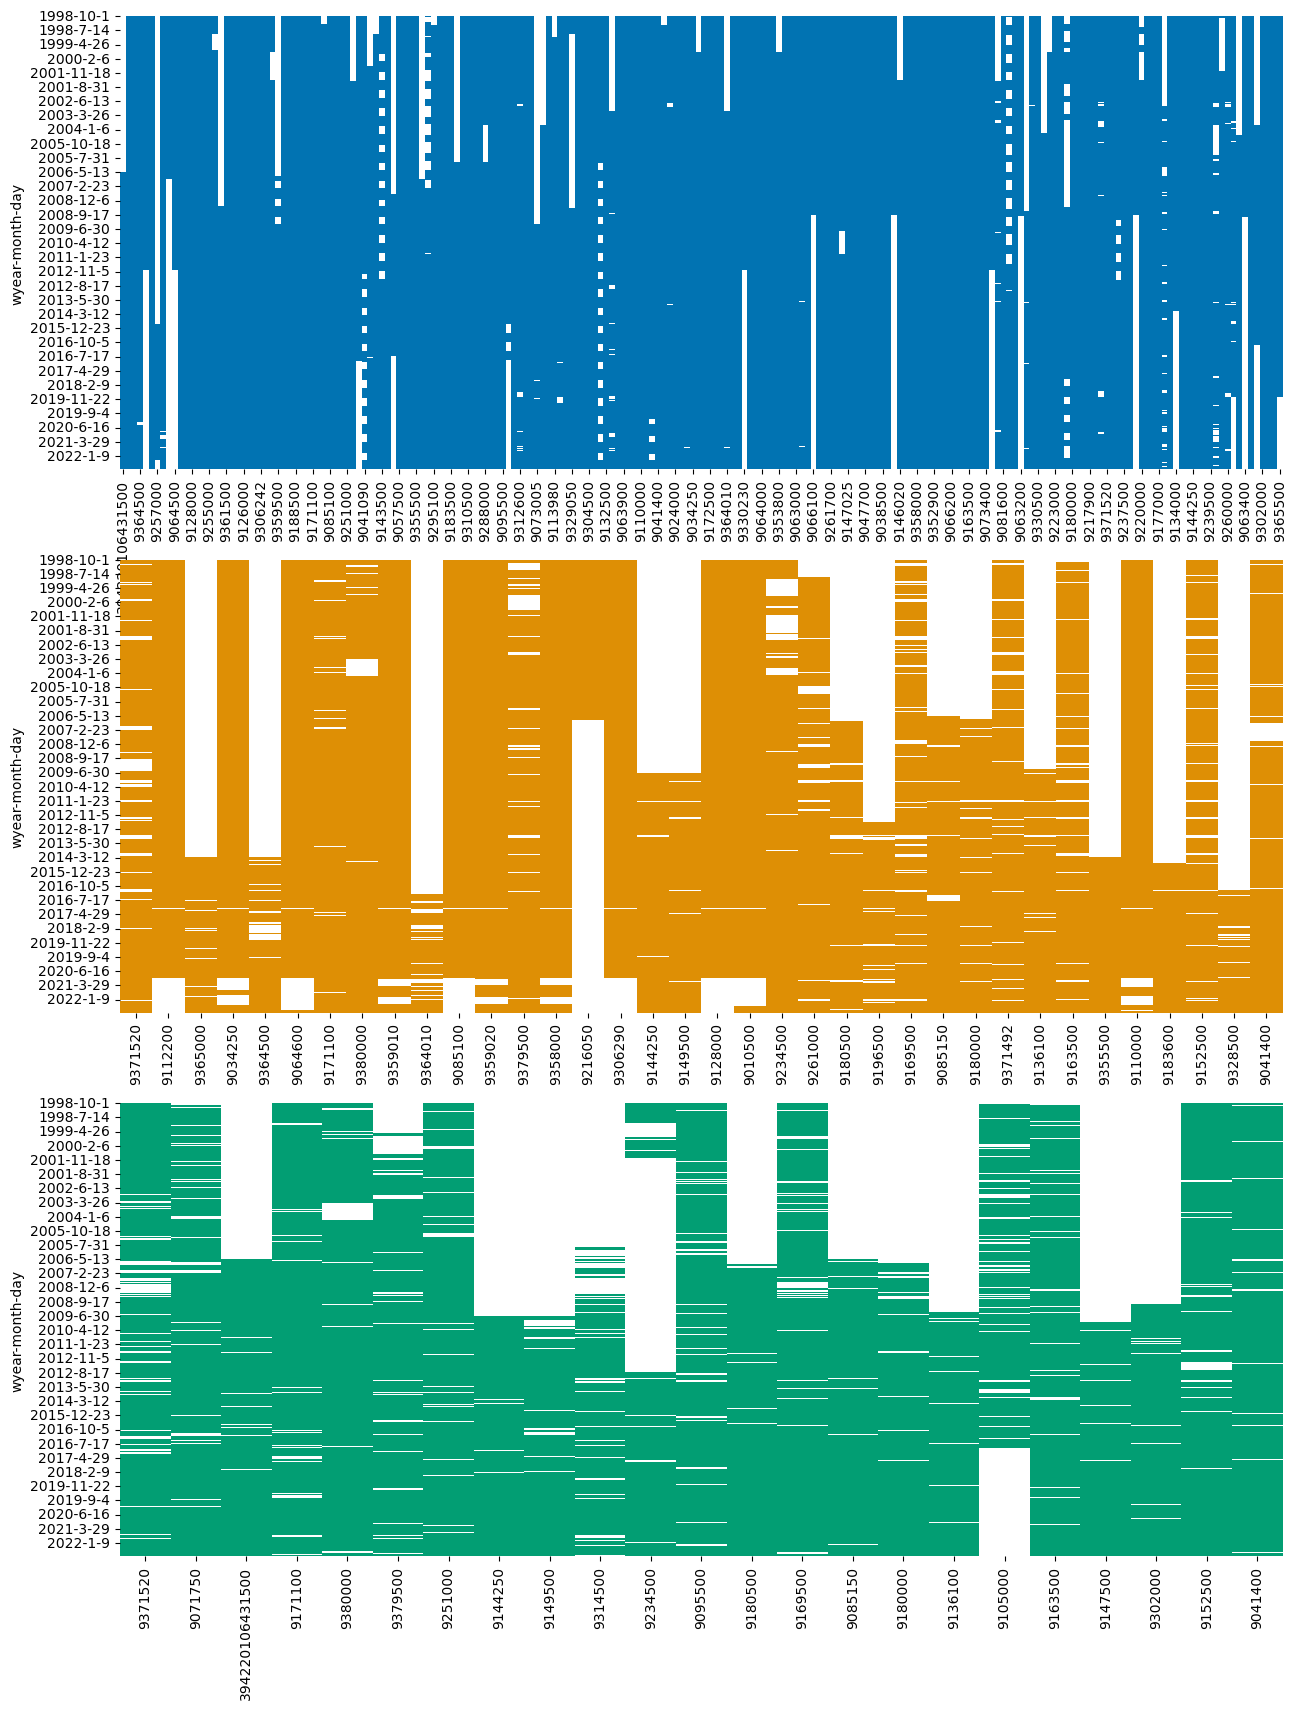

In [134]:
## DAILY data availability of the raw data for Q, WT, SC for 1998-2022
fig, ax = plt.subplots(3, 1, figsize=(15,20))#, sharey='all',sharex='all')
sns.heatmap(list_data_dfs[0][RDC_all3_allsites].loc[1998:2022].isnull(), cmap= mpl.colors.ListedColormap([episode_cmap[0],'white']),ax=ax[0],cbar=False)
sns.heatmap(list_data_dfs[1][WT_all3_allsites].loc[1998:2022].isnull(), cmap= mpl.colors.ListedColormap([episode_cmap[1],'white']),ax=ax[1],cbar=False)
sns.heatmap(list_data_dfs[2][SC_all3_allsites].loc[1998:2022].isnull(), cmap= mpl.colors.ListedColormap([episode_cmap[2],'white']),ax=ax[2],cbar=False)


<AxesSubplot:ylabel='wyear-month-day'>

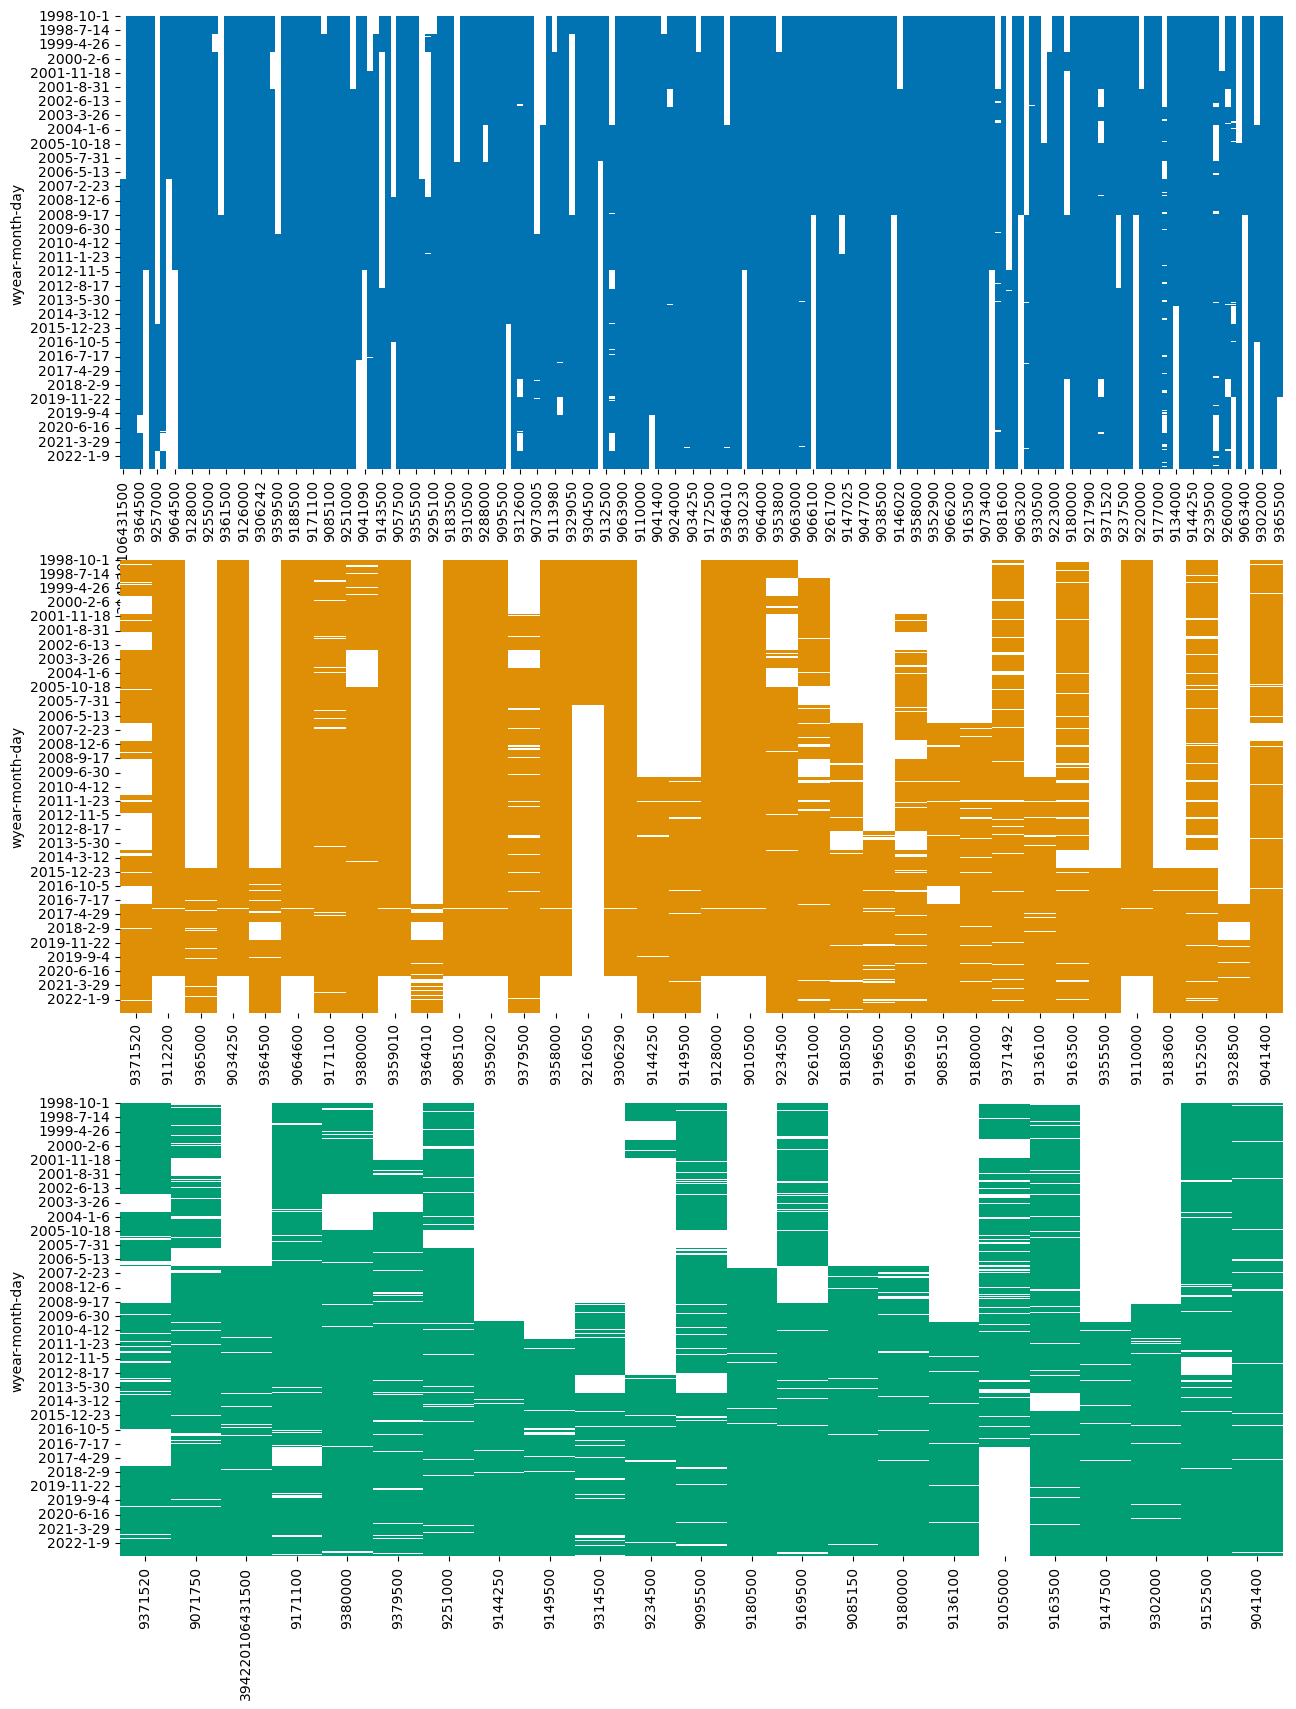

In [135]:
#### DAILY data availability after cleaning
fig, ax = plt.subplots(3, 1, figsize=(15,20))#, sharey='all',sharex='all')
sns.heatmap(RDC_ready[RDC_all3_allsites].loc[1998:2022].isnull(), cmap= mpl.colors.ListedColormap([episode_cmap[0],'white']),ax=ax[0],cbar=False)
sns.heatmap(WT_ready[WT_all3_allsites].loc[1998:2022].isnull(), cmap= mpl.colors.ListedColormap([episode_cmap[1],'white']),ax=ax[1],cbar=False)
sns.heatmap(SC_ready[SC_all3_allsites].loc[1998:2022].isnull(), cmap= mpl.colors.ListedColormap([episode_cmap[2],'white']),ax=ax[2],cbar=False)


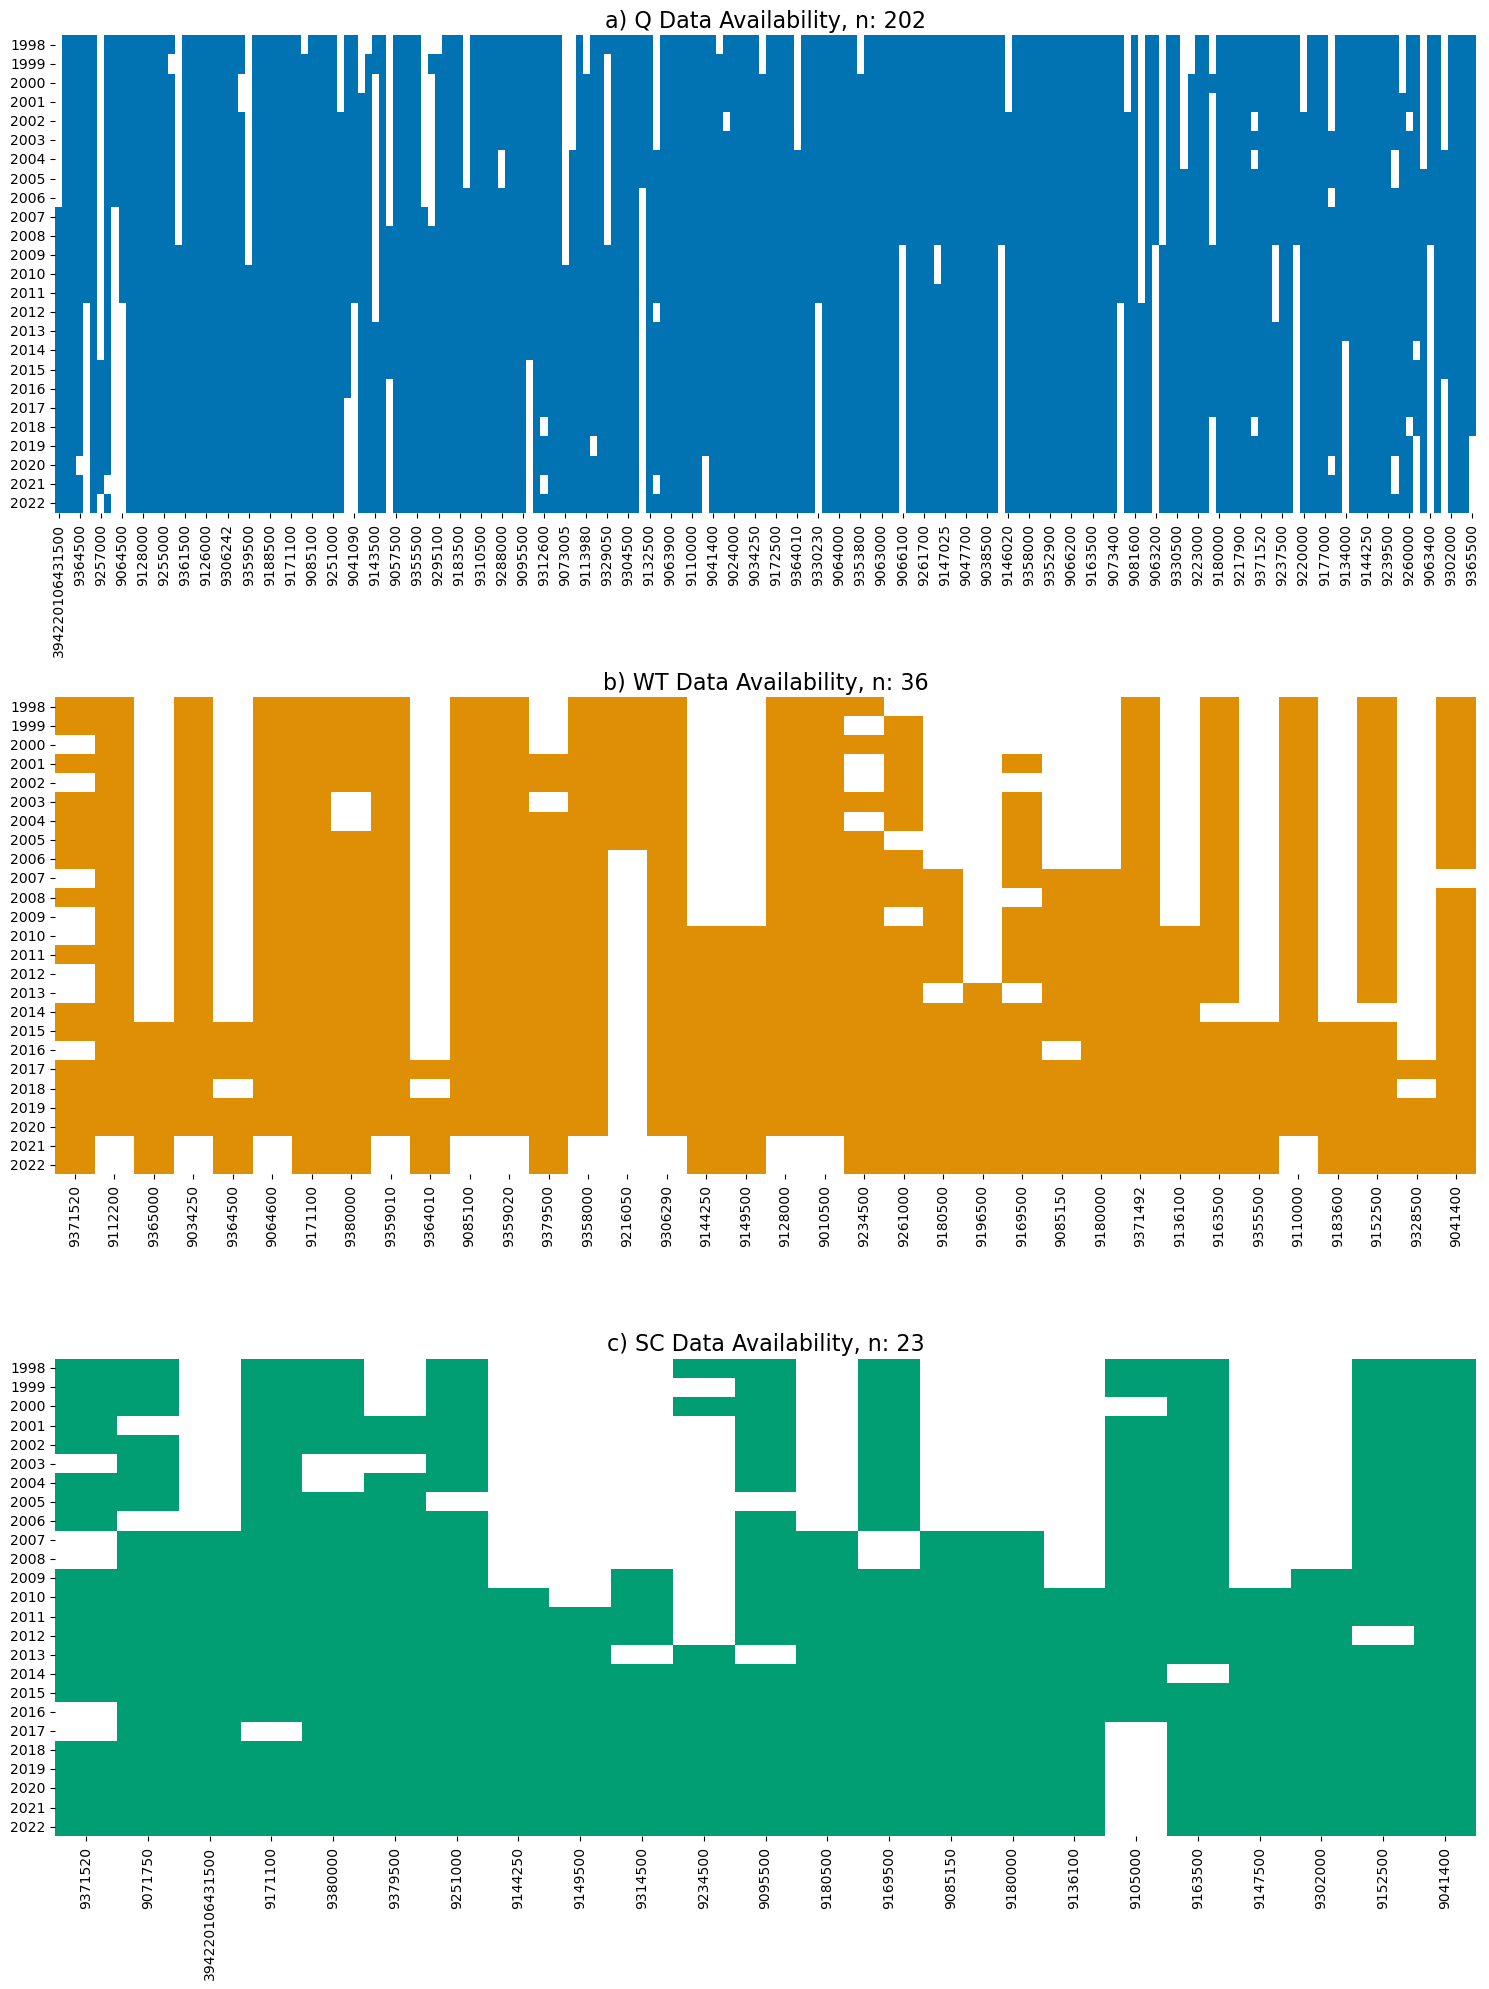

In [136]:
## Used in SUPPLEMENTARY INFORMATION
## ANNUAL data availability after all data criteria /cleaning

fig, ax = plt.subplots(3, 1, figsize=(15,20))#, sharey='all',sharex='all')
sns.heatmap(RDC_avail_df[RDC_all3_allsites].loc[1998:2022], cmap= mpl.colors.ListedColormap(['white',episode_cmap[0]]),ax=ax[0],cbar=False)
ax[0].set_title(f'a) Q Data Availability, n: {len(RDC_all3_allsites)}',fontsize=16)
ax[0].set_ylabel('')

sns.heatmap(WT_avail_df[WT_all3_allsites].loc[1998:2022], cmap= mpl.colors.ListedColormap(['white',episode_cmap[1]]),ax=ax[1],cbar=False)
ax[1].set_title(f'b) WT Data Availability, n: {len(WT_all3_allsites)}',fontsize=16)
ax[1].set_ylabel('')

sns.heatmap(SC_avail_df[SC_all3_allsites].loc[1998:2022], cmap= mpl.colors.ListedColormap(['white',episode_cmap[2]]),ax=ax[2],cbar=False)
ax[2].set_title(f'c) SC Data Availability, n: {len(SC_all3_allsites)}',fontsize=16)
ax[2].set_ylabel('')

fig.tight_layout()
plt.savefig(fig_dir +'dataavailability.svg',format="svg", transparent=True,dpi=300)
plt.savefig(fig_dir +'dataavailability.jpeg', dpi=300)
plt.show()

#### Distribution of Monthly Values and Relative Change

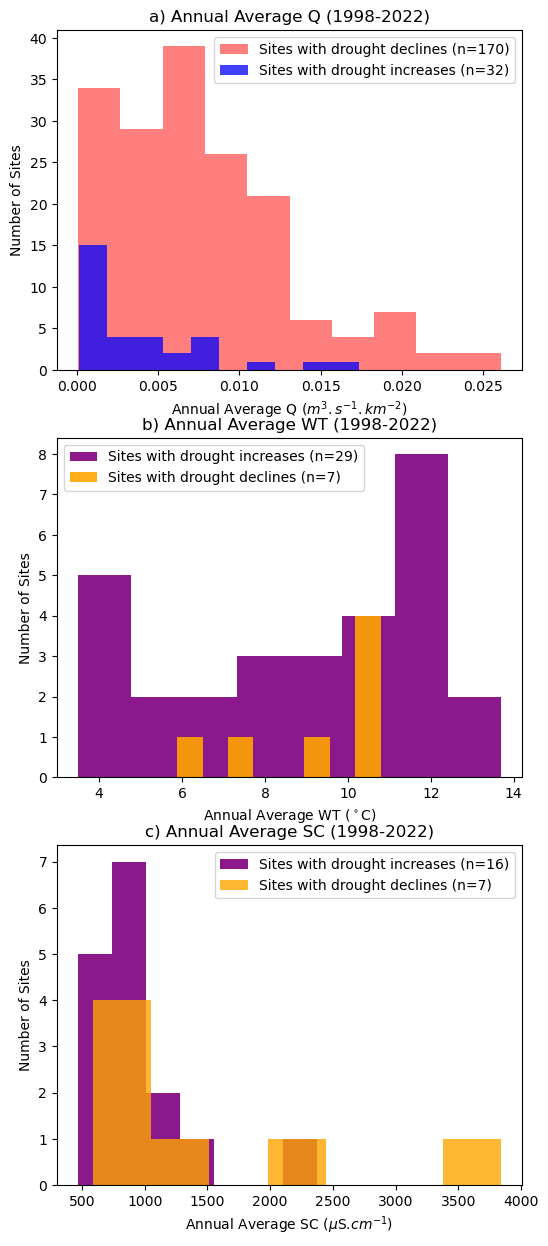

In [137]:
# used in SUPPLEMENTARY INFORMATION
fig, ax = plt.subplots(3, 1, figsize=(6,15))#, sharey='all',sharex='all')

ax[0].hist(RDC_years[sites_negRDC].mean(), bins=10, alpha=0.5, label='Sites with drought declines (n=170)', color='red')
ax[0].hist(RDC_years[sites_posRDC].mean(), bins=10, alpha=0.75, label='Sites with drought increases (n=32)', color='blue')
ax[0].set_xlabel(r'Annual Average Q ($m^{3}.s^{-1}.km^{-2}$)')
ax[0].set_ylabel('Number of Sites')
ax[0].set_title('a) Annual Average Q (1998-2022)')
ax[0].legend()

ax[1].hist(WT_years[sites_posWT].mean(), bins=8, alpha=0.9, label='Sites with drought increases (n=29)', color='purple')
ax[1].hist(WT_years[sites_negWT].mean(), bins=8, alpha=0.9, label='Sites with drought declines (n=7)', color='orange')
ax[1].set_xlabel(r'Annual Average WT ($^\circ$C)')
ax[1].set_ylabel('Number of Sites')
ax[1].set_title('b) Annual Average WT (1998-2022)')
ax[1].legend()

ax[2].hist(SC_years[sites_posSC].mean(), bins=7, alpha=0.9, label='Sites with drought increases (n=16)', color='purple')
ax[2].hist(SC_years[sites_negSC].mean(), bins=7, alpha=0.8, label='Sites with drought declines (n=7)', color='orange')
ax[2].set_xlabel(r'Annual Average SC ($\mu$S.$cm^{-1}$)') 
ax[2].set_ylabel('Number of Sites')
ax[2].set_title('c) Annual Average SC (1998-2022)')
ax[2].legend()

plt.savefig(fig_dir +'All3var_pos_neg_differences_dist.jpeg',dpi=300)
plt.savefig(fig_dir +'All3var_pos_neg_differences_dist.svg',format="svg", transparent=True,dpi=300)
plt.show()

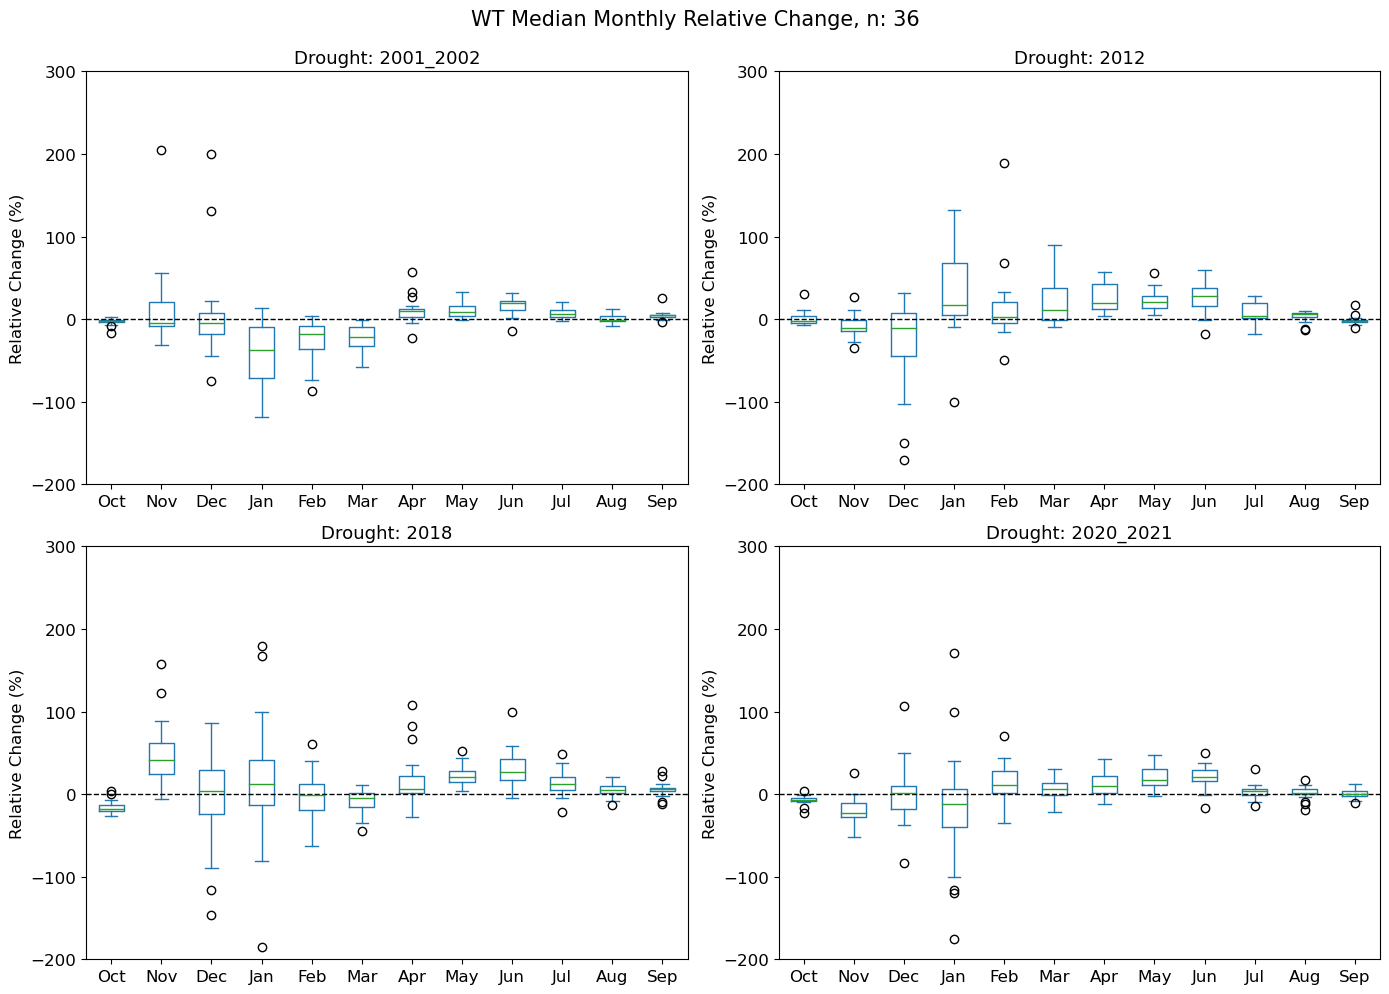

In [172]:
###### HAVE TO RUN 3 TIMES FOR ALL 3 VARIABLES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
var = var_names[1] # <- change and run again to save plots for the other variables
#years = ['2001_2002', '2012','2018', '2020_2021']
bottom=-200
top=300

for ax, yr in zip(axes, dr_names):
    # pandas boxplot: boxes = per‐column (i.e. per‐site) distribution over the 12 months
    vars()[var+'_mon_MEDrelchange_'+yr].transpose().plot(kind='box', ax=ax)
    
    ax.set_title(f'Drought: {yr}',fontsize=13)
    #ax.set_title(f'Q Median Monthly Relative Change, Drought {yr}')
    ax.set_xlabel('')
    ax.set_ylabel('Relative Change (%)',fontsize=12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylim(bottom, top)
    ax.set_xticks(range(1, len(wmon_names) + 1))
    ax.set_xticklabels(wmon_names)
    ax.tick_params(axis='both', labelsize=12)

if var == var_names[0]:
    fig.suptitle(f'Q Median Monthly Relative Change, n: {len(RDC_all3_allsites)}', fontsize=15, y=0.99)
if var == var_names[1]:
    fig.suptitle(f'WT Median Monthly Relative Change, n: {len(WT_all3_allsites)}', fontsize=15, y=0.99)
if var == var_names[2]:
    fig.suptitle(f'SC Median Monthly Relative Change, n: {len(SC_all3_allsites)}', fontsize=15, y=0.99)
fig.tight_layout()
plt.savefig(fig_dir +var+'_ALL_dr_ep_relchange_dist.jpeg',dpi=300)
plt.savefig(fig_dir +var+'_ALL_dr_ep_relchange_dist.svg',format="svg", transparent=True,dpi=300)
plt.show()

In [144]:
## How many sites are cut off by setting y-axis viewing limits:
for var in var_names:
    for yr in dr_names:
        mask = vars()[var+'_mon_MEDrelchange_'+yr] > 300
        sites_over = mask.apply(lambda row: row.index[row].tolist(), axis=1)
        for mon in vars()[var+'_mon_MEDrelchange_2012'].index:
            if len(sites_over[mon]) !=0:
                print(var, 'Month '+str(mon), yr, 'Sites over 300%:', len(sites_over[mon]))

        mask = vars()[var+'_mon_MEDrelchange_'+yr] < -200
        sites_under = mask.apply(lambda row: row.index[row].tolist(), axis=1)
        for mon in vars()[var+'_mon_MEDrelchange_2012'].index:
            if len(sites_under[mon]) !=0:
                print(var, 'Month '+str(mon), yr, 'Sites under -200%:', len(sites_under[mon]))


RDC Month 10 2012 Sites over 300%: 8
RDC Month 11 2012 Sites over 300%: 8
RDC Month 12 2012 Sites over 300%: 8
RDC Month 1 2012 Sites over 300%: 5
RDC Month 2 2012 Sites over 300%: 2
RDC Month 3 2012 Sites over 300%: 2
RDC Month 4 2012 Sites over 300%: 2
RDC Month 5 2012 Sites over 300%: 1
RDC Month 7 2012 Sites over 300%: 2
RDC Month 8 2012 Sites over 300%: 1
RDC Month 9 2012 Sites over 300%: 1
RDC Month 4 2018 Sites over 300%: 1
RDC Month 5 2018 Sites over 300%: 1
RDC Month 10 2020_2021 Sites over 300%: 1
RDC Month 11 2020_2021 Sites over 300%: 1
RDC Month 12 2020_2021 Sites over 300%: 1
RDC Month 1 2020_2021 Sites over 300%: 1
RDC Month 2 2020_2021 Sites over 300%: 1
RDC Month 3 2020_2021 Sites over 300%: 2
RDC Month 4 2020_2021 Sites over 300%: 1
RDC Month 8 2020_2021 Sites over 300%: 1
RDC Month 9 2020_2021 Sites over 300%: 1
WT Month 1 2012 Sites over 300%: 1
WT Month 12 2018 Sites over 300%: 1
WT Month 12 2020_2021 Sites over 300%: 2
WT Month 1 2020_2021 Sites under -200%: 1
SC 

#### SPEI

In [145]:
# we are using the list of Q sites so that it is relevant to our later work
# have to pair the list of Q sites with the list of sites in gages
print('Number of Q sites that have gages information: ',len(list(set(RDC_all3_allsites) & set(gagesii_int.index))))

Number of Q sites that have gages information:  202


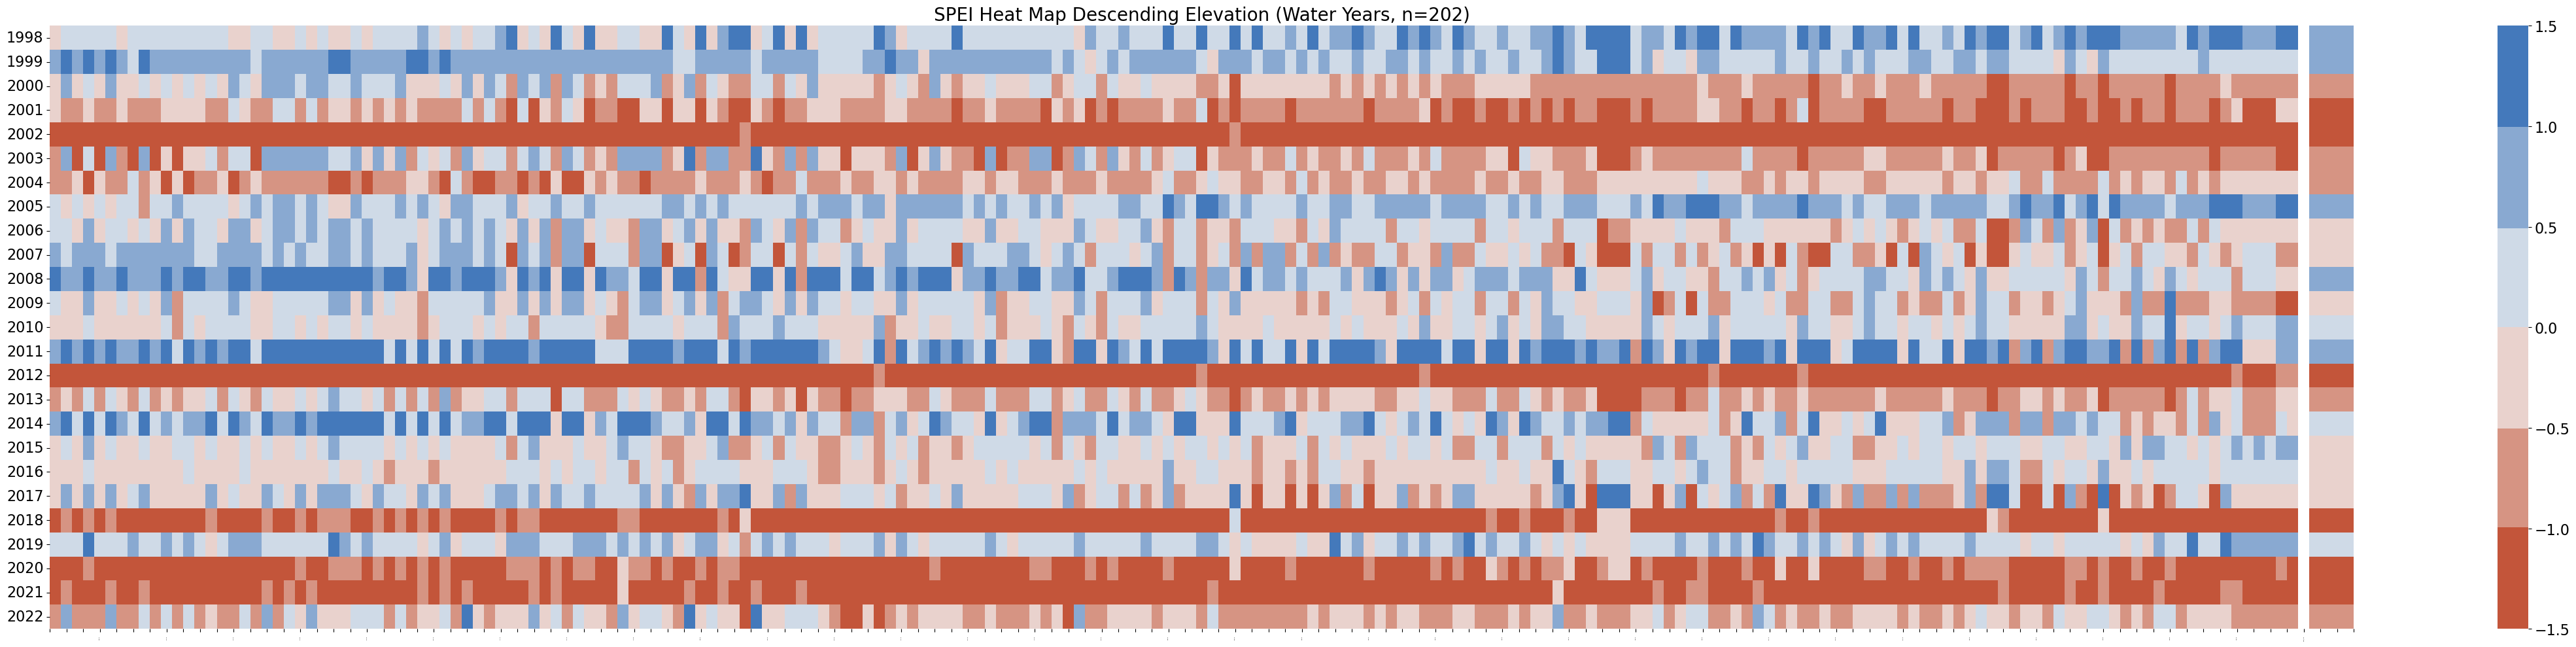

SPEI and elevation dataframe saved: /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/spei_ann_wyElevation.csv


In [146]:
#preprocessing.plotting_spei(ann_spei, gagesii_int, RDC_all3_allsites, figure_dir=None,OPTION=False)
TRUN_ann_spei_wyears.columns = TRUN_ann_spei_wyears.columns.map(str)
calculations.plotting_spei(TRUN_ann_spei_wyears, gagesii_int, list(set(RDC_all3_allsites) & set(gagesii_int.index)),spei_cmap,fig_dir,True)

#### Compare Drought and Reference Values by Site

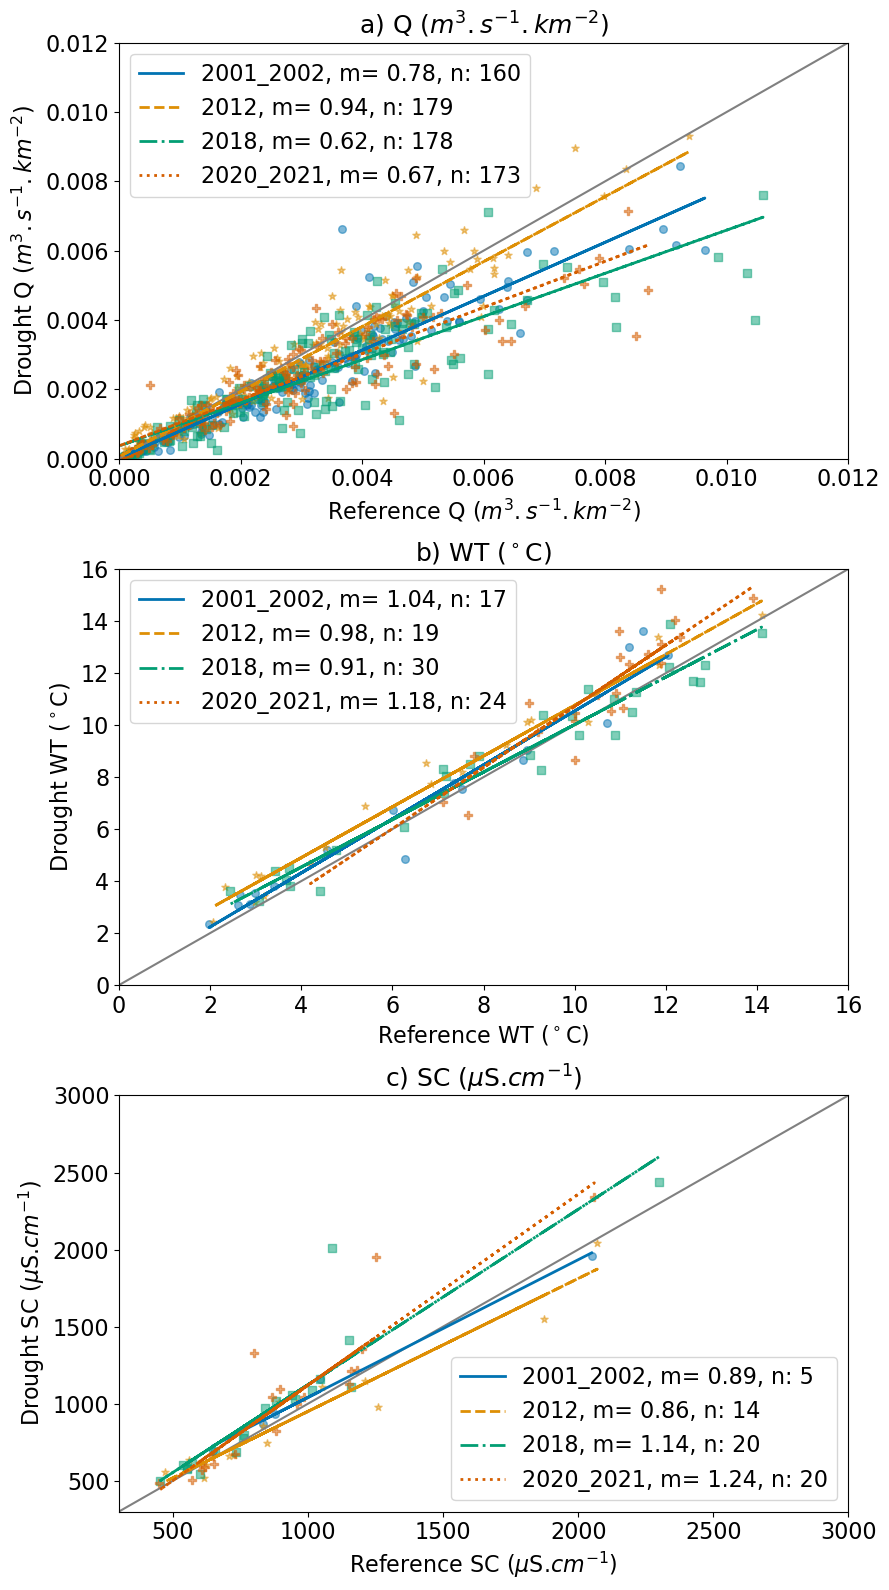

In [147]:
## SCATTERPLOT: ANN, Episode 
fig,axs = plt.subplots(nrows=3, ncols=1,figsize=(9,16))
for i,ax in enumerate(axs):
    var2_plot = var_names[i]
    ind_names = dr_names
    fsize=18
    fontsize2=fsize-2

    if var2_plot == var_names[0]:
        var_plot_name = r'Q ($m^{3}.s^{-1}.km^{-2}$)'
        ax.axline(xy1=(0,0), xy2=None, slope=1,color='gray', linestyle='-')
        ax.set_ylim(bottom=0,top=0.012)
        ax.set_xlim(left=0,right=0.012)
    if var2_plot == var_names[1]:
        var_plot_name = r'WT ($^\circ$C)'
        ax.axline(xy1=(4,4), xy2=None, slope=1,color='gray', linestyle='-')
        ax.set_ylim(bottom=0,top=16)
        ax.set_xlim(left=0,right=16)
    if var2_plot == var_names[2]:
        var_plot_name = r'SC ($\mu$S.$cm^{-1}$)'
        ax.axline(xy1=(400,400), xy2=None, slope=1,color='gray', linestyle='-')
        ax.set_ylim(bottom=300,top=3000)
        ax.set_xlim(left=300,right=3000)

    ax.set_ylabel('Drought '+var_plot_name,fontsize=fontsize2)
    ax.set_xlabel('Reference '+var_plot_name,fontsize=fontsize2)
    ax.tick_params(axis='y')
    
    num=0
    for dr in ind_names:
        var_drought = vars()[str(var2_plot)+'_ann_MEDdrought_'+dr]
        var_reference = vars()[str(var2_plot)+'_ann_MEDref_'+dr]
        #vars()[var+'_ann_MEDdrought_'+dr], vars()[var+'_ann_MEDref_'+dr]
        #res =  [abs(ele) for ele in y]                                 # THE REL CHANGE IS ABSOLUTE VALUE
        ax.scatter(x=var_reference, y=var_drought,color=episode_cmap[num],s=30,alpha=0.5, marker=episode_markers[num],)
    
        #calculate equation for trendline
        a,b = np.polyfit(x=var_reference, y=var_drought,deg=1)
        z = np.polyfit(x=var_reference, y=var_drought,deg=1)
        p = np.poly1d(z)
        #add trendline to plot
        ax.plot(var_reference, p(var_reference),color=episode_cmap[num],linestyle=episode_linestyles[num],
                linewidth=2,label=dr+', m= {:.2f}'.format(a)+', n: '+str(len(var_drought)))

        num+=1

    for label in (ax.get_yticklabels()):
        label.set_fontsize(fontsize2)
    
    for label in (ax.get_xticklabels()):
        label.set_fontsize(fontsize2)


    # Add some text for labels, title and custom x-axis tick labels, etc.
    if var2_plot == var_names[0]:
        ax.set_title('a) ' + var_plot_name, fontsize=fsize)
    if var2_plot == var_names[1]:
        ax.set_title('b) ' +var_plot_name, fontsize=fsize)
    if var2_plot == var_names[2]:
        ax.set_title('c) '+ var_plot_name, fontsize=fsize)
    #ax.legend(handles=[rects3, rects4,plot],prop={"size":16})
    ax.legend(loc='best',prop={"size":fontsize2})

fig.tight_layout()
plt.savefig(fig_dir +'ALL3_dr_ep_scatter_GAP.jpeg',dpi=300)
plt.savefig(fig_dir +'ALL3_dr_ep_scatter_GAP.svg',format="svg", transparent=True,dpi=300)

plt.show()

#### Monthly Relative Change, avg of all sites

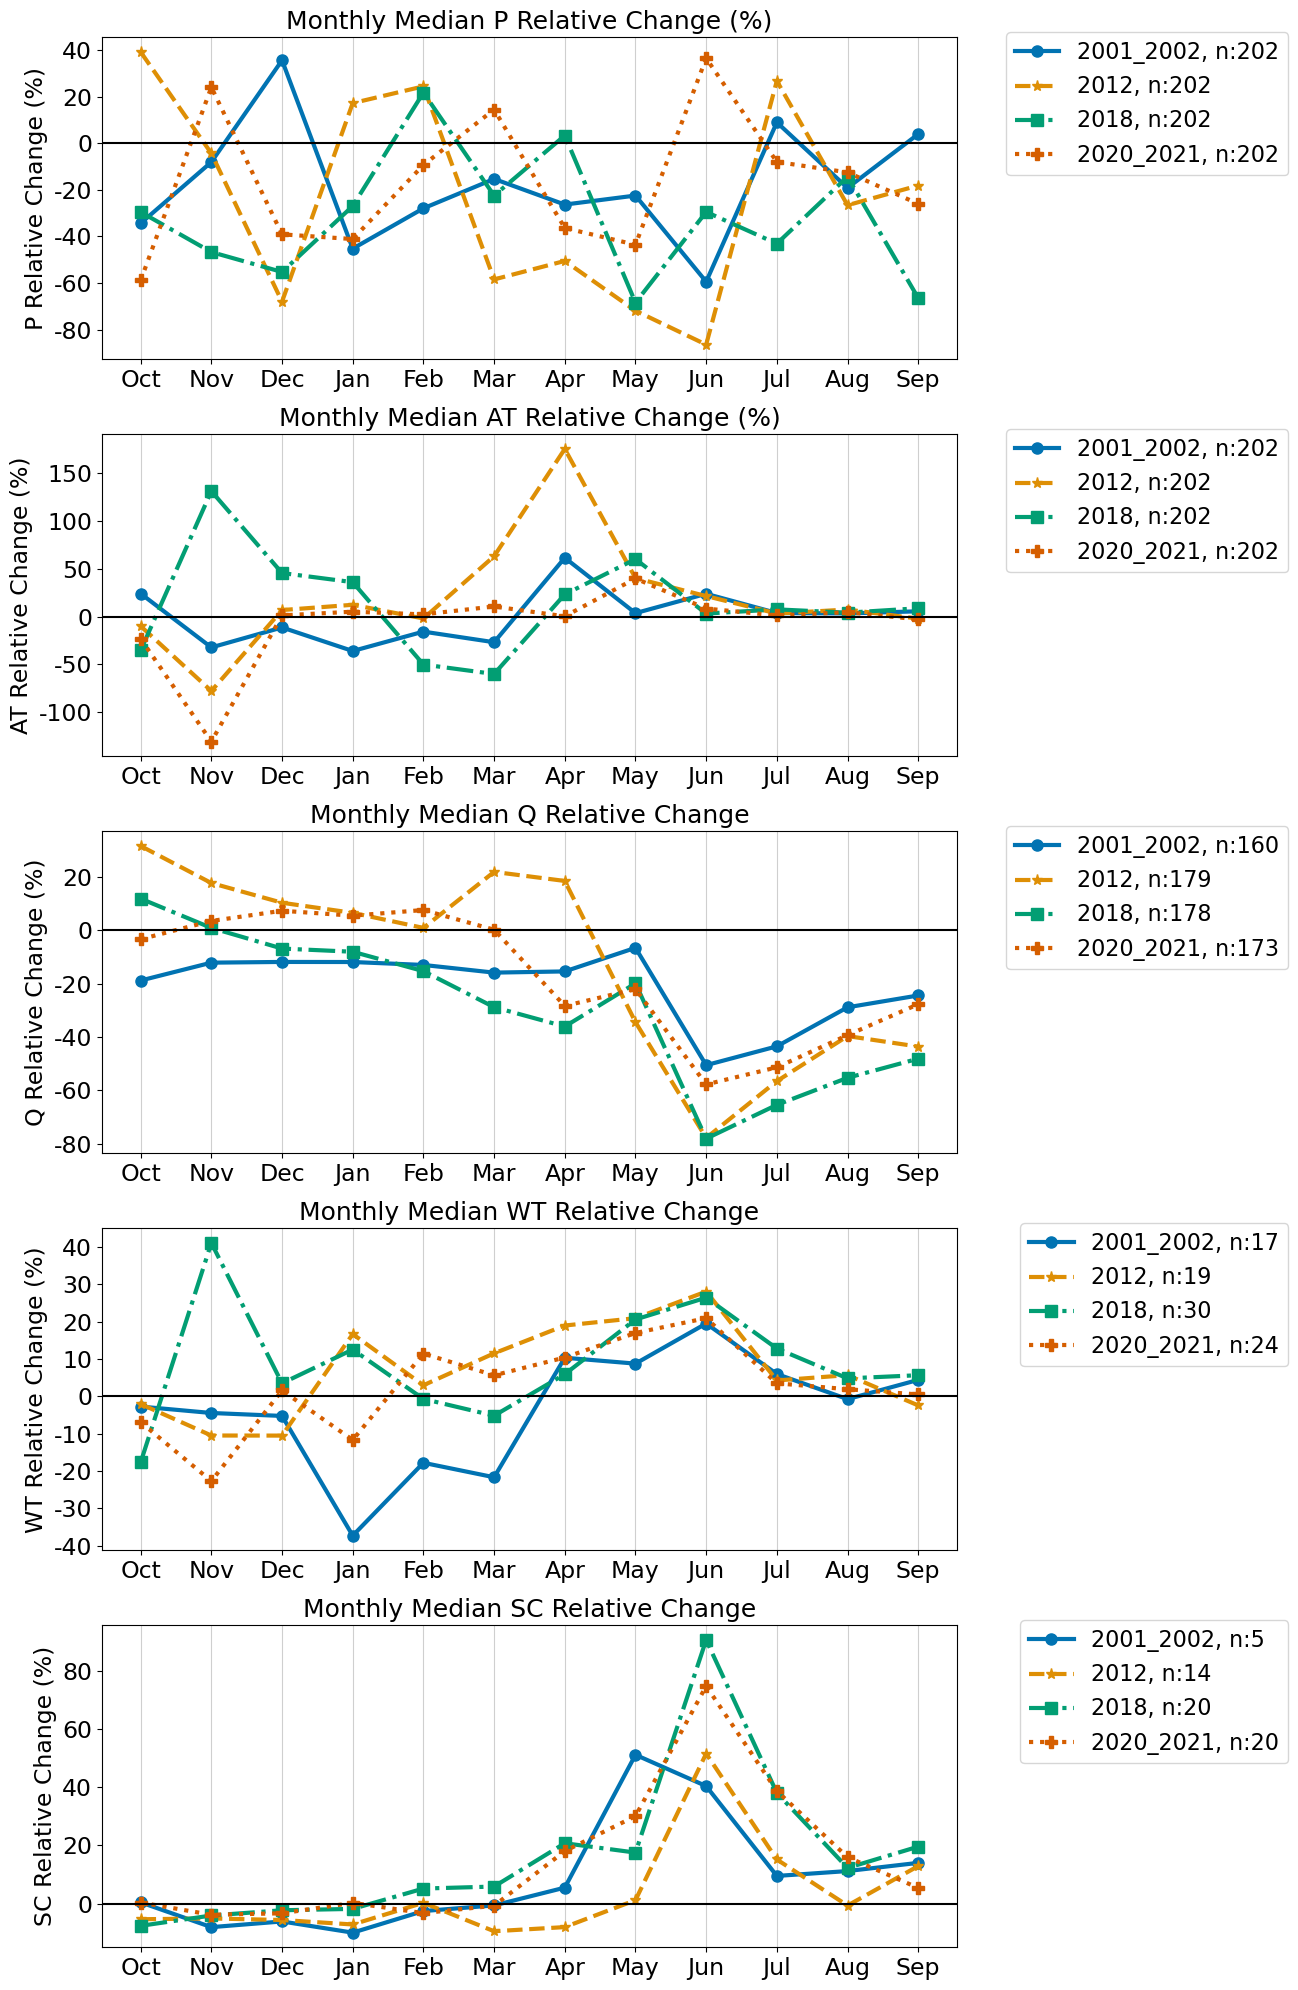

In [148]:
## PLOT: Monthly Rel.Change, VARS+MET, Episodes
with_precip_temp = True
same_yaxis = False
if with_precip_temp:
    figsize=(14,20)
    fig,axs = plt.subplots(nrows=5, ncols=1,figsize=figsize)#,sharex=True)
else:
    figsize=(14,10)
    fig,axs = plt.subplots(nrows=5, ncols=1,figsize=figsize)#,sharex=True)
    
fontsize=16
for i,ax in enumerate(axs):
    if i == 2 or i == 3 or i == 4:    
        var2_plot = var_names[i-2]
        if var2_plot == var_names[0]:
            var_plot_name = 'Q'
        if var2_plot == var_names[1]:
            var_plot_name = 'WT'
        if var2_plot == var_names[2]:
            var_plot_name = 'SC'

        ax.set_ylabel(var_plot_name+' Relative Change (%)', fontsize=fontsize+1)
        ax.set_title('Monthly Median '+var_plot_name+' Relative Change', fontsize=fontsize+2)

        handles = []
        for dr in dr_names:

            vars()['line1_'+dr], = ax.plot(wmon_names,vars()[var2_plot+'_mon_MEDrelchange_'+dr].median(axis=1),color=dr_colors[dr],
                                           label=dr+', n:'+str(len(vars()[var2_plot+'_mon_MEDrelchange_'+dr].columns)), 
                                           markersize=8, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=3)
            handles.append(vars()['line1_'+dr])
    
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(fontsize+1)

        ax.axhline(y=0.0, color='black', linestyle='-')
        ax.grid(axis='x',alpha=0.6)
        #ax.legend(handles=handles,loc='best', prop={"size":fontsize})
        ax.legend(bbox_to_anchor=(1.4, 1.05),handles=handles,loc='upper right', prop={"size":fontsize})
        if same_yaxis:
            ax.set_ylim(bottom=-150,top=175)
       
    if i == 0 or i ==1:
        met2plot = MET_vars[i]
        if met2plot == MET_vars[0]:
            met_plot_name = 'P'
        if met2plot == MET_vars[1]:
            met_plot_name = 'AT'
        ax.set_ylabel(f'{met_plot_name} Relative Change (%)', fontsize=fontsize+1)
        ax.set_title(f'Monthly Median {met_plot_name} Relative Change (%)', fontsize=fontsize+2)

        handles = []
        for dr in dr_names: 
            vars()['line1_'+dr], = ax.plot(wmon_names,vars()[met2plot+'_mon_MEDrelchange_'+dr].median(axis=1),color=dr_colors[dr],
                                           label=dr+', n:'+str(len(vars()[met2plot+'_mon_MEDrelchange_'+dr].columns)), 
                                           markersize=8, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=3)
            handles.append(vars()['line1_'+str(dr)])

        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(fontsize+1)

        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        ax.axhline(y=0.0, color='black', linestyle='-')
        #ax.legend(handles=handles,loc='best', prop={"size":fontsize})
        ax.legend(bbox_to_anchor=(1.4, 1.05),handles=handles,loc='upper right', prop={"size":fontsize})
        ax.grid(axis='x',alpha=0.6)
        if same_yaxis:
            ax.set_ylim(bottom=-150,top=175)

fig.tight_layout()

if with_precip_temp:
    plt.savefig(fig_dir+'ALL3seasonal_relchangeWY.jpeg',dpi=300)
    plt.savefig(fig_dir +'ALL3seasonal_relchangeWY.svg',format="svg", transparent=True,dpi=300)
else:
    plt.savefig(fig_dir+'seasonal_relchangeWY_noPT.jpeg',dpi=300)
    plt.savefig(fig_dir +'seasonal_relchangeWY_noPT.svg',format="svg", transparent=True,dpi=300)

plt.show()

#### Monthly values, avg all sites

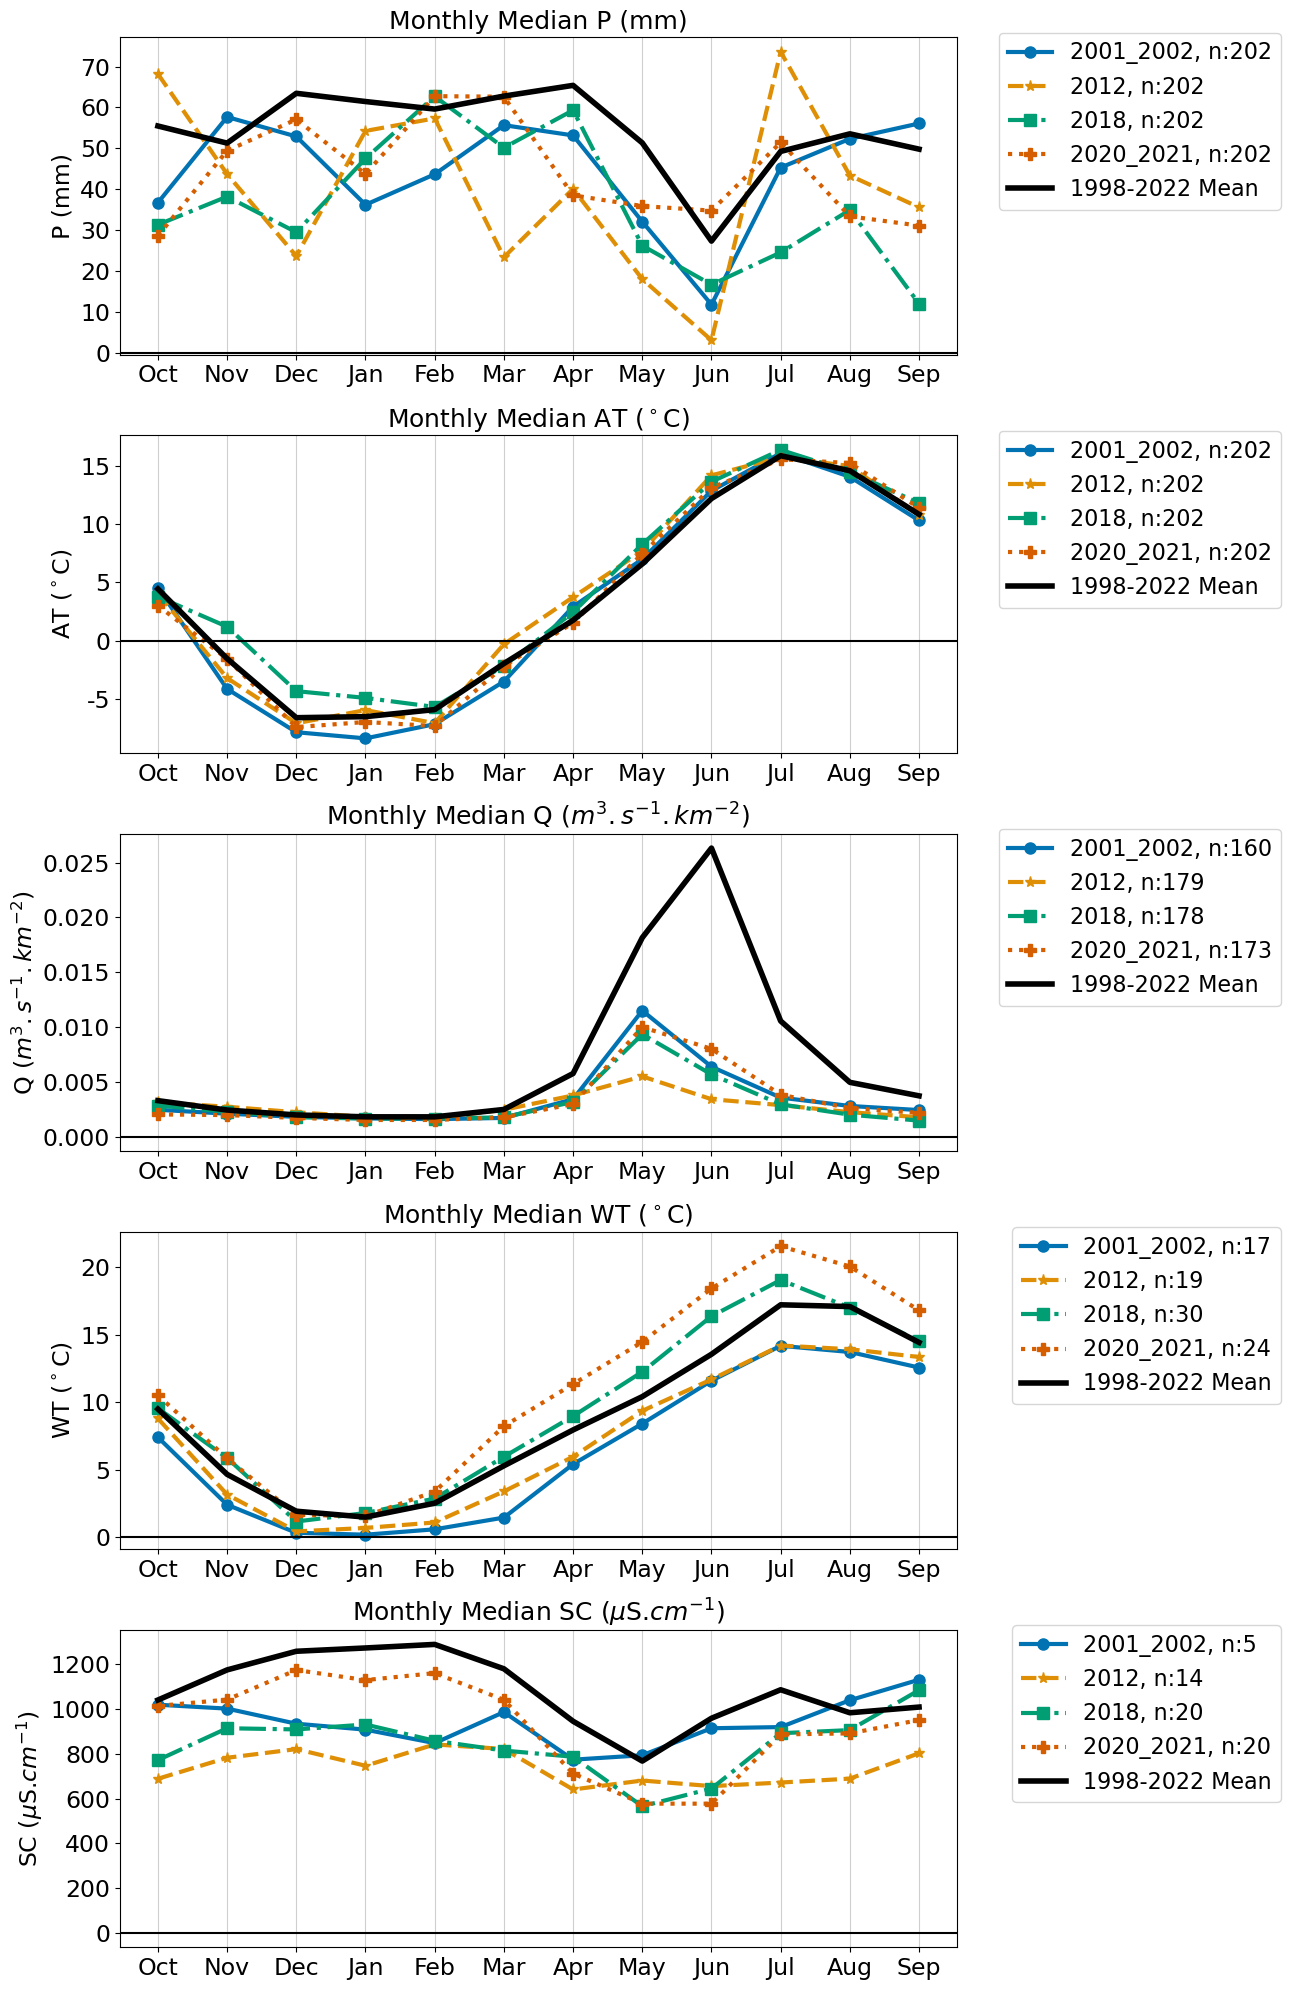

In [149]:
## PLOT: Monthly Actual values, VARS+MET, Episodes
with_precip_temp = True
if with_precip_temp:
    figsize=(14,20)
    fig,axs = plt.subplots(nrows=5, ncols=1,figsize=figsize)#,sharex=True)
else:
    figsize=(14,10)
    fig,axs = plt.subplots(nrows=5, ncols=1,figsize=figsize)#,sharex=True)
    
fontsize=16
for i,ax in enumerate(axs):
    if i == 2 or i == 3 or i == 4:    
        var2_plot = var_names[i-2]
        if var2_plot == var_names[0]:
            var_plot_name = r'Q ($m^{3}.s^{-1}.km^{-2}$)'
        if var2_plot == var_names[1]:
            var_plot_name = r'WT ($^\circ$C)'
        if var2_plot == var_names[2]:
            var_plot_name = r'SC ($\mu$S.$cm^{-1}$)'

        ax.set_ylabel(var_plot_name, fontsize=fontsize+1)
        ax.set_title('Monthly Median '+var_plot_name, fontsize=fontsize+2)

        handles = []
        for dr in ['2001_2002', '2012','2018', '2020_2021']: 
            # vars()[var+'_mon_MEDdrought_'+dr]    
            vars()['line1_'+dr], = ax.plot(wmon_names,vars()[var2_plot+'_mon_MEDdrought_'+dr].median(axis=1),color=dr_colors[dr],
                                           label=dr+', n:'+str(len(vars()[var2_plot+'_mon_MEDdrought_'+dr].columns)), 
                                           markersize=8, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=3)
            handles.append(vars()['line1_'+dr])

        mean_handle, = ax.plot(wmon_names,vars()[var2_plot+'_basin_avg_'+str(longterm_avg_start)+'_2022_all3'],label=str(longterm_avg_start)+'-2022 Mean',color='black',linewidth=4)
        handles.append(mean_handle)
        # ref_handle, = ax.plot(wmon_names,vars()[var2_plot+ '_all_ref_MEAN'],label='Reference year Mean',color='red',linewidth=4)
        # handles.append(ref_handle)
    
        #ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(fontsize+1)

        ax.axhline(y=0.0, color='black', linestyle='-')
        ax.grid(axis='x',alpha=0.6)
        #ax.legend(handles=handles,loc='best', prop={"size":fontsize})
        ax.legend(bbox_to_anchor=(1.4, 1.05),handles=handles,loc='upper right', prop={"size":fontsize})
        
    if i == 0 or i ==1:
        met2plot = MET_vars[i]
        if met2plot == MET_vars[0]:
            met_plot_name = 'P (mm)'
        if met2plot == MET_vars[1]:
            met_plot_name = r'AT ($^\circ$C)'
        ax.set_ylabel(met_plot_name, fontsize=fontsize+1)
        ax.set_title('Monthly Median '+met_plot_name, fontsize=fontsize+2)

        handles = []
        for dr in dr_names:
            vars()['line1_'+dr], = ax.plot(wmon_names,vars()[met2plot+'_mon_MEDdrought_'+str(dr)].median(axis=1),color=dr_colors[dr],
                                           label=dr+', n:'+str(len(vars()[met2plot+'_mon_MEDrelchange_'+dr].columns)), 
                                           markersize = 8, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=3)
            handles.append(vars()['line1_'+str(dr)])

        mean_handle, = ax.plot(wmon_names,vars()['basin_avg_'+met2plot+'_allyrs'],label=str(longterm_avg_start)+'-2022 Mean',color='black',linewidth=4)
        handles.append(mean_handle)
        # mean_handle2, = ax.plot(wmon_names,vars()[met2plot+'_basin_avg_'+str(longterm_avg_start)+'_2022_all3'],label='1972-2022 Mean',color='firebrick',linewidth=4)
        # handles.append(mean_handle2)

        # ref_handle, = ax.plot(wmon_names,precip_all_ref_MEAN,label='Reference year Mean',color='red',linewidth=4)
        # handles.append(ref_handle)

        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(fontsize+1)

        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        ax.axhline(y=0.0, color='black', linestyle='-')
        #ax.legend(handles=handles,loc='best', prop={"size":fontsize})
        ax.legend(bbox_to_anchor=(1.4, 1.05),handles=handles,loc='upper right', prop={"size":fontsize})
        ax.grid(axis='x',alpha=0.6)        

fig.tight_layout()

if with_precip_temp:
    plt.savefig(fig_dir+'ALL3seasonal_ABSOLUTEWY_PT.jpeg',dpi=300)
    plt.savefig(fig_dir +'ALL3seasonal_ABSOLUTEWY_PT.svg',format="svg", transparent=True,dpi=300)
else:
    plt.savefig(fig_dir+'seasonal_ABSOLUTEWY_noPT.jpeg',dpi=300)
    plt.savefig(fig_dir +'seasonal_ABSOLUTEWY_noPT.svg',format="svg", transparent=True,dpi=300)

plt.show()

#### Co-location plots

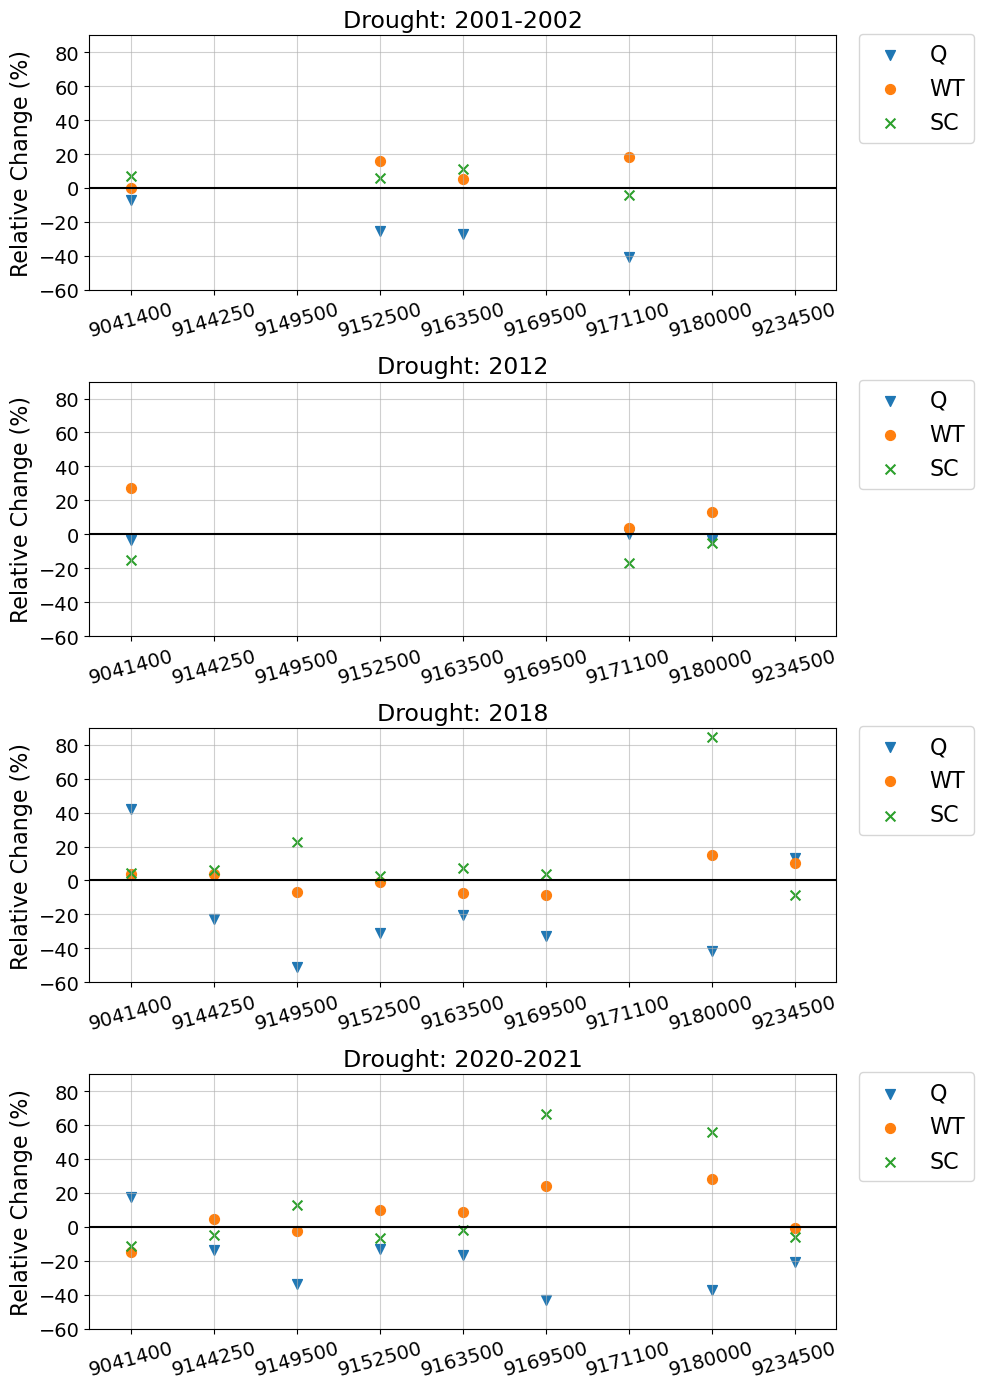

In [153]:
## PLOT: Monthly Actual values, VARS+MET, Episodes
figsize=(10,14)
fig,axs = plt.subplots(nrows=4, ncols=1,figsize=figsize)#,sharex=True)
var_markers = {var_names[0]:'v',var_names[1]:'o',var_names[2]:'x'}

all_sites = full_idx.values
x = np.arange(len(all_sites))

fontsize=16
for i,ax in enumerate(axs):    
    dr = dr_names[i]    
    ax.set_ylabel('Relative Change (%)', fontsize=fontsize)
    if dr == dr_names[0]:
        ax.set_title('Drought: 2001-2002', fontsize=fontsize+1)
    elif dr == dr_names[3]:
        ax.set_title('Drought: 2020-2021', fontsize=fontsize+1)
    else:
        ax.set_title(f'Drought: {dr}', fontsize=fontsize+1)
    handles = []
    #vmin, vmax = -100, 100
    for var in var_names:
        if var == var_names[0]:
            var_plot_name = 'Q'
        if var == var_names[1]:
            var_plot_name = 'WT'
        if var == var_names[2]:
            var_plot_name = 'SC'

        series = vars()[f'all3_ann_MEDrelchange_allsites_{dr}'][var].reindex(all_sites)
        ax.scatter(x, series.values, s=50, marker=var_markers[var], label=var_plot_name)

        #ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    
    ax.set_xlim(-0.5, len(all_sites) - 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in all_sites], rotation=45)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(fontsize-2)

    ax.axhline(y=0.0, color='black', linestyle='-')
    ax.grid(axis='both',alpha=0.6)
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(bottom=-60,top=90)
    ax.legend(bbox_to_anchor=(1.2, 1.05),loc='upper right', prop={"size":fontsize})

fig.tight_layout()
plt.savefig(fig_dir+'all3vars_annualrelchange_alldrs.jpeg',dpi=300)
plt.savefig(fig_dir +'all3vars_annualrelchange_alldrs.svg',format="svg", transparent=True,dpi=300)
plt.show()

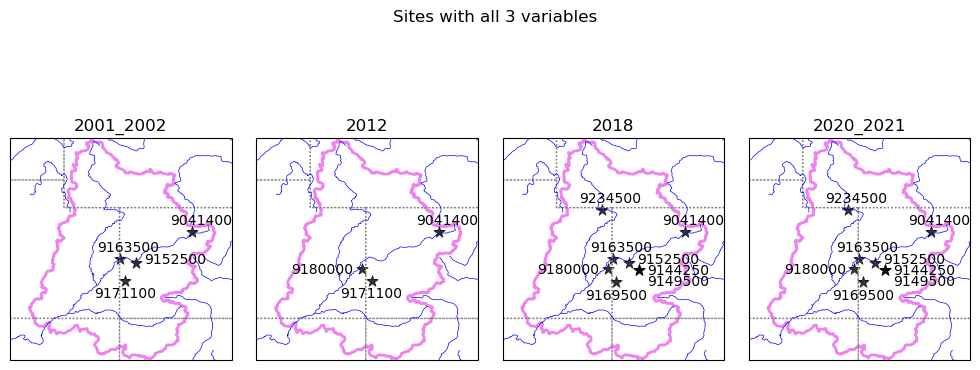

In [154]:
plot_vars = dr_names
var_2plot = var_names[0]
fig, axes = plt.subplots(
    nrows=1, ncols=4,figsize=(10, 5),
    subplot_kw={ 'projection': crs.PlateCarree()
        #crs.AlbersEqualArea( central_latitude=39.5, central_longitude=-98.35)
        })

fig.suptitle("Sites with all 3 variables",fontsize=12,y=0.95)

# common shapefile for the basin boundary
fname = upper_colorado_river_boundary_dir / 'Upper_Colorado_River_Basin_Boundary.shp'
shape_feature = ShapelyFeature(
    shpreader(str(fname)).geometries(),
    crs.PlateCarree(),edgecolor='violet',facecolor='white',lw=2)

for ax, var in zip(axes, plot_vars):
    # add coastlines, states, rivers
    ax.add_feature(cfeature.COASTLINE, linestyle=':', edgecolor='grey', linewidth=1)
    ax.add_feature(cfeature.STATES,    linestyle=':', edgecolor='grey', linewidth=1)
    ax.add_feature(cfeature.RIVERS,    edgecolor='blue', linewidth=0.5)
    ax.add_feature(shape_feature, zorder=-1)

    # zoom into the basin
    ax.set_extent([-113, -105, 35.5, 43.5], crs=crs.PlateCarree())

    # get the data
    data = vars()[var_2plot+'_MEDrelchange_map_all3'].loc[vars()['all3vars_'+var]]

    # choose vmin/vmax by variable
    vmin, vmax = -100, 100
    ax.scatter(x=data.LON, y=data.LAT, c='black',s= 75, alpha=0.8,
                    marker= '*', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    dref = data[(data['CLASS']=='Ref')]
    if len(dref) > 0:
        ax.scatter(x=dref.LON, y=dref.LAT, c='black', s= 100,alpha=0.8,
                   marker= '.',# edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    # title
    ax.set_title(var,fontsize=12)    

    for lon, lat, name in zip(data['LON'], data['LAT'], data.index):    
        if (name != 9144250)&(name != 9149500)&(name != 9152500)&(name != 9171100)&(name != 9169500)&(name != 9180000):
            ax.annotate( name, (lon, lat),
                textcoords="offset points",  
                xytext=(6, 6),  
                ha='center',
                fontsize=10,
                color='black' 
            )
        if name == 9144250:
            ax.annotate( name, (lon, lat),
                textcoords="offset points",  
                xytext=(6, -3),  
                ha='left',
                fontsize=10,
                color='black' 
            )
        if name == 9149500:
            ax.annotate( name, (lon, lat),
                textcoords="offset points",  
                xytext=(6, -11),  
                ha='left',
                fontsize=10,
                color='black' 
            )
        if name == 9152500:
            ax.annotate( name, (lon, lat),
                textcoords="offset points",  
                xytext=(6, 0),  
                ha='left',
                fontsize=10,
                color='black' 
            )
        if (name == 9171100)|(name == 9169500):
            ax.annotate( name, (lon, lat),
                textcoords="offset points",  
                xytext=(0, -12),  
                ha='center',
                fontsize=10,
                color='black' 
            )
        if name == 9180000:
            ax.annotate( name, (lon, lat),
                textcoords="offset points",  
                xytext=(-6, -3),  
                ha='right',
                fontsize=10,
                color='black' 
            )
            
plt.tight_layout()
plt.savefig(fig_dir+'all3vars_locations_alldrs.jpeg',format='jpeg',dpi=300)
plt.savefig(fig_dir +'all3vars_locations_alldrs.svg',format="svg", transparent=True,dpi=300)
plt.show()

In [155]:
### MONTHLY COLOCATED SITES

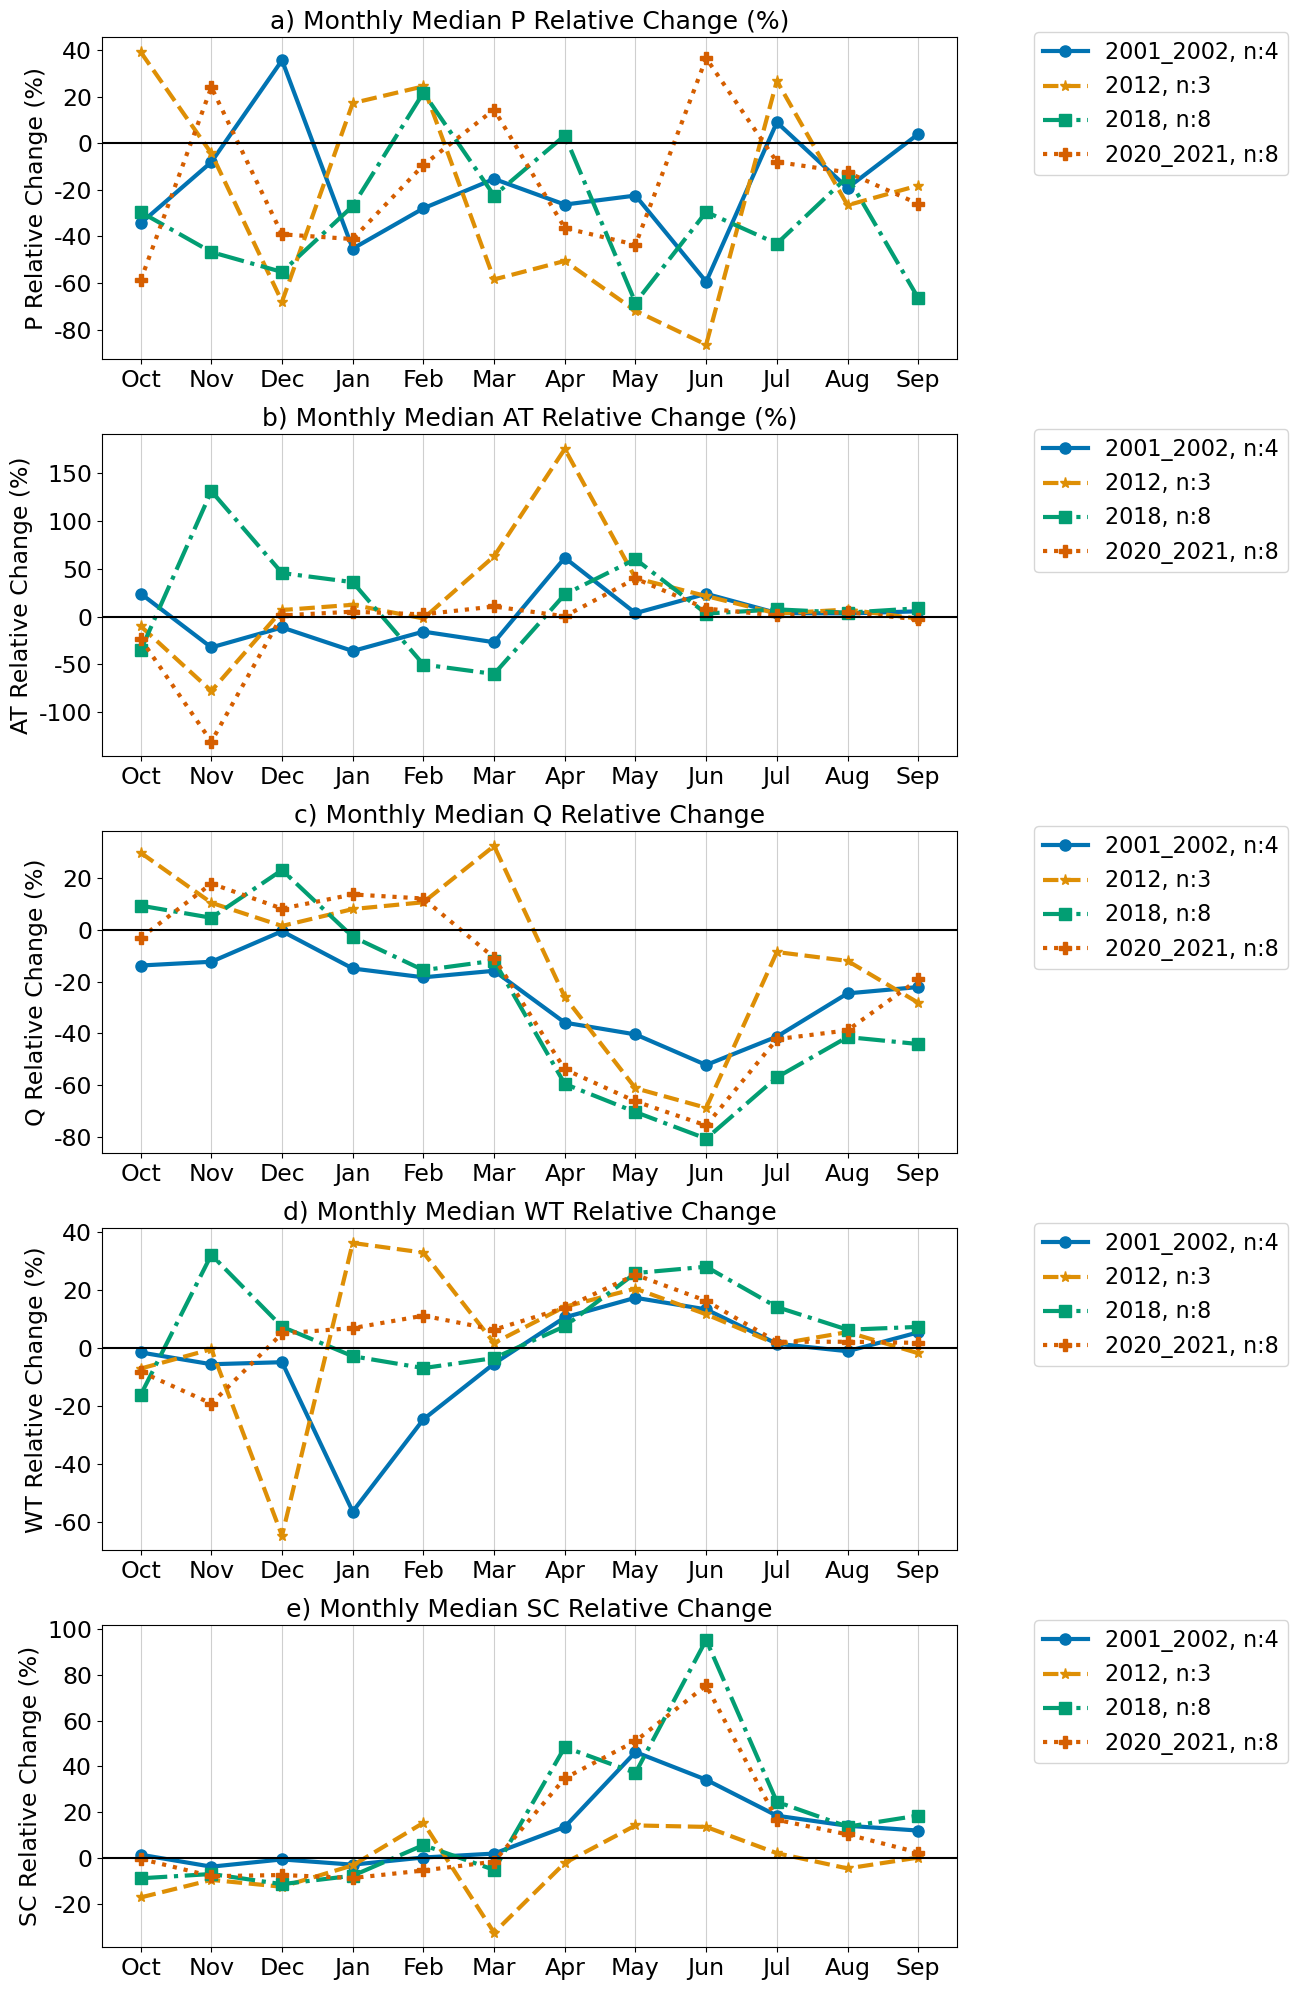

In [156]:
## PLOT: Monthly Rel.Change, VARS+MET, Episodes
with_precip_temp = True
same_yaxis = False
title_label = ['a) ','b) ','c) ','d) ','e) ']
if with_precip_temp:
    figsize=(14,20)
    fig,axs = plt.subplots(nrows=5, ncols=1,figsize=figsize)#,sharex=True)
else:
    figsize=(14,10)
    fig,axs = plt.subplots(nrows=5, ncols=1,figsize=figsize)#,sharex=True)
    
fontsize=16
for i,ax in enumerate(axs):
    if i == 2 or i == 3 or i == 4:    
        var2_plot = var_names[i-2]
        if var2_plot == var_names[0]:
            var_plot_name = 'Q'
        if var2_plot == var_names[1]:
            var_plot_name = 'WT'
        if var2_plot == var_names[2]:
            var_plot_name = 'SC'

        ax.set_ylabel(var_plot_name+' Relative Change (%)', fontsize=fontsize+1)
        ax.set_title(title_label[i] +'Monthly Median '+var_plot_name+' Relative Change', fontsize=fontsize+2)

        handles = []
        for dr in dr_names:
            data = vars()[var2_plot+'_mon_MEDrelchange_'+dr][vars()['all3_ann_MEDrelchange_' +dr].index.values]
            vars()['line1_'+dr], = ax.plot(wmon_names,data.median(axis=1),color=dr_colors[dr],
                                           label=dr+', n:'+str(len(data.columns)), 
                                           markersize=8, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=3)
            handles.append(vars()['line1_'+dr])
    
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(fontsize+1)

        ax.axhline(y=0.0, color='black', linestyle='-')
        ax.grid(axis='x',alpha=0.6)
        #ax.legend(handles=handles,loc='best', prop={"size":fontsize})
        ax.legend(bbox_to_anchor=(1.4, 1.05),handles=handles,loc='upper right', prop={"size":fontsize})
        if same_yaxis:
            ax.set_ylim(bottom=-150,top=175)
       
    if i == 0 or i ==1:
        met2plot = MET_vars[i]
        if met2plot == MET_vars[0]:
            met_plot_name = 'P'
        if met2plot == MET_vars[1]:
            met_plot_name = 'AT'
        ax.set_ylabel(f'{met_plot_name} Relative Change (%)', fontsize=fontsize+1)
        ax.set_title(f'{title_label[i]}Monthly Median {met_plot_name} Relative Change (%)', fontsize=fontsize+2)

        handles = []
        for dr in dr_names: 
            data = vars()[met2plot+'_mon_MEDrelchange_'+dr][vars()['all3_ann_MEDrelchange_' +dr].index.values]
            vars()['line1_'+dr], = ax.plot(wmon_names,vars()[met2plot+'_mon_MEDrelchange_'+dr].median(axis=1),color=dr_colors[dr],
                                           label=dr+', n:'+str(len(data.columns)), 
                                           markersize=8, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=3)
            handles.append(vars()['line1_'+str(dr)])

        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(fontsize+1)

        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        ax.axhline(y=0.0, color='black', linestyle='-')
        #ax.legend(handles=handles,loc='best', prop={"size":fontsize})
        ax.legend(bbox_to_anchor=(1.4, 1.05),handles=handles,loc='upper right', prop={"size":fontsize})
        ax.grid(axis='x',alpha=0.6)
        if same_yaxis:
            ax.set_ylim(bottom=-150,top=175)

fig.tight_layout()
if with_precip_temp:
    plt.savefig(fig_dir+'ALL3seasonal_relchangeWY_colocated.jpeg',dpi=300)
    plt.savefig(fig_dir +'ALL3seasonal_relchangeWY_colocated.svg',format="svg", transparent=True,dpi=300)
else:
    plt.savefig(fig_dir+'seasonal_relchangeWY_noPT_colocated.jpeg',dpi=300)
    plt.savefig(fig_dir +'seasonal_relchangeWY_noPT_colocated.svg',format="svg", transparent=True,dpi=300)

plt.show()

#### Recovery plots

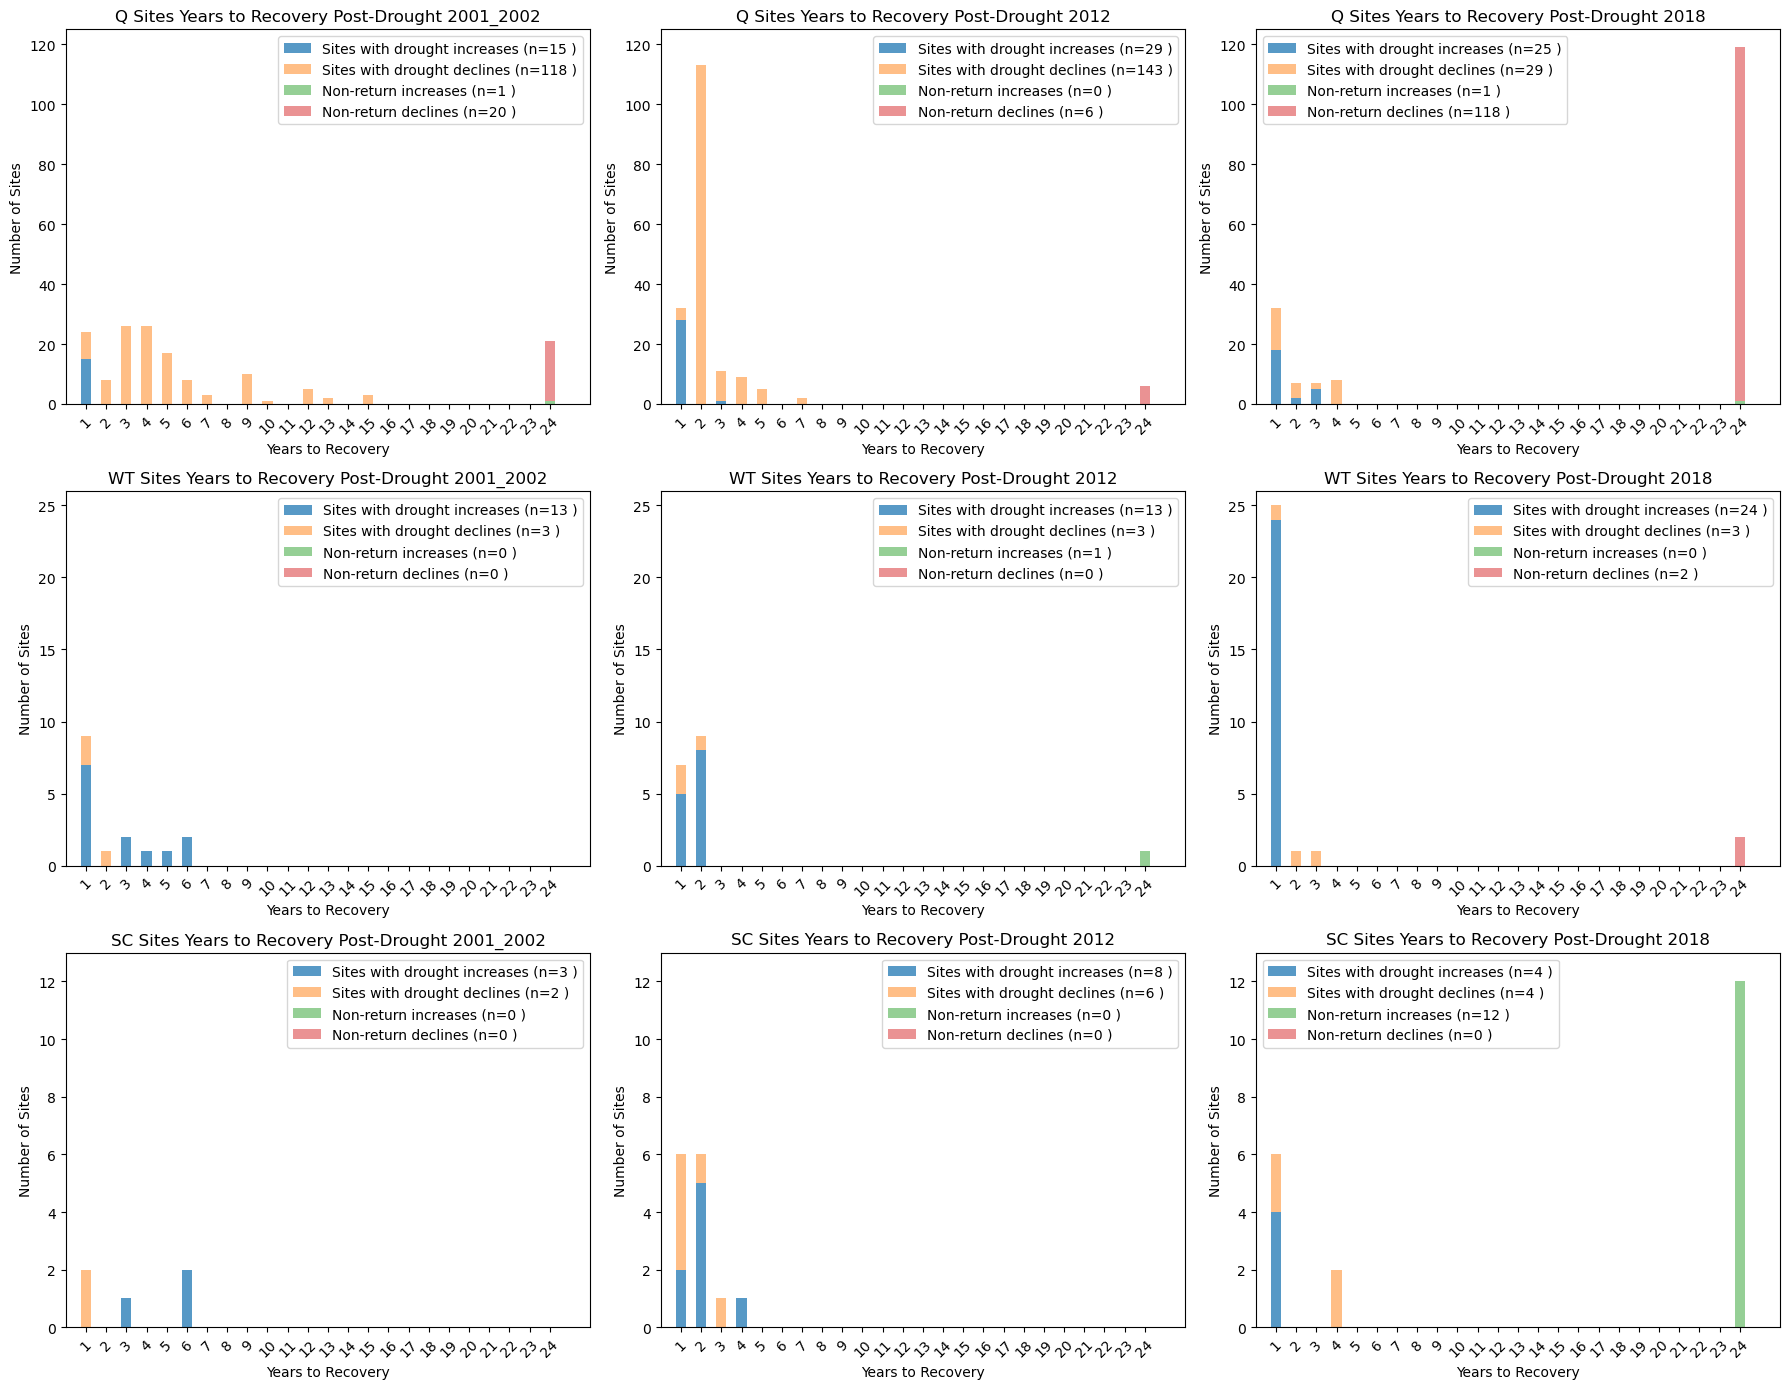

In [157]:
## Bar chart of years to recovery - x-axis will be annotated in Canva
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
bins = np.linspace(1, 25, num=25)
x = np.arange(len(bins) - 1)
bar_width = 0.5

ylims = {
    var_names[0]: (0, 125),
    var_names[1]: (0, 26),
    var_names[2]: (0, 13),
}

for i, var in enumerate(var_names):
    for j, dr in enumerate(dr_names[:-1]):
        ax = axes[i, j]

        pos_recov_counts, _ = np.histogram(vars()[f'{var}_recyears_nononrec_pos{dr}'], bins=bins)
        neg_recov_counts, _ = np.histogram(vars()[f'{var}_recyears_nononrec_neg{dr}'], bins=bins)
        notrecov_pos_counts, _ = np.histogram(vars()[f'{var}_notrecov_nomissing_pos{dr}'], bins=bins)
        notrecov_neg_counts, _ = np.histogram(vars()[f'{var}_notrecov_nomissing_neg{dr}'], bins=bins)

        ax.bar(x, pos_recov_counts, width=bar_width, alpha=0.75,
               label=f'Sites with drought increases (n={len(vars()[f"{var}_recyears_nononrec_pos{dr}"])} )')
        ax.bar(x, neg_recov_counts, width=bar_width, bottom=pos_recov_counts, alpha=0.5,
               label=f'Sites with drought declines (n={len(vars()[f"{var}_recyears_nononrec_neg{dr}"])} )')
        ax.bar(x, notrecov_pos_counts, width=bar_width,
               bottom=pos_recov_counts + neg_recov_counts, alpha=0.5,
               label=f'Non-return increases (n={len(vars()[f"{var}_notrecov_nomissing_pos{dr}"])} )')
        ax.bar(x, notrecov_neg_counts, width=bar_width,
               bottom=pos_recov_counts + neg_recov_counts + notrecov_pos_counts, alpha=0.5,
               label=f'Non-return declines (n={len(vars()[f"{var}_notrecov_nomissing_neg{dr}"])} )')

        label_var = 'Q' if var == var_names[0] else var
        ax.set_title(f'{label_var} Sites Years to Recovery Post-Drought {dr}')
        ax.set_xlabel('Years to Recovery')
        ax.set_ylabel('Number of Sites')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{int(edge)}' for edge in bins[:-1]], rotation=45)
        ax.set_xlim(-1, 25)
        ax.set_ylim(*ylims[var])
        ax.legend()

fig.tight_layout()
plt.savefig(fig_dir + 'All3_yearstorecoveryhist.jpeg', dpi=300)
plt.savefig(fig_dir + 'All3_yearstorecoveryhist.svg',format="svg", transparent=True,dpi=300)
plt.show()

#### Map of Annual Avg Relative Change

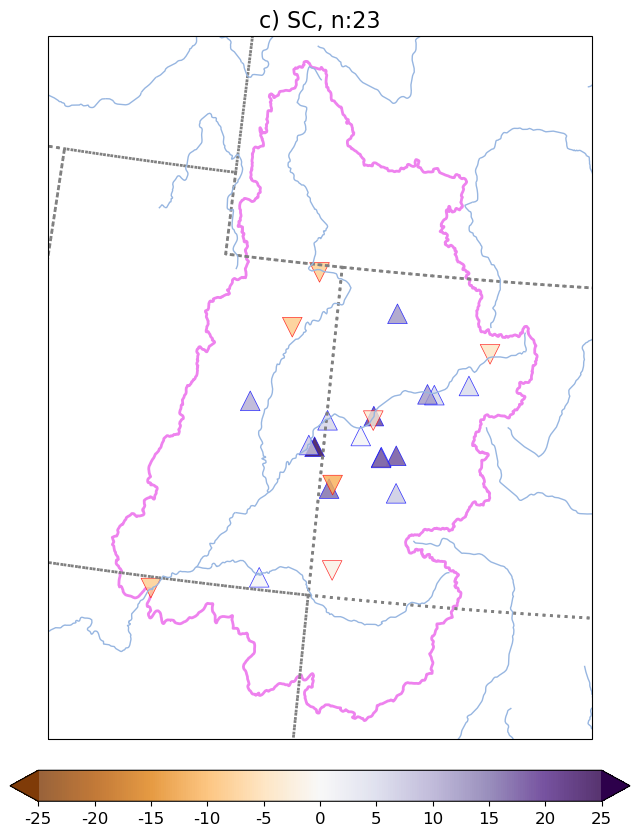

In [173]:
###### HAVE TO RUN 2 TIMES FOR ALL 2 VARIABLES
## MAP: Annual Rel.change, separated by VAR
# CHOOSE VARIABLE TO MAP - THIS ONE IS SET UP FOR WT AND SC
var = var_names[2]
figure = plt.figure(figsize=(8,10))
colorscheme ='PuOr' #'PuOr'for WT and SC # 'bwr_r' for Q

ax = figure.add_subplot(1,1,1, projection=crs.AlbersEqualArea(central_latitude=39.5,central_longitude=-98.35))
ax.add_feature(cfeature.COASTLINE, linestyle=':', edgecolor= 'grey', linewidth= 2)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor= 'grey', linewidth= 2)

# Zoom in on the US by setting longitude/latitude parameters
ax.set_extent([-113, -105, 35.5, 43.5],crs=crs.PlateCarree())
ax.add_feature(cfeature.RIVERS)

fname = upper_colorado_river_boundary_dir / 'Upper_Colorado_River_Basin_Boundary.shp'
shape_feature = ShapelyFeature(shpreader(fname).geometries(),crs.PlateCarree(), edgecolor='violet', facecolor='white',lw=2)
ax.add_feature(shape_feature,zorder=-1)        

data = vars()[var+'_MEDrelchange_map_all3']

vmax = 25
vmin = -25
d = data[(data['Relative Change (%)'] >= 0)] # & (data['CLASS']=='Non-Ref')

if var == var_names[1]:
    data_NOpubs = vars()[var_names[1]+'_MEDrelchange_map_all3'].drop(PUBS_sites_all3,errors='ignore')
    d = data_NOpubs[(data_NOpubs['Relative Change (%)'] >= 0)] #& (data_NOpubs['CLASS']=='Non-Ref')
plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                   marker= '^', edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

d = data[(data['Relative Change (%)'] < 0) ] # & (data['CLASS']=='Non-Ref')
plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                   marker= 'v',edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

if var == var_names[1]:
    valid_columns = vars()[var_names[1]+'_MEDrelchange_map_all3'].index.intersection(PUBS_sites_all3)
    data_pubs = vars()[var_names[1]+'_MEDrelchange_map_all3'].loc[valid_columns]
    d = data_pubs[(data_pubs['Relative Change (%)'] >= 0) ] # & (data_pubs['CLASS']=='Non-Ref')
    plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                       marker= '^',edgecolors='lime',linewidth=1,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    d = data_pubs[(data_pubs['Relative Change (%)'] < 0) ] # & (data_pubs['CLASS']=='Non-Ref')
    plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                       marker= 'v',edgecolors='lime', linewidth=1,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

dref = data[(data['CLASS']=='Ref')]
if len(dref) > 0:
    plot = plt.scatter(x=dref.LON, y=dref.LAT, c='black',s= 100, alpha=0.8,
                   marker= '.', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)


cbarplot = plt.scatter(x=data.LON, y=data.LAT, c=data['Relative Change (%)'],cmap = colorscheme,s= 0,alpha=0.8,
                       marker= '^',transform=crs.PlateCarree(),vmin = vmin, vmax = vmax)

vmin, vmax = -25, 25
ticks = np.arange(vmin, vmax + 5, 5)

cbar = plt.colorbar(
    cbarplot,
    fraction=0.046,
    pad=0.04,
    extend='both',
    orientation='horizontal',
    ticks=ticks
)
cbar.set_ticklabels([str(t) for t in ticks])
cbar.ax.tick_params(labelsize=12) 

if var == var_names[1]:
    ax.set_title('b) '+var+', n:'+str(len(data.index)),fontsize=16)    
if var == var_names[2]:
    ax.set_title('c) '+var+', n:'+str(len(data.index)),fontsize=16)  

plt.savefig(fig_dir + var+'_locations_Wpristine.jpeg',format='jpeg',dpi=300)
plt.savefig(fig_dir + var+'_locations_Wpristine.svg',format="svg", transparent=True,dpi=300)
plt.show()

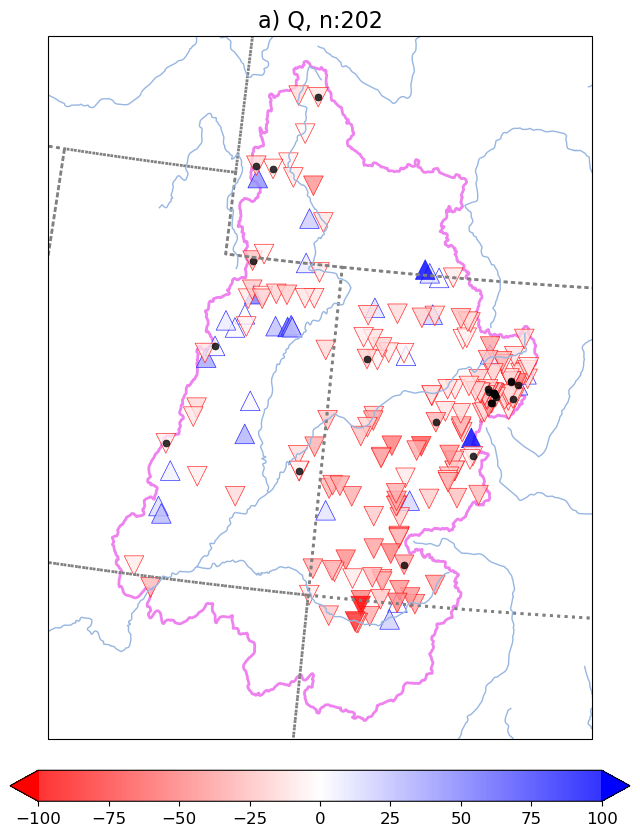

In [159]:
## MAP: Annual Rel.change, separated by VAR
# CHOOSE VARIABLE TO MAP - this one is set up for Q 
var = var_names[0]
figure = plt.figure(figsize=(8,10))
colorscheme ='bwr_r' #'PuOr'for WT and SC # 'bwr_r' for Q

ax = figure.add_subplot(1,1,1, projection=crs.AlbersEqualArea(central_latitude=39.5,central_longitude=-98.35))
ax.add_feature(cfeature.COASTLINE, linestyle=':', edgecolor= 'grey', linewidth= 2)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor= 'grey', linewidth= 2)

# Zoom in on the US by setting longitude/latitude parameters
ax.set_extent([-113, -105, 35.5, 43.5],crs=crs.PlateCarree())
ax.add_feature(cfeature.RIVERS)

fname = upper_colorado_river_boundary_dir / 'Upper_Colorado_River_Basin_Boundary.shp'
shape_feature = ShapelyFeature(shpreader(fname).geometries(),crs.PlateCarree(), edgecolor='violet', facecolor='white',lw=2)
ax.add_feature(shape_feature,zorder=-1)        

data = vars()[var+'_MEDrelchange_map_all3']
vmax = 100
vmin = -100

d = data[(data['Relative Change (%)'] >= 0) ] # & (data['CLASS']=='Non-Ref')]
plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                   marker= '^', edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

d = data[(data['Relative Change (%)'] < 0) ] # & (data['CLASS']=='Non-Ref')
plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                   marker= 'v',edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

dref = data[(data['CLASS']=='Ref')]
if len(dref) > 0:
    plot = plt.scatter(x=dref.LON, y=dref.LAT, c='black',s= 100, alpha=0.8,
                   marker= '.', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)



cbarplot = plt.scatter(x=data.LON, y=data.LAT, c=data['Relative Change (%)'],cmap = colorscheme,s= 0,alpha=0.8,
                       marker= '^',transform=crs.PlateCarree(),vmin = vmin, vmax = vmax)


cbar= plt.colorbar(cbarplot,fraction=0.046,pad=0.04, extend= 'both', orientation= 'horizontal')
cbar.ax.tick_params(labelsize=12)

var = 'Q'
ax.set_title('a) '+var+', n:'+str(len(data.index)),fontsize=16)   

plt.savefig(fig_dir+var+'_locations_Wpristine.jpeg',format='jpeg',dpi=300)
plt.savefig(fig_dir + var+'_locations_Wpristine.svg',format="svg", transparent=True,dpi=300)
plt.show()

#### Mapping 95th and 5th

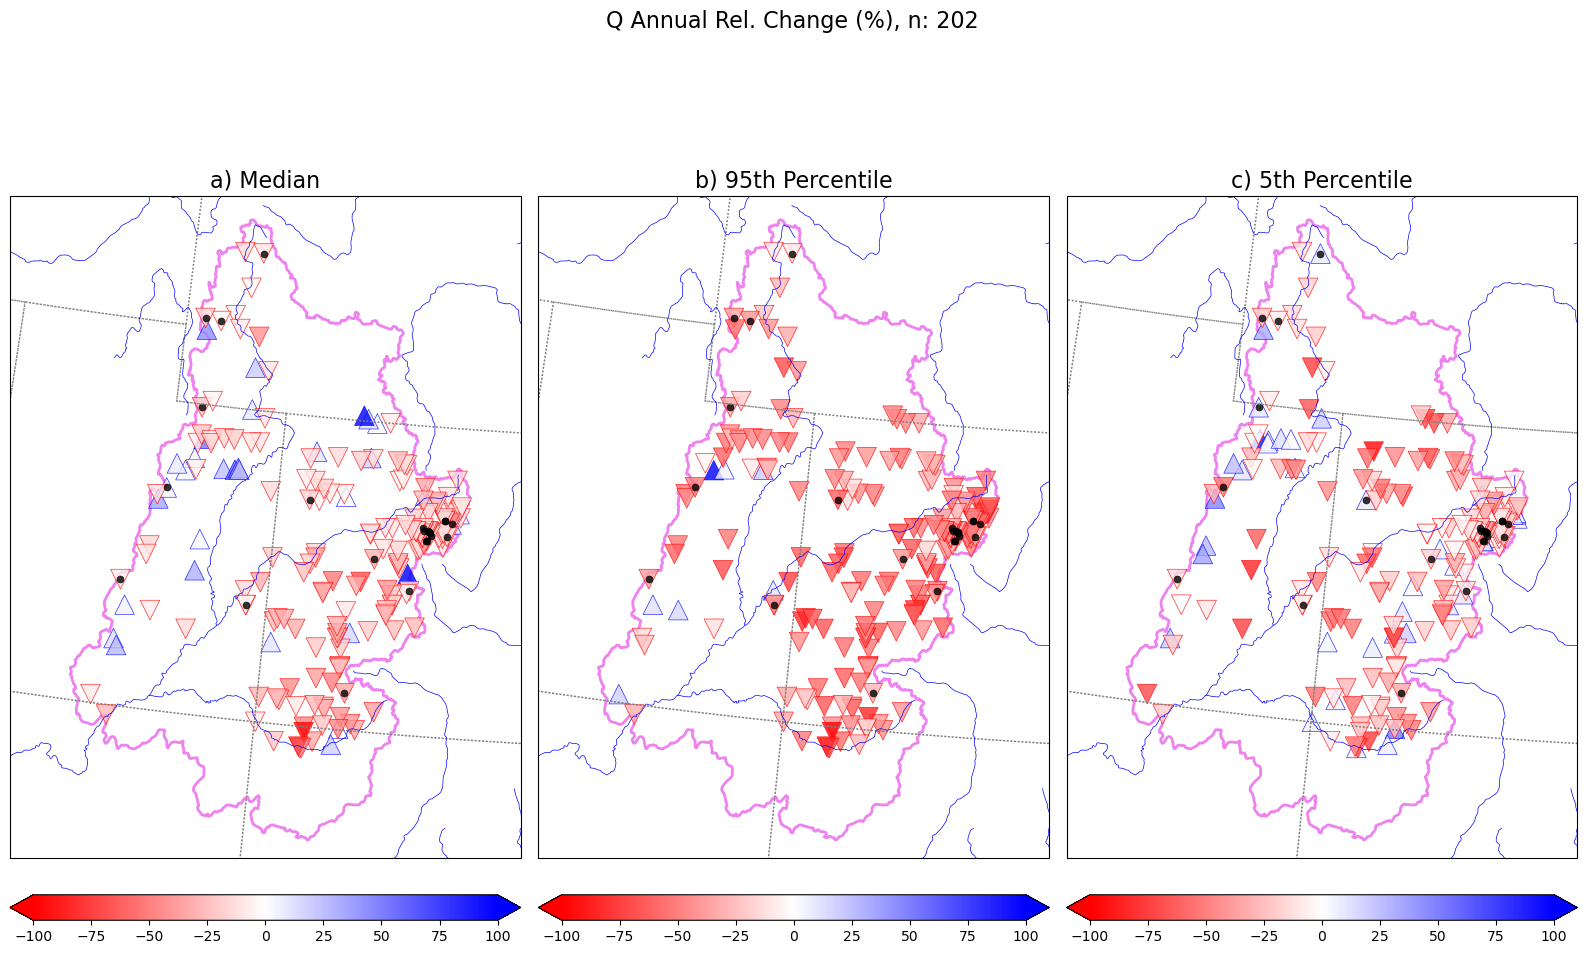

In [160]:
plot_vars = min_max
colorscheme ='bwr_r' #'PuOr'for WT and SC # 'bwr_r' for Q
var_2plot = var_names[0]
fig, axes = plt.subplots(
    nrows=1, ncols=3,figsize=(16, 10),
    subplot_kw={
        'projection': crs.AlbersEqualArea(
            central_latitude=39.5,
            central_longitude=-98.35)})

fig.suptitle("Q Annual Rel. Change (%), n: "+str(len(vars()[var_2plot+'list_mapping_return_5'][0].index)),fontsize=16, y=0.95)
# common shapefile for the basin boundary
fname = upper_colorado_river_boundary_dir / 'Upper_Colorado_River_Basin_Boundary.shp'
shape_feature = ShapelyFeature(
    shpreader(str(fname)).geometries(),
    crs.PlateCarree(),edgecolor='violet',facecolor='white',lw=2)

for ax, var in zip(axes[1:], plot_vars):
    # add coastlines, states, rivers
    ax.add_feature(cfeature.COASTLINE, linestyle=':', edgecolor='grey', linewidth=1)
    ax.add_feature(cfeature.STATES,    linestyle=':', edgecolor='grey', linewidth=1)
    ax.add_feature(cfeature.RIVERS,    edgecolor='blue', linewidth=0.5)
    ax.add_feature(shape_feature, zorder=-1)

    # zoom into the basin
    ax.set_extent([-113, -105, 35.5, 43.5], crs=crs.PlateCarree())

    # get the data
    data = vars()[var_2plot+'list_mapping_return_'+var][0]

    # choose vmin/vmax by variable
    vmin, vmax = -100, 100

    d = data[(data['Relative Change (%)'] >= 0)]# & (data['CLASS']=='Non-Ref')]
    ax.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                   marker= '^', edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    d = data[(data['Relative Change (%)'] < 0) ] # & (data['CLASS']=='Non-Ref')
    ax.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                   marker= 'v',edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    dref = data[(data['CLASS']=='Ref')]
    if len(dref) > 0:
        ax.scatter(x=dref.LON, y=dref.LAT, c='black', s= 100,alpha=0.8,
                   marker= '.',# edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    
    # add a small invisible scatter just for the colorbar
    cb = ax.scatter(
        [], [],c=[],cmap='bwr_r',vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(
        cb, ax=ax,
        orientation='horizontal',
        fraction=0.05, pad=0.04,
        extend='both')
    cbar.ax.tick_params(labelsize=10)

    # title
    if var == min_max[0]:
        ax.set_title('b) '+var+'th Percentile',fontsize=16)   
    if var == min_max[1]:
        ax.set_title('c) '+var+'th Percentile',fontsize=16)     

# add coastlines, states, rivers
axes[0].add_feature(cfeature.COASTLINE, linestyle=':', edgecolor='grey', linewidth=1)
axes[0].add_feature(cfeature.STATES,    linestyle=':', edgecolor='grey', linewidth=1)
axes[0].add_feature(cfeature.RIVERS,    edgecolor='blue', linewidth=0.5)
axes[0].add_feature(shape_feature, zorder=-1)

# zoom into the basin
axes[0].set_extent([-113, -105, 35.5, 43.5], crs=crs.PlateCarree())

    # get the data
data = RDC_MEDrelchange_map_all3

# choose vmin/vmax by variable
vmin, vmax = -100, 100

d = data[(data['Relative Change (%)'] >= 0) ] # & (data['CLASS']=='Non-Ref')]
axes[0].scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                   marker= '^', edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

d = data[(data['Relative Change (%)'] < 0) ] # & (data['CLASS']=='Non-Ref')
axes[0].scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                   marker= 'v',edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

## add marker for pristine sites
dref = data[(data['CLASS']=='Ref')]
if len(dref) > 0:
    axes[0].scatter(x=dref.LON, y=dref.LAT, c='black', s= 100,alpha=0.8,
                   marker= '.',# edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

# add a small invisible scatter just for the colorbar
cb = axes[0].scatter(
        [], [],c=[],cmap='bwr_r',vmin=vmin, vmax=vmax)
cbar = fig.colorbar(
        cb, ax=axes[0],
        orientation='horizontal',
        fraction=0.05, pad=0.04,
        extend='both')
cbar.ax.tick_params(labelsize=10)

# title
axes[0].set_title('a) Median',fontsize=16)   

plt.tight_layout()
plt.savefig(fig_dir+'RDC_locations_percentiles_Wpristine.jpeg',format='jpeg',dpi=300)
plt.savefig(fig_dir +'RDC_locations_percentiles_Wpristine.svg',format="svg", transparent=True,dpi=300)
plt.show()

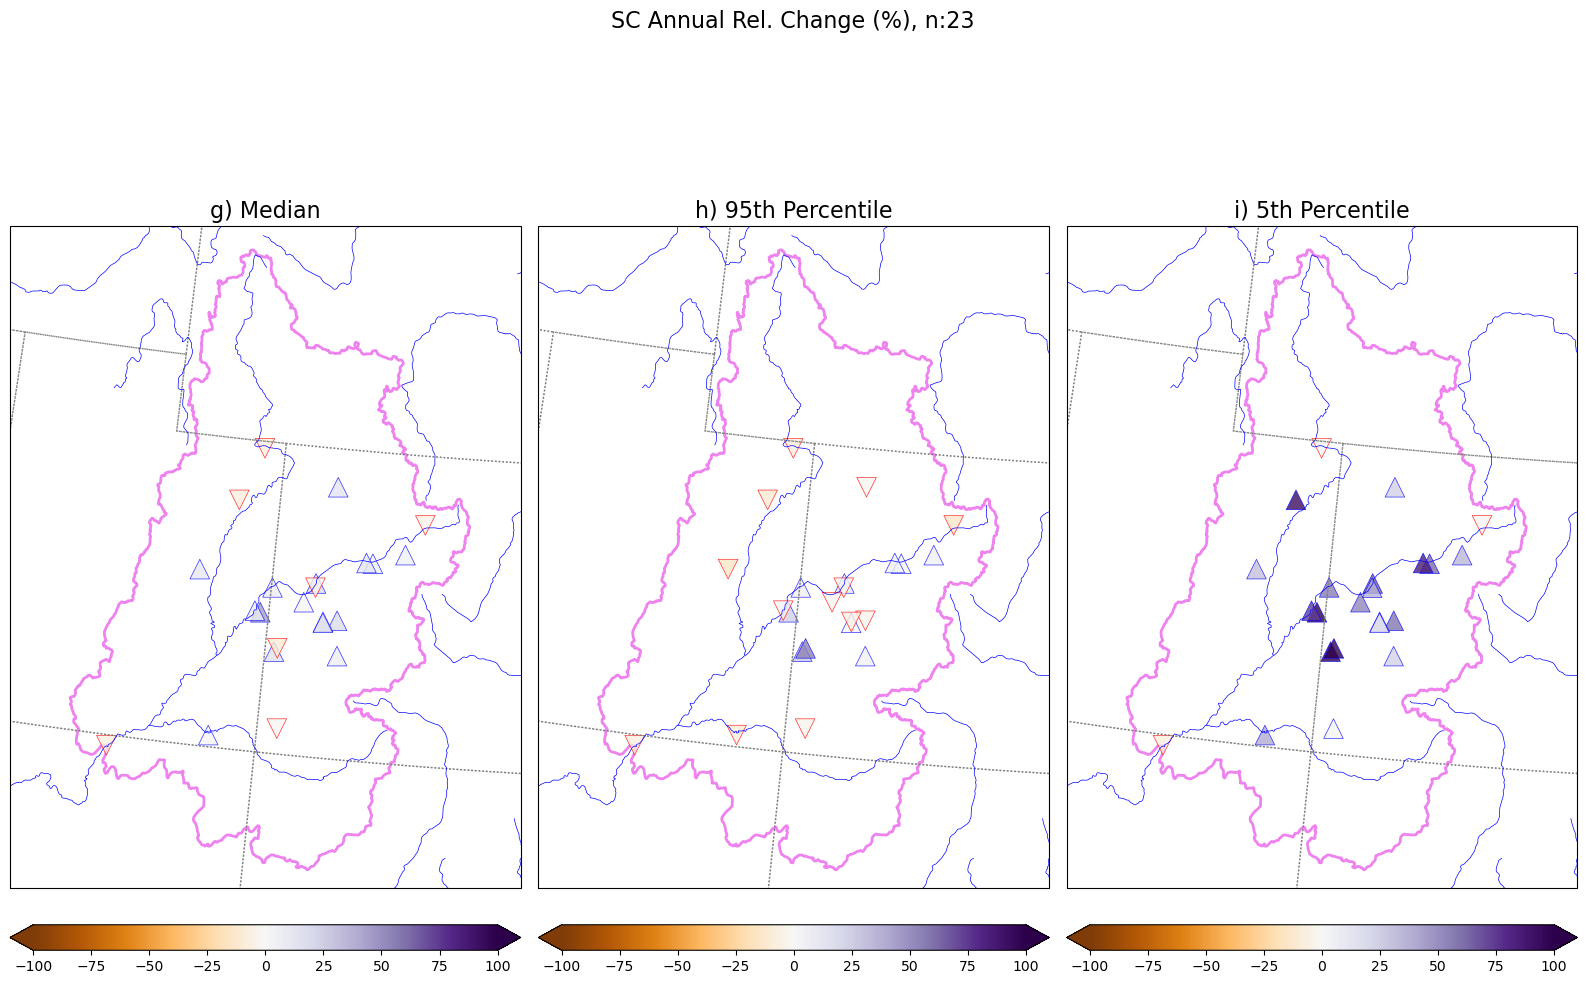

In [174]:
###### HAVE TO RUN 2 TIMES FOR ALL 3 VARIABLES: WT and SC
plot_vars = min_max
colorscheme ='PuOr' #'PuOr'for WT and SC # 'bwr_r' for Q
var_2plot = var_names[2]
fig, axes = plt.subplots(
    nrows=1, ncols=3,figsize=(16, 10),
    subplot_kw={
        'projection': crs.AlbersEqualArea(
            central_latitude=39.5,
            central_longitude=-98.35)})

fig.suptitle(var_2plot +" Annual Rel. Change (%), n:"+str(len(vars()[var_2plot+'list_mapping_return_5'][0].index)),fontsize=16)
# common shapefile for the basin boundary
fname = upper_colorado_river_boundary_dir / 'Upper_Colorado_River_Basin_Boundary.shp'
shape_feature = ShapelyFeature(
    shpreader(str(fname)).geometries(),
    crs.PlateCarree(),edgecolor='violet',facecolor='white',lw=2)

for ax, var in zip(axes[1:], plot_vars):
    # add coastlines, states, rivers
    ax.add_feature(cfeature.COASTLINE, linestyle=':', edgecolor='grey', linewidth=1)
    ax.add_feature(cfeature.STATES,    linestyle=':', edgecolor='grey', linewidth=1)
    ax.add_feature(cfeature.RIVERS,    edgecolor='blue', linewidth=0.5)
    ax.add_feature(shape_feature, zorder=-1)

    # zoom into the basin
    ax.set_extent([-113, -105, 35.5, 43.5], crs=crs.PlateCarree())

    # get the data
    data = vars()[var_2plot+'list_mapping_return_'+var][0]

    # choose vmin/vmax by variable
    vmin, vmax = -100, 100
    
    d = data[(data['Relative Change (%)'] >= 0) ]#& (data['CLASS']=='Non-Ref')]
    ax.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                   marker= '^', edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    d = data[(data['Relative Change (%)'] < 0) ] # & (data['CLASS']=='Non-Ref')
    ax.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                   marker= 'v',edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)
    
    if var_2plot == var_names[1]:
        valid_columns = data.index.intersection(PUBS_sites_all3)
        data_pubs = data.loc[valid_columns]
        d = data_pubs[(data_pubs['Relative Change (%)'] >= 0) ] # & (data_pubs['CLASS']=='Non-Ref')
        ax.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                       marker= '^',edgecolors='lime',linewidth=1,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

        d = data_pubs[(data_pubs['Relative Change (%)'] < 0) ] # & (data_pubs['CLASS']=='Non-Ref')
        ax.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                       marker= 'v',edgecolors='lime', linewidth=1,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    dref = data[(data['CLASS']=='Ref')]
    if len(dref) > 0:
        ax.scatter(x=dref.LON, y=dref.LAT, c='black', s= 100,alpha=0.8,
                   marker= '.',# edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    # add a small invisible scatter just for the colorbar
    cb = ax.scatter(
        [], [],c=[],cmap='PuOr',vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(
        cb, ax=ax,
        orientation='horizontal',
        fraction=0.05, pad=0.04,
        extend='both')
    cbar.ax.tick_params(labelsize=10)

    # title
    if (var_2plot == var_names[1]):
        if (var == min_max[0]):
            ax.set_title('e) '+var+'th Percentile',fontsize=16)   
        if (var == min_max[1]):  
            ax.set_title('f) '+var+'th Percentile',fontsize=16) 
    if var_2plot == var_names[2]:
        if (var == min_max[0]):
            ax.set_title('h) '+var+'th Percentile',fontsize=16)   
        if (var == min_max[1]):  
            ax.set_title('i) '+var+'th Percentile',fontsize=16)  

# add coastlines, states, rivers
axes[0].add_feature(cfeature.COASTLINE, linestyle=':', edgecolor='grey', linewidth=1)
axes[0].add_feature(cfeature.STATES,    linestyle=':', edgecolor='grey', linewidth=1)
axes[0].add_feature(cfeature.RIVERS,    edgecolor='blue', linewidth=0.5)
axes[0].add_feature(shape_feature, zorder=-1)

# zoom into the basin
axes[0].set_extent([-113, -105, 35.5, 43.5], crs=crs.PlateCarree())

# get the data
data = vars()[var_2plot+'_MEDrelchange_map_all3']

# choose vmin/vmax by variable
vmin, vmax = -100, 100

d = data[(data['Relative Change (%)'] >= 0)]# & (data['CLASS']=='Non-Ref')]
axes[0].scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                   marker= '^', edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

d = data[(data['Relative Change (%)'] < 0) ] # & (data['CLASS']=='Non-Ref')
axes[0].scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                   marker= 'v',edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

if var_2plot == var_names[1]:
    valid_columns = data.index.intersection(PUBS_sites_all3)
    data_pubs = data.loc[valid_columns]
    d = data_pubs[(data_pubs['Relative Change (%)'] >= 0) ] # & (data_pubs['CLASS']=='Non-Ref')
    axes[0].scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 200, alpha=0.8,
                       marker= '^',edgecolors='lime',linewidth=1,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    d = data_pubs[(data_pubs['Relative Change (%)'] < 0) ] # & (data_pubs['CLASS']=='Non-Ref')
    axes[0].scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 200,alpha=0.8,
                       marker= 'v',edgecolors='lime', linewidth=1,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

dref = data[(data['CLASS']=='Ref')]
if len(dref) > 0:
    axes[0].scatter(x=dref.LON, y=dref.LAT, c='black', s= 100,alpha=0.8,
                   marker= '.',# edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

# add a small invisible scatter just for the colorbar
cb = axes[0].scatter(
        [], [],c=[],cmap='PuOr',vmin=vmin, vmax=vmax)
cbar = fig.colorbar(
        cb, ax=axes[0],
        orientation='horizontal',
        fraction=0.05, pad=0.04,
        extend='both')
cbar.ax.tick_params(labelsize=10)

# title
if var_2plot == var_names[1]:
    axes[0].set_title('d) Median',fontsize=16)   
if var_2plot == var_names[2]:
    axes[0].set_title('g) Median',fontsize=16)      

plt.tight_layout()
plt.savefig(fig_dir+var_2plot+'_locations_percentiles_Wpristine.jpeg',format='jpeg',dpi=300)
plt.savefig(fig_dir+var_2plot+'_locations_percentiles_Wpristine.svg',format="svg", transparent=True,dpi=300)
plt.show()

#### Q vs P scatterplots

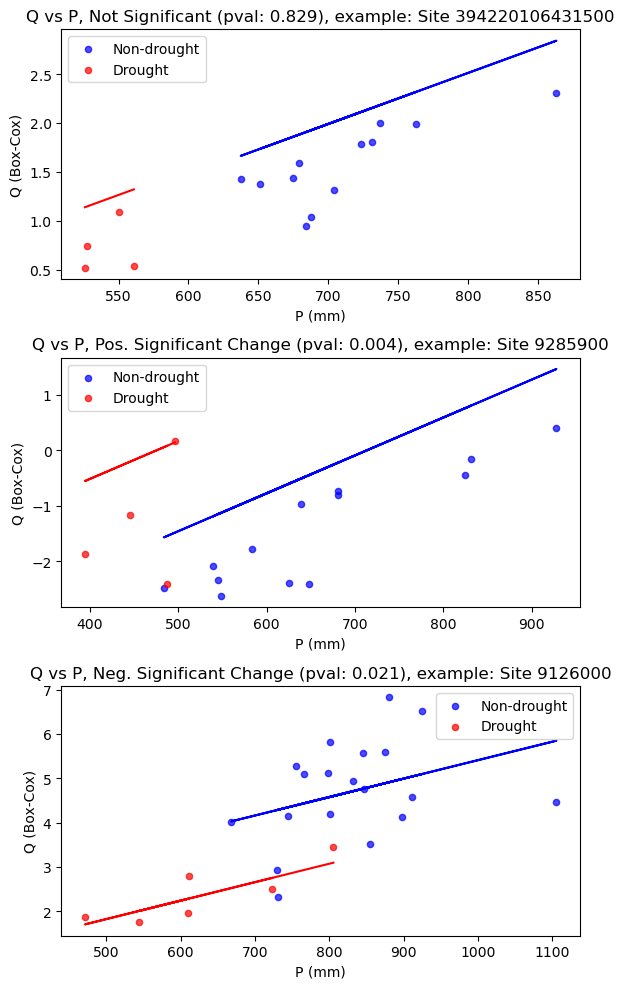

In [162]:
## SCATTERPLOT: Q vs P examples 
fig,axs = plt.subplots(nrows=3,ncols=1,figsize=(6,10))
fsize=12
fontsize2=fsize-2
## ax0 = not sig, ax1 = sig pos, ax2 = sig neg

for val,ax in enumerate(axs):
    site = sites_plot[val]

    # Extract data for site
    Q = Q_all[site]
    P = P_all[site]
    I = I_all[site]

    # Clean data (drop NaNs)
    df = pd.DataFrame({'Q': Q, 'P': P, 'I': I}).dropna()

    row = results.loc[site]
    a0, a1, a2 = row['a0'], row['a1'], row['a2']
    pval = row['pval_a1']
    
    # Scatter plot, color by drought indicator I
    colors = df['I'].map({0: 'blue', 1: 'red'})
    labels = {0: 'Non-drought', 1: 'Drought'}

    for i_val, color in zip([0,1], ['blue', 'red']):
        subset = df[df['I'] == i_val]
        ax.scatter(x=subset['P'], y=subset['Q'], c=color, label=labels[i_val], alpha=0.7,s=20)

        # # Create range of P values for regression lines
        # P_range = np.linspace(df['P'].min(), df['P'].max(), 100)

        # Regression lines:
        if i_val == 0:
            Q_line = a0 + a1*0 + a2*subset['P']
        if i_val == 1:
            Q_line = a0 + a1*1 + a2*subset['P']

        ax.plot(subset['P'], Q_line, color=color)
    
    if pval >= 0.05:
        ax.set_title(f'Q vs P, Not Significant (pval: {pval:.3f}), example: Site {site}')

    if pval < 0.05:
        if val == 1:
            ax.set_title(f'Q vs P, Pos. Significant Change (pval: {pval:.3f}), example: Site {site}')
        if val == 2:
            ax.set_title(f'Q vs P, Neg. Significant Change (pval: {pval:.3f}), example: Site {site}')
            
    ax.set_xlabel('P (mm)')
    ax.set_ylabel('Q (Box-Cox)')
    ax.legend(loc='best')
    #ax.grid(True)


    for label in (ax.get_yticklabels()):
        label.set_fontsize(fontsize2)
    
    for label in (ax.get_xticklabels()):
        label.set_fontsize(fontsize2)

fig.tight_layout()
plt.savefig(fig_dir+'p_q_examplesites.jpeg',dpi=300)
plt.savefig(fig_dir+'p_q_examplesites.svg',format="svg", transparent=True,dpi=300)
plt.show()

#### Long-term Trend

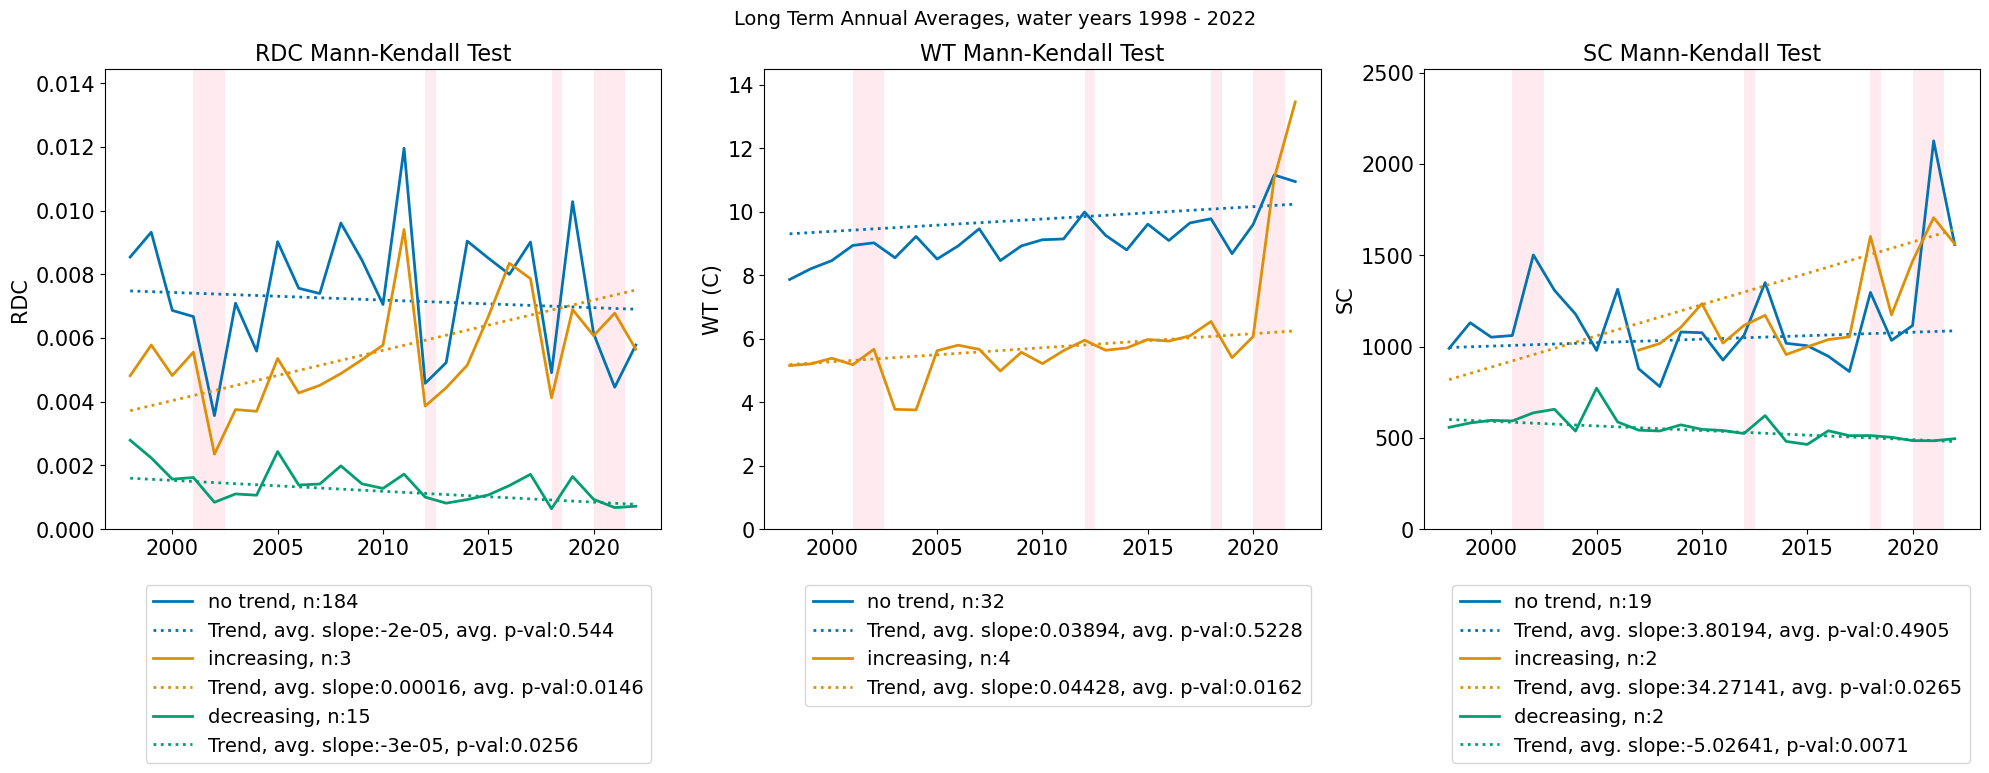

In [163]:
## PLOT: Long term ANNUAL Avg, VARS, with num of sites, MK results
figsize=(20,8)
fig,axs = plt.subplots(nrows=1,ncols=3,figsize=figsize)#,sharex=True)

fontsize=14
fig.suptitle("Long Term Annual Averages, water years 1998 - 2022",fontsize=fontsize)
for val,ax in enumerate(axs):
    var = var_names[val]
    if var == var_names[1]:
        ax.set_ylabel('WT (C)', fontsize=fontsize+1)
    else:
        ax.set_ylabel(f'{var}', fontsize=fontsize+1)
    
    ax.set_title(f"{var} Mann-Kendall Test", fontsize=fontsize+2)

    handles = []

    all_sites = vars()[var+'_years']
    all_sites_mean = vars()[var+'_years'].mean(axis=1)
    # vars()[var+'_trend_line'] = np.arange(len(vars()[var+'_annual_mean'].values)) * vars()[var+'slope'] + vars()[var+'intercept']
    notrend = vars()[var+'_years'][vars()[var+'_notrend'].index]
    notrend_sites = len(vars()[var+'_notrend'].index)
    notrend_trend_line = np.arange(len(notrend.values)) * vars()[var+'_notrend']['slope'].mean() + vars()[var+'_notrend']['intercept'].mean()
    notrend_pval = vars()[var+'_notrend']['p'].mean()
    
    line1, = ax.plot(np.arange(1998,2023,1),notrend.mean(axis=1),label='no trend, n:'+str(notrend_sites),color=met_cmap[0], markersize=4, linewidth=2)
    handles.append(line1)
    #ax.fill_between(np.arange(1992,2023,1),WT_minOf_annual_mean,WT_maxOf_annual_mean, alpha = 0.3) #markersize=6, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=2)

    line2, = ax.plot(np.arange(1998,2023,1),notrend_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_notrend']['slope'].mean(),5))+', avg. p-val:'+str(round(notrend_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[0],linestyle=':')
    handles.append(line2)

    if len(vars()[var+'_increasing'].index) != 0:
        increasing = vars()[var+'_years'][vars()[var+'_increasing'].index]
        increasing_sites = len(vars()[var+'_increasing'].index)
        increasing_trend_line = np.arange(len(increasing.values)) * vars()[var+'_increasing']['slope'].mean() + vars()[var+'_increasing']['intercept'].mean()
        increasing_pval = vars()[var+'_increasing']['p'].mean()

        line3, = ax.plot(np.arange(1998,2023,1),increasing.mean(axis=1),label='increasing, n:'+str(increasing_sites),color=met_cmap[1], markersize=4, linewidth=2)
        handles.append(line3)
        line4, = ax.plot(np.arange(1998,2023,1),increasing_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_increasing']['slope'].mean(),5))+', avg. p-val:'+str(round(increasing_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[1],linestyle=':')
        handles.append(line4)
    
    if len(vars()[var+'_decreasing'].index) != 0:
        decreasing = vars()[var+'_years'][vars()[var+'_decreasing'].index]
        decreasing_sites = len(vars()[var+'_decreasing'].index)
        decreasing_trend_line = np.arange(len(decreasing.values)) * vars()[var+'_decreasing']['slope'].mean() + vars()[var+'_decreasing']['intercept'].mean()
        decreasing_pval = vars()[var+'_decreasing']['p'].mean()

        line5, = ax.plot(np.arange(1998,2023,1),decreasing.mean(axis=1),label='decreasing, n:'+str(decreasing_sites),color=met_cmap[2], markersize=4, linewidth=2)
        handles.append(line5)
        line6, = ax.plot(np.arange(1998,2023,1),decreasing_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_decreasing']['slope'].mean(),5))+', p-val:'+str(round(decreasing_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[2],linestyle=':')
        handles.append(line6)
    

    rect2001 = mpl.patches.Rectangle((2001, 0), 1.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    rect2012 = mpl.patches.Rectangle((2012, 0), 0.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    rect2018 = mpl.patches.Rectangle((2018, 0), 0.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    rect2020 = mpl.patches.Rectangle((2020, 0), 1.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    
    # Add the patch to the axes
    ax.add_patch(rect2001)
    ax.add_patch(rect2012)
    ax.add_patch(rect2018)
    ax.add_patch(rect2020)

    ax.set_ylim(0, all_sites_mean.max()+(all_sites_mean.max()*0.3))
    
    #ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(fontsize+1)

    ax.grid(False)

    ax.legend(bbox_to_anchor=(1, -0.10),handles=handles,loc='best', prop={"size":fontsize})

fig.tight_layout()
plt.savefig(fig_dir+'ALL3_longterm_trend_MKtest_drshading.jpeg',dpi=300)
plt.savefig(fig_dir+'ALL3_longterm_trend_MKtest_drshading.svg',format="svg", transparent=True,dpi=300)
plt.show()

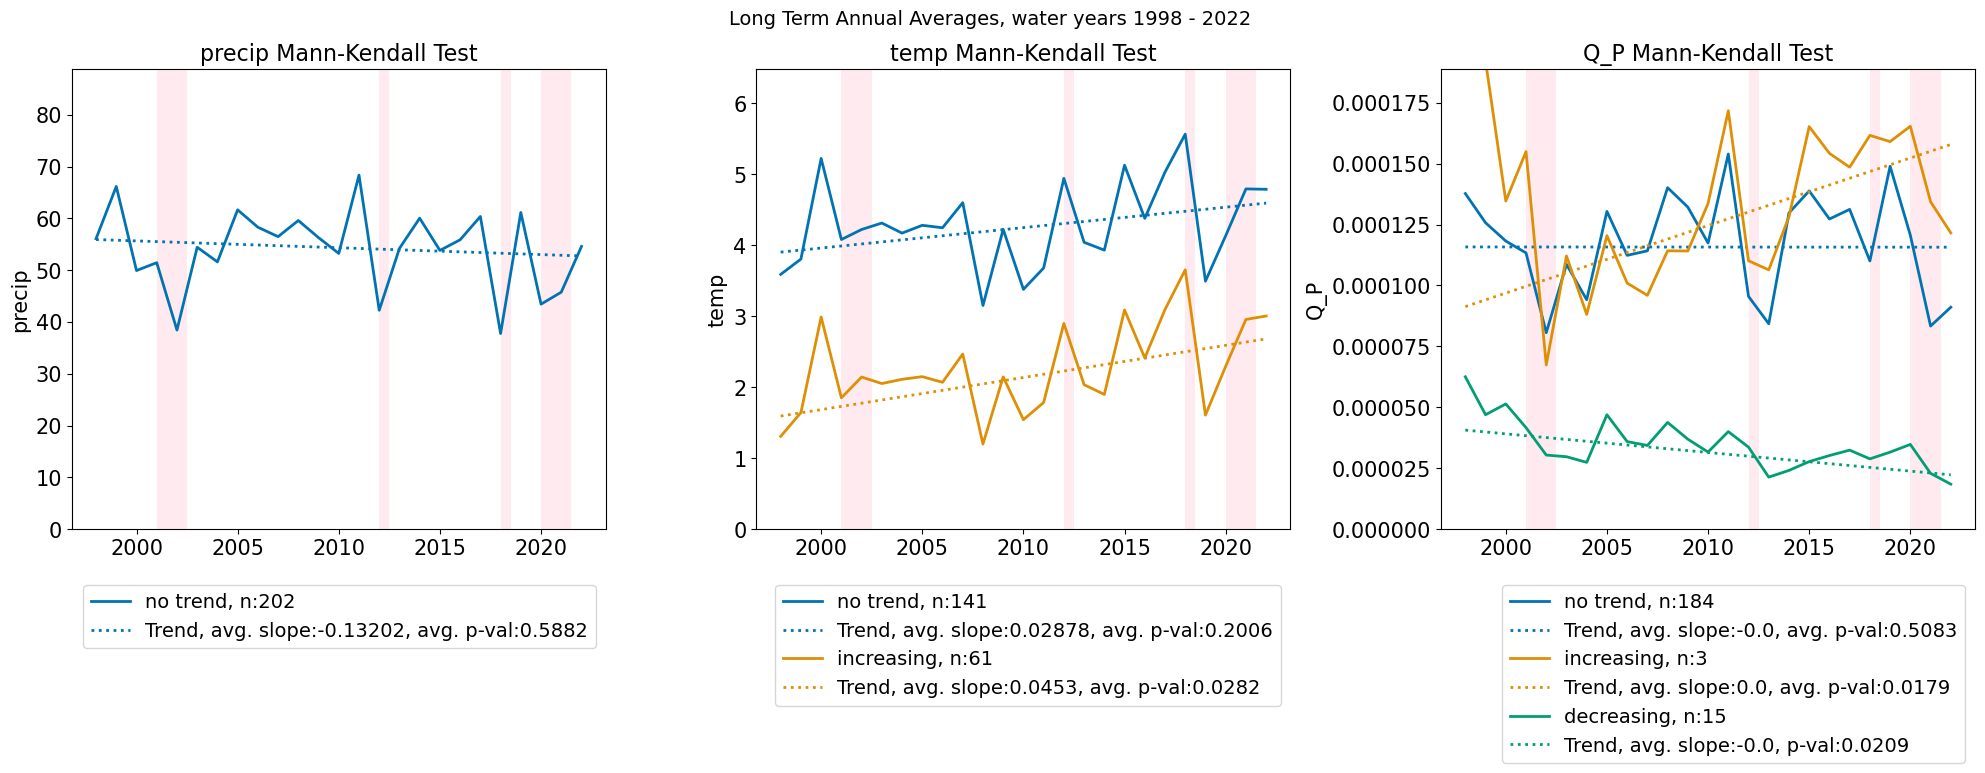

In [164]:
MET_vars_QP = ['precip', 'temp','Q_P']

## PLOT: Long term ANNUAL Avg, VARS, with num of sites, MK results
figsize=(20,8)
fig,axs = plt.subplots(nrows=1,ncols=3,figsize=figsize)#,sharex=True)

fontsize=14
fig.suptitle("Long Term Annual Averages, water years 1998 - 2022",fontsize=fontsize)
for val,ax in enumerate(axs):
    var = MET_vars_QP[val]
    if var == var_names[1]:
        ax.set_ylabel('WT (C)', fontsize=fontsize+1)
    else:
        ax.set_ylabel(f'{var}', fontsize=fontsize+1)
    
    ax.set_title(f"{var} Mann-Kendall Test", fontsize=fontsize+2)

    handles = []

    all_sites = vars()[var+'_years']
    all_sites_mean = vars()[var+'_years'].mean(axis=1)
    # vars()[var+'_trend_line'] = np.arange(len(vars()[var+'_annual_mean'].values)) * vars()[var+'slope'] + vars()[var+'intercept']
    notrend = vars()[var+'_years'][vars()[var+'_notrend'].index]
    notrend_sites = len(vars()[var+'_notrend'].index)
    notrend_trend_line = np.arange(len(notrend.values)) * vars()[var+'_notrend']['slope'].mean() + vars()[var+'_notrend']['intercept'].mean()
    notrend_pval = vars()[var+'_notrend']['p'].mean()
    
    line1, = ax.plot(np.arange(1998,2023,1),notrend.mean(axis=1),label='no trend, n:'+str(notrend_sites),color=met_cmap[0], markersize=4, linewidth=2)
    handles.append(line1)
    #ax.fill_between(np.arange(1992,2023,1),WT_minOf_annual_mean,WT_maxOf_annual_mean, alpha = 0.3) #markersize=6, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=2)

    line2, = ax.plot(np.arange(1998,2023,1),notrend_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_notrend']['slope'].mean(),5))+', avg. p-val:'+str(round(notrend_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[0],linestyle=':')
    handles.append(line2)

    if len(vars()[var+'_increasing'].index) != 0:
        increasing = vars()[var+'_years'][vars()[var+'_increasing'].index]
        increasing_sites = len(vars()[var+'_increasing'].index)
        increasing_trend_line = np.arange(len(increasing.values)) * vars()[var+'_increasing']['slope'].mean() + vars()[var+'_increasing']['intercept'].mean()
        increasing_pval = vars()[var+'_increasing']['p'].mean()

        line3, = ax.plot(np.arange(1998,2023,1),increasing.mean(axis=1),label='increasing, n:'+str(increasing_sites),color=met_cmap[1], markersize=4, linewidth=2)
        handles.append(line3)
        line4, = ax.plot(np.arange(1998,2023,1),increasing_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_increasing']['slope'].mean(),5))+', avg. p-val:'+str(round(increasing_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[1],linestyle=':')
        handles.append(line4)
    
    if len(vars()[var+'_decreasing'].index) != 0:
        decreasing = vars()[var+'_years'][vars()[var+'_decreasing'].index]
        decreasing_sites = len(vars()[var+'_decreasing'].index)
        decreasing_trend_line = np.arange(len(decreasing.values)) * vars()[var+'_decreasing']['slope'].mean() + vars()[var+'_decreasing']['intercept'].mean()
        decreasing_pval = vars()[var+'_decreasing']['p'].mean()

        line5, = ax.plot(np.arange(1998,2023,1),decreasing.mean(axis=1),label='decreasing, n:'+str(decreasing_sites),color=met_cmap[2], markersize=4, linewidth=2)
        handles.append(line5)
        line6, = ax.plot(np.arange(1998,2023,1),decreasing_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_decreasing']['slope'].mean(),5))+', p-val:'+str(round(decreasing_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[2],linestyle=':')
        handles.append(line6)
    

    rect2001 = mpl.patches.Rectangle((2001, 0), 1.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    rect2012 = mpl.patches.Rectangle((2012, 0), 0.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    rect2018 = mpl.patches.Rectangle((2018, 0), 0.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    rect2020 = mpl.patches.Rectangle((2020, 0), 1.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    
    # Add the patch to the axes
    ax.add_patch(rect2001)
    ax.add_patch(rect2012)
    ax.add_patch(rect2018)
    ax.add_patch(rect2020)

    ax.set_ylim(0, all_sites_mean.max()+(all_sites_mean.max()*0.3))
    
    #ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(fontsize+1)

    ax.grid(False)
    #ax.grid(axis='x',alpha=0.6)
    ax.legend(bbox_to_anchor=(1, -0.10),handles=handles,loc='best', prop={"size":fontsize})

fig.tight_layout()
plt.savefig(fig_dir+'MET_longterm_trend_MKtest_drshading.jpeg',dpi=300)
plt.savefig(fig_dir+'MET_longterm_trend_MKtest_drshading.svg',format="svg", transparent=True,dpi=300)
plt.show()

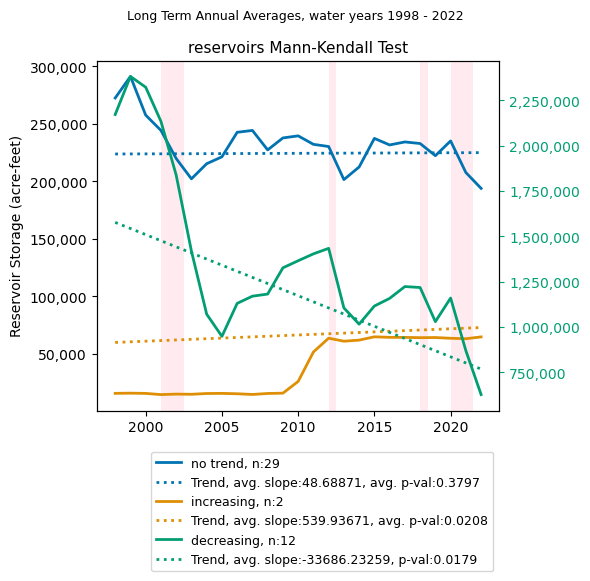

In [165]:
## MK for Reservoir storage
## PLOT: Long term ANNUAL Avg, VARS, with num of sites, MK results
figsize=(6,6)
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=figsize)#,sharex=True)

fontsize=9
fig.suptitle("Long Term Annual Averages, water years 1998 - 2022",fontsize=fontsize)
var = 'reservoirs'
ax.set_ylabel('Reservoir Storage (acre-feet)', fontsize=fontsize+1)
ax.set_title(f"{var} Mann-Kendall Test", fontsize=fontsize+2)

handles = []

all_sites = vars()[var+'_years']
all_sites_mean = vars()[var+'_years'].mean(axis=1)
# vars()[var+'_trend_line'] = np.arange(len(vars()[var+'_annual_mean'].values)) * vars()[var+'slope'] + vars()[var+'intercept']
notrend = vars()[var+'_years'][vars()[var+'_notrend'].index]
notrend_sites = len(vars()[var+'_notrend'].index)
notrend_trend_line = np.arange(len(notrend.values)) * vars()[var+'_notrend']['slope'].mean() + vars()[var+'_notrend']['intercept'].mean()
notrend_pval = vars()[var+'_notrend']['p'].mean()
    
line1, = ax.plot(np.arange(1998,2023,1),notrend.mean(axis=1),label='no trend, n:'+str(notrend_sites),color=met_cmap[0], markersize=4, linewidth=2)
handles.append(line1)
    #ax.fill_between(np.arange(1992,2023,1),WT_minOf_annual_mean,WT_maxOf_annual_mean, alpha = 0.3) #markersize=6, marker=dr_markerstyles[dr], linestyle=dr_linestyles[dr], linewidth=2)

line2, = ax.plot(np.arange(1998,2023,1),notrend_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_notrend']['slope'].mean(),5))+', avg. p-val:'+str(round(notrend_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[0],linestyle=':')
handles.append(line2)

if len(vars()[var+'_increasing'].index) != 0:
    increasing = vars()[var+'_years'][vars()[var+'_increasing'].index]
    increasing_sites = len(vars()[var+'_increasing'].index)
    increasing_trend_line = np.arange(len(increasing.values)) * vars()[var+'_increasing']['slope'].mean() + vars()[var+'_increasing']['intercept'].mean()
    increasing_pval = vars()[var+'_increasing']['p'].mean()

    line3, = ax.plot(np.arange(1998,2023,1),increasing.mean(axis=1),label='increasing, n:'+str(increasing_sites),color=met_cmap[1], markersize=4, linewidth=2)
    handles.append(line3)
    line4, = ax.plot(np.arange(1998,2023,1),increasing_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_increasing']['slope'].mean(),5))+', avg. p-val:'+str(round(increasing_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[1],linestyle=':')
    handles.append(line4)
    
if len(vars()[var+'_decreasing'].index) != 0:
    ax2 = ax.twinx() 
    ax2.grid(False)
    #ax2.set_ylabel('Number of Sites', fontsize=fontsize+2)
    #ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    for label in (ax2.get_yticklabels()):
        label.set_fontsize(fontsize+1)
    ax2.tick_params(axis='y', colors=met_cmap[2])
    decreasing = vars()[var+'_years'][vars()[var+'_decreasing'].index]
    decreasing_sites = len(vars()[var+'_decreasing'].index)
    decreasing_trend_line = np.arange(len(decreasing.values)) * vars()[var+'_decreasing']['slope'].mean() + vars()[var+'_decreasing']['intercept'].mean()
    decreasing_pval = vars()[var+'_decreasing']['p'].mean()

    line5, = ax2.plot(np.arange(1998,2023,1),decreasing.mean(axis=1),label='decreasing, n:'+str(decreasing_sites),color=met_cmap[2], markersize=4, linewidth=2)
    handles.append(line5)
    line6, = ax2.plot(np.arange(1998,2023,1),decreasing_trend_line,label='Trend, avg. slope:'+str(round(vars()[var+'_decreasing']['slope'].mean(),5))+', p-val:'+str(round(decreasing_pval,4)),
                     markersize=4, linewidth=2, color=met_cmap[2],linestyle=':')
    handles.append(line6)
    #ax.set_ylim(0, 2500000)
    #ax2.set_ylabel('Decreasing Reservoir Storage (acre-feet)', fontsize=fontsize+1)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

rect2001 = mpl.patches.Rectangle((2001, 0), 1.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
rect2012 = mpl.patches.Rectangle((2012, 0), 0.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
rect2018 = mpl.patches.Rectangle((2018, 0), 0.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
rect2020 = mpl.patches.Rectangle((2020, 0), 1.5, all_sites_mean.max()+(all_sites_mean.max()*0.3), facecolor='pink', alpha=0.3)
    
# Add the patch to the axes
ax.add_patch(rect2001)
ax.add_patch(rect2012)
ax.add_patch(rect2018)
ax.add_patch(rect2020)

#ax.set_ylim(0, 2500000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontsize(fontsize+1)

ax.grid(False)
ax.legend(bbox_to_anchor=(1, -0.10),handles=handles,loc='best', prop={"size":fontsize})

fig.tight_layout()
plt.savefig(fig_dir+'reservoir_longterm_trend_MKtest_drshading.jpeg',dpi=300)
plt.savefig(fig_dir+'reservoir_longterm_trend_MKtest_drshading.svg',format="svg", transparent=True,dpi=300)
plt.show()

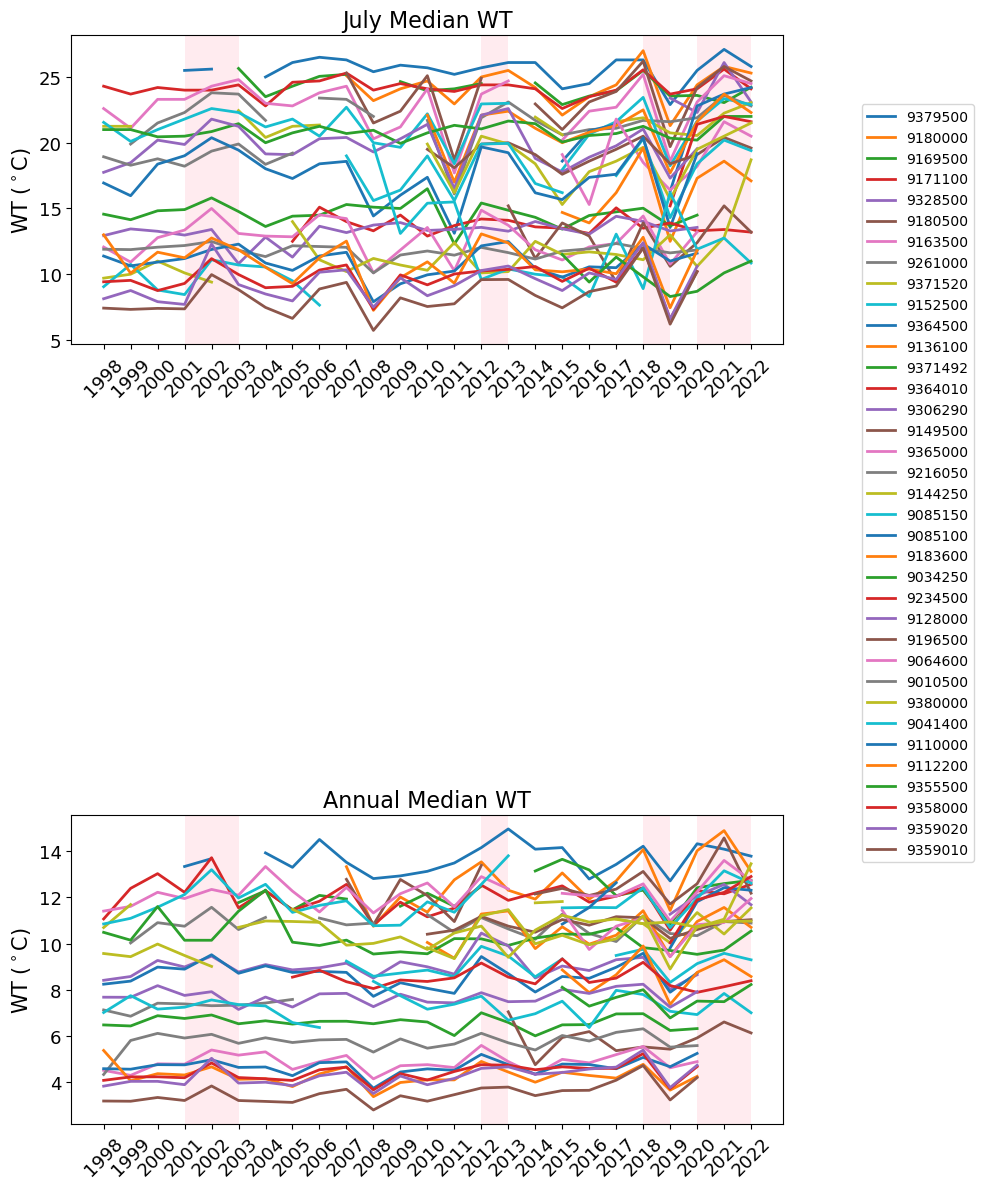

In [166]:
## NOT USED, ADDITIONAL
## PLOT: Long term ANNUAL Avg, VARS, with num of sites, MK results
figsize=(10,12)
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=figsize)#,sharex=True)
fontsize=14
#fig.suptitle(f"WT, n: {len(WT_years.columns)} ",fontsize=fontsize, y=1.01)
var = var_names[1]
ax[0].set_ylabel(r'WT ($^\circ$C)', fontsize=fontsize+1)
ax[0].set_title(f"July Median {var}", fontsize=fontsize+2)
ax[1].set_ylabel(r'WT ($^\circ$C)', fontsize=fontsize+1)
ax[1].set_title(f"Annual Median {var}", fontsize=fontsize+2)


years = sorted_WT_julies.index
for col in sorted_WT_julies.columns:
    ax[0].plot(years, sorted_WT_julies[col], label=col, linewidth=2)

ax[0].grid(False)
ax[0].set_xticks(years)
ax[0].set_xticklabels(years, rotation=45)

for col in sorted_WT_years.columns:
    ax[1].plot(years, sorted_WT_years[col], label=col, linewidth=2)

ax[1].grid(False)
ax[1].set_xticks(years)
ax[1].set_xticklabels(years, rotation=45)
# handles = []


rect2001 = mpl.patches.Rectangle((2001, 0), 2, 30, facecolor='pink', alpha=0.3)
rect2012 = mpl.patches.Rectangle((2012, 0), 1,30, facecolor='pink', alpha=0.3)
rect2018 = mpl.patches.Rectangle((2018, 0), 1,30, facecolor='pink', alpha=0.3)
rect2020 = mpl.patches.Rectangle((2020, 0), 2, 30, facecolor='pink', alpha=0.3)
    
    # Add the patch to the axes
ax[0].add_patch(rect2001)
ax[0].add_patch(rect2012)
ax[0].add_patch(rect2018)
ax[0].add_patch(rect2020)

rect2001 = mpl.patches.Rectangle((2001, 0), 2, 30, facecolor='pink', alpha=0.3)
rect2012 = mpl.patches.Rectangle((2012, 0), 1,30, facecolor='pink', alpha=0.3)
rect2018 = mpl.patches.Rectangle((2018, 0), 1,30, facecolor='pink', alpha=0.3)
rect2020 = mpl.patches.Rectangle((2020, 0), 2, 30, facecolor='pink', alpha=0.3)
ax[1].add_patch(rect2001)
ax[1].add_patch(rect2012)
ax[1].add_patch(rect2018)
ax[1].add_patch(rect2020)

for label in (ax[0].get_xticklabels() + ax[0].get_yticklabels()):
    label.set_fontsize(fontsize-1)

for label in (ax[1].get_xticklabels() + ax[1].get_yticklabels()):
    label.set_fontsize(fontsize-1)
    
ax[0].legend(bbox_to_anchor=(1.1, 0.8),prop={"size":10})

fig.tight_layout()
plt.savefig(fig_dir+'WT_July_allsites_timeseries.jpeg',dpi=300)
plt.savefig(fig_dir+'WT_July_allsites_timeseries.svg',format="svg", transparent=True,dpi=300)
plt.show()

#### Reservoirs

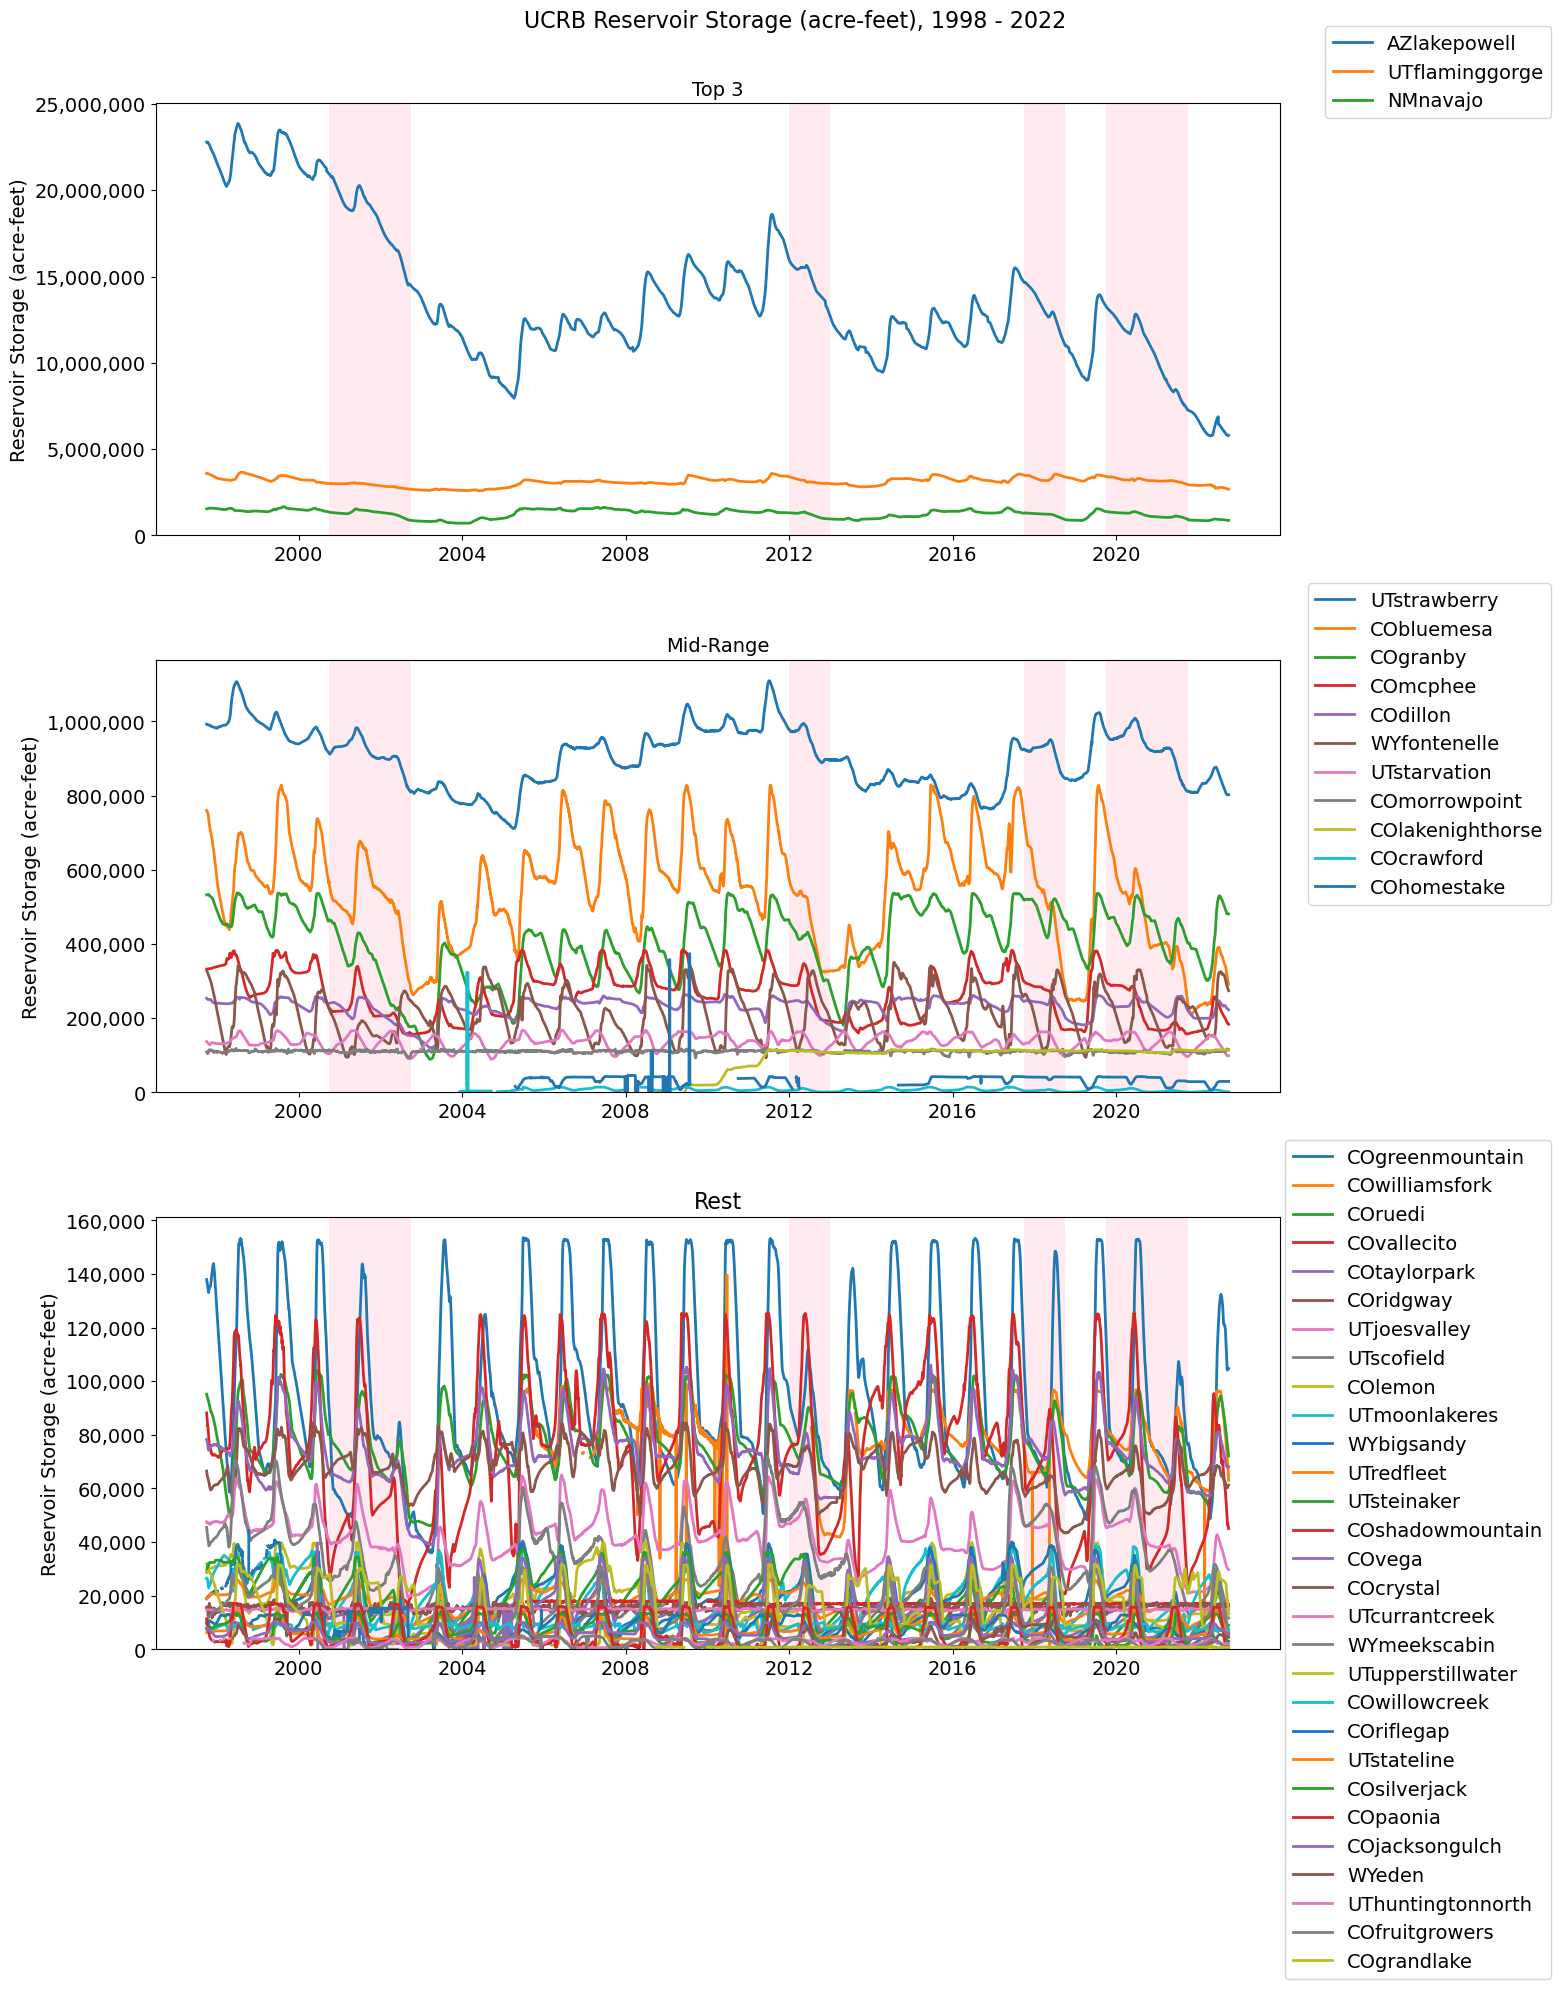

In [167]:
## PLOT: Reservoir storage with drought episodes
figsize=(16,20)
fig,axs = plt.subplots(nrows=3,ncols=1,figsize=figsize)#,sharex=True)

date_range = pd.date_range(start='1997-10-01', end='2022-09-30')

fontsize=14
fig.suptitle("UCRB Reservoir Storage (acre-feet), 1998 - 2022",fontsize=fontsize+2)
for val,ax in enumerate(axs):
    if val == 0:
        ax.set_title("Top 3", fontsize=fontsize)
        reservoirplotting = reservoirs_dateindexed_top3 #reservoirs_dateindexed_top3 = reservoirs_dateindexed[['AZlakepowell','UTflaminggorge', 'NMnavajo']]
    if val ==1:
        ax.set_title("Mid-Range", fontsize=fontsize)
        reservoirplotting = reservoirs_dateindexed_mid #reservoirs_dateindexed_mid = reservoirs_dateindexed_notop3[reservoirs_dateindexed_notop3.columns[reservoirs_dateindexed_notop3.mean().sort_values(ascending=False) > 100000].values]
    if val == 2:
        ax.set_title("Rest", fontsize=fontsize+2)
        reservoirplotting = reservoirs_dateindexed_rest
    
    ax.set_ylabel('Reservoir Storage (acre-feet)', fontsize=fontsize)

    handles = []

    for reservoir in reservoirplotting.columns:
        line1, = ax.plot(date_range,reservoirplotting[reservoir],label=reservoir, markersize=4, linewidth=2)
        handles.append(line1)

    max_height = reservoirplotting.max().max()+(reservoirplotting.max().max()*0.05)

    rect2000_2002 = mpl.patches.Rectangle((pd.Timestamp('2000-10-01'), 0), 
                                       pd.Timedelta(days=730),  # 2 years
                                       max_height, facecolor='pink', alpha=0.3)

    rect2011_2012 = mpl.patches.Rectangle((pd.Timestamp('2012'), 0), 
                                       pd.Timedelta(days=365),  # 1 year
                                       max_height, facecolor='pink', alpha=0.3)

    rect2017_2018 = mpl.patches.Rectangle((pd.Timestamp('2017-10-01'), 0), 
                                       pd.Timedelta(days=365),  # 1 year
                                       max_height, facecolor='pink', alpha=0.3)

    rect2019_2021 = mpl.patches.Rectangle((pd.Timestamp('2019-10-01'), 0), 
                                       pd.Timedelta(days=730),  # 2 years
                                       max_height, facecolor='pink', alpha=0.3)

    # Add rectangles to the ax
    ax.add_patch(rect2000_2002)
    ax.add_patch(rect2011_2012)
    ax.add_patch(rect2017_2018)
    ax.add_patch(rect2019_2021)

    #ax.set_ylim(vars()[var+'_annual_mean'].min()-(vars()[var+'_annual_mean'].min()*0.1), vars()[var+'_annual_mean'].max()+(vars()[var+'_annual_mean'].max()*0.05))
    ax.set_ylim(0, max_height)
    #ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Format the x-ticks to show only the year
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

    # Optional: Rotate x-tick labels for better readability
    ax.tick_params(axis='x', rotation=0)

    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(fontsize)

    ax.grid(False)
    ax.legend(bbox_to_anchor=(1.25, 1.20),handles=handles, prop={"size":fontsize})
    # if val == 1:
    #     fig.tight_layout()
    #     break
plt.tight_layout()
plt.savefig(fig_dir+'reservoirs_data_overtime.jpeg',dpi=300)
plt.savefig(fig_dir+'reservoirs_data_overtime.svg',format="svg", transparent=True,dpi=300)
plt.show()

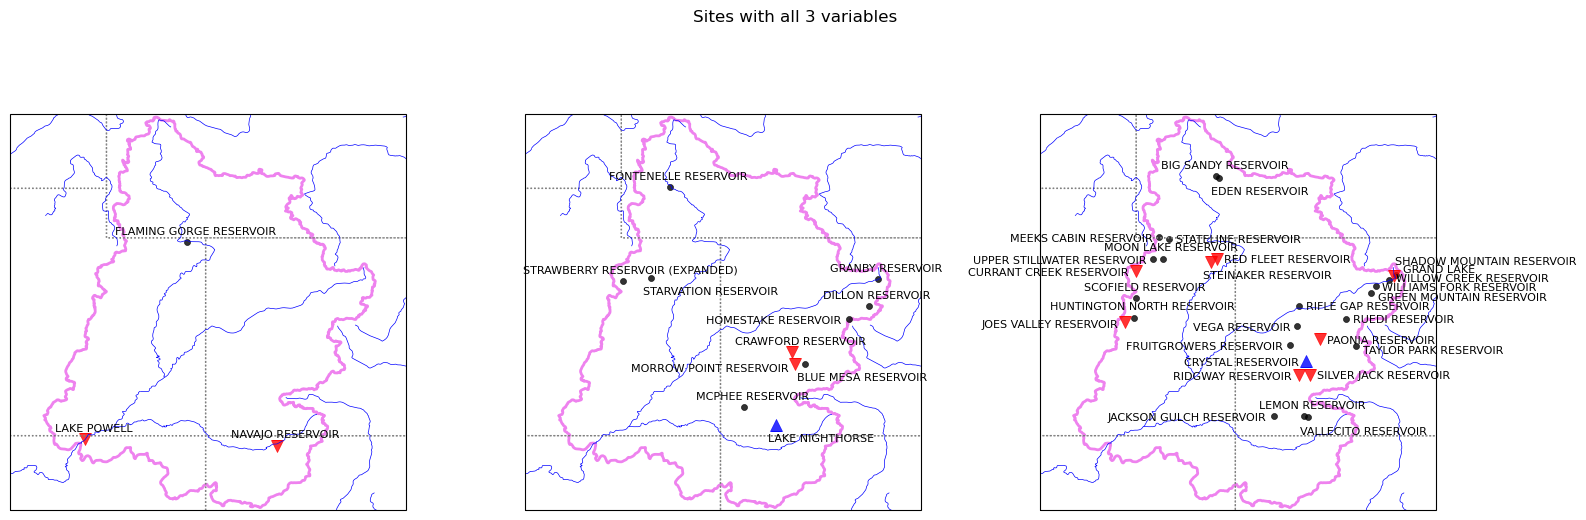

In [168]:
#plot_vars = dr_names
colorscheme ='bwr_r' #'PuOr'for WT and SC # 'bwr_r' for Q
#var_2plot = var_names[0]
#dr = dr_names[0]
fig, axes = plt.subplots(
    nrows=1, ncols=3,figsize=(16, 6),
    subplot_kw={ 'projection': crs.PlateCarree()
        #crs.AlbersEqualArea( central_latitude=39.5, central_longitude=-98.35)
        })

fig.suptitle("Sites with all 3 variables",fontsize=12)

# common shapefile for the basin boundary
fname = upper_colorado_river_boundary_dir / 'Upper_Colorado_River_Basin_Boundary.shp'
shape_feature = ShapelyFeature(
    shpreader(str(fname)).geometries(),
    crs.PlateCarree(),edgecolor='violet',facecolor='white',lw=2)

wholedata = resstor_MEDrelchange_map_all3
res_lists = ['top3', 'mid', 'rest']

#detailed_rivers = cfeature.RIVERS.with_scale('10m') 
detailed_rivers = cfeature.NaturalEarthFeature(
    category='physical', name='rivers_lake_centerlines',
    scale='10m', facecolor='none', edgecolor='blue')
#ax.add_feature(detailed_rivers)

adjust_names = ['STARVATION RESERVOIR','HOMESTAKE RESERVOIR','MORROW POINT RESERVOIR','BLUE MESA RESERVOIR',
                'EDEN RESERVOIR','JOES VALLEY RESERVOIR','MEEKS CABIN RESERVOIR','CURRANT CREEK RESERVOIR','JACKSON GULCH RESERVOIR',
                'STEINAKER RESERVOIR','LAKE NIGHTHORSE','VALLECITO RESERVOIR','RUEDI RESERVOIR','PAONIA RESERVOIR','VEGA RESERVOIR',
                'FRUITGROWERS RESERVOIR','CRYSTAL RESERVOIR','GREEN MOUNTAIN RESERVOIR','WILLIAMS FORK RESERVOIR',
                'RIFLE GAP RESERVOIR','TAYLOR PARK RESERVOIR','UPPER STILLWATER RESERVOIR','SHADOW MOUNTAIN RESERVOIR','GRAND LAKE',
                'STATELINE RESERVOIR','RED FLEET RESERVOIR','RIDGWAY RESERVOIR','SILVER JACK RESERVOIR','WILLOW CREEK RESERVOIR']  

to_left = ['HOMESTAKE RESERVOIR','MEEKS CABIN RESERVOIR','JOES VALLEY RESERVOIR','CURRANT CREEK RESERVOIR','JACKSON GULCH RESERVOIR',
           'UPPER STILLWATER RESERVOIR','VEGA RESERVOIR','FRUITGROWERS RESERVOIR','CRYSTAL RESERVOIR','RIDGWAY RESERVOIR']
        
to_right = ['RUEDI RESERVOIR','PAONIA RESERVOIR','WILLIAMS FORK RESERVOIR','RIFLE GAP RESERVOIR',
            'STATELINE RESERVOIR','RED FLEET RESERVOIR','SILVER JACK RESERVOIR']

to_right_down = ['GREEN MOUNTAIN RESERVOIR','TAYLOR PARK RESERVOIR']
to_right_up = ['SHADOW MOUNTAIN RESERVOIR']

for ax, var in zip(axes, res_lists):
    # add coastlines, states, rivers
    ax.add_feature(cfeature.COASTLINE, linestyle=':', edgecolor='grey', linewidth=1)
    ax.add_feature(cfeature.STATES,    linestyle=':', edgecolor='grey', linewidth=1)
    ax.add_feature(detailed_rivers,    edgecolor='blue', linewidth=0.5)
    ax.add_feature(shape_feature, zorder=-1)

    # zoom into the basin
    ax.set_extent([-113, -105, 35.5, 43.5], crs=crs.PlateCarree())

    # get the data
    #vars()['listsites_notrend'+var]       vars()['listsites_increasing'+var]       vars()['listsites_decreasing'+var]
    vmin, vmax = -100, 100
    for MK_type in ['notrend','increasing','decreasing']:
        data = wholedata.loc[vars()['listsites_'+MK_type+var]]
        if MK_type == 'notrend': 
            ax.scatter(x=data.LON, y=data.LAT, c='black',s= 75, alpha=0.8,
                    marker= '.', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)
        if MK_type == 'increasing': 
            ax.scatter(x=data.LON, y=data.LAT, c='blue',s= 75, alpha=0.8,
                    marker= '^', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)
        if MK_type == 'decreasing': 
            ax.scatter(x=data.LON, y=data.LAT, c='red',s= 75, alpha=0.8,
                    marker= 'v', #edgecolors= (1, 0, 0, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)   

        for lon, lat, name in zip(data['LON'], data['LAT'], data['name']):    
            if name not in adjust_names:
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(6, 6),  ha='center', fontsize=8, color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )
            if (name == 'STARVATION RESERVOIR') |(name == 'BLUE MESA RESERVOIR') | (name=='EDEN RESERVOIR')|(name=='STEINAKER RESERVOIR')|(name=='LAKE NIGHTHORSE')|(name=='VALLECITO RESERVOIR'):
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(-6, -12),  ha='left',fontsize=8,color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )   
            if name in to_left:
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(-5, -3),  ha='right',fontsize=8,color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )
            if name == 'MORROW POINT RESERVOIR':
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(-5, -5),  ha='right',fontsize=8,color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )
            if name in to_right:
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(5, -2.5),  ha='left',fontsize=8,color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )
            if name in to_right_down:
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(5, -5),  ha='left',fontsize=8,color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )
            if name in to_right_up:
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(1, 9),  ha='left',fontsize=8,color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )
            if name == 'GRAND LAKE':
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(5, 2.5),  ha='left',fontsize=8,color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )    
            if name == 'WILLOW CREEK RESERVOIR':
                ax.annotate( name, (lon, lat),
                    textcoords="offset points",  
                    xytext=(5, -1),  ha='left',fontsize=8,color='black' #,  # Ensure text color contrasts the background
                #bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='white')  # Optional background box
                )

plt.tight_layout()
plt.savefig(fig_dir+'reservoirlocations.jpeg',format='jpeg',dpi=300)
plt.savefig(fig_dir+'reservoirlocations.svg',format="svg", transparent=True,dpi=300)
plt.show()

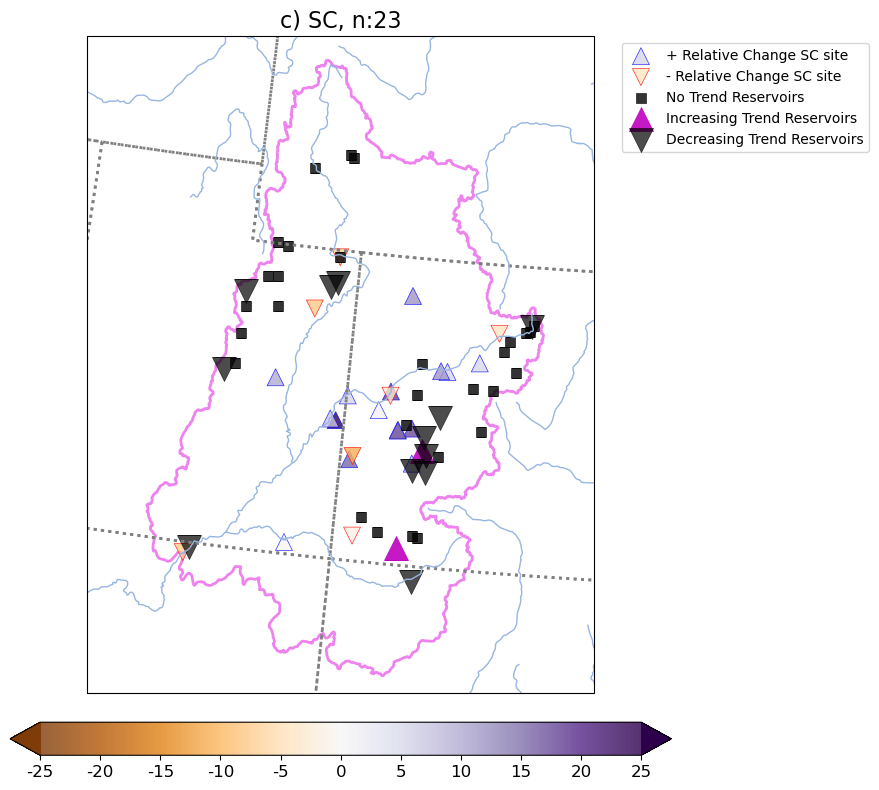

In [169]:
## MAP: Annual Rel.change, separated by VAR
# CHOOSE VARIABLE TO MAP - THIS ONE IS SET UP FOR WT AND SC
var = var_names[2]
figure = plt.figure(figsize=(10,8))
colorscheme ='PuOr' #'PuOr'for WT and SC # 'bwr_r' for Q

ax = figure.add_subplot(1,1,1, projection=crs.AlbersEqualArea(central_latitude=39.5,central_longitude=-98.35))
ax.add_feature(cfeature.COASTLINE, linestyle=':', edgecolor= 'grey', linewidth= 2)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor= 'grey', linewidth= 2)

# Zoom in on the US by setting longitude/latitude parameters
ax.set_extent([-113, -105, 35.5, 43.5],crs=crs.PlateCarree())
ax.add_feature(cfeature.RIVERS)

fname = upper_colorado_river_boundary_dir / 'Upper_Colorado_River_Basin_Boundary.shp'
shape_feature = ShapelyFeature(shpreader(fname).geometries(),crs.PlateCarree(), edgecolor='violet', facecolor='white',lw=2)
ax.add_feature(shape_feature,zorder=-1)        

data = vars()[var+'_MEDrelchange_map_all3']

vmax = 25
vmin = -25
d = data[(data['Relative Change (%)'] >= 0)] # & (data['CLASS']=='Non-Ref')

if var == var_names[1]:
    data_NOpubs = vars()[var_names[1]+'_MEDrelchange_map_all3'].drop(PUBS_sites_all3,errors='ignore')
    d = data_NOpubs[(data_NOpubs['Relative Change (%)'] >= 0)] #& (data_NOpubs['CLASS']=='Non-Ref')
plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 150, alpha=0.8,label='+ Relative Change '+var+' site',
                   marker= '^', edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

d = data[(data['Relative Change (%)'] < 0) ] # & (data['CLASS']=='Non-Ref')
plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 150,alpha=0.8,label='- Relative Change '+var+' site',
                   marker= 'v',edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

if var == var_names[1]:
    num_PUBS = len(set(PUBS_sites_all3).intersection(set(WT_years.columns)))
    valid_columns = vars()[var_names[1]+'_MEDrelchange_map_all3'].index.intersection(PUBS_sites_all3)
    data_pubs = vars()[var_names[1]+'_MEDrelchange_map_all3'].loc[valid_columns]
    d = data_pubs[(data_pubs['Relative Change (%)'] >= 0) ] # & (data_pubs['CLASS']=='Non-Ref')
    plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 150, alpha=0.8, label='PUBS site, n:'+str(num_PUBS),
                       marker= '^',edgecolors='lime',linewidth=1,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

    d = data_pubs[(data_pubs['Relative Change (%)'] < 0) ] # & (data_pubs['CLASS']=='Non-Ref')
    plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 150,alpha=0.8,
                       marker= 'v',edgecolors='lime', linewidth=1,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

# dref = data[(data['CLASS']=='Ref')]
# if len(dref) > 0:
#     plot = plt.scatter(x=dref.LON, y=dref.LAT, c='black',s= 100, alpha=0.8,
#                    marker= '.', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
#                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)


cbarplot = plt.scatter(x=data.LON, y=data.LAT, c=data['Relative Change (%)'],cmap = colorscheme,s= 0,alpha=0.8,
                       marker= '^',transform=crs.PlateCarree(),vmin = vmin, vmax = vmax)

vmin, vmax = -25, 25
ticks = np.arange(vmin, vmax + 5, 5)

cbar = plt.colorbar(
    cbarplot,
    fraction=0.046,
    pad=0.04,
    extend='both',
    orientation='horizontal',
    ticks=ticks
)
cbar.set_ticklabels([str(t) for t in ticks])
cbar.ax.tick_params(labelsize=12) 

if var == var_names[1]:
    ax.set_title('b) '+var+', n:'+str(len(data.index)),fontsize=16)    
if var == var_names[2]:
    ax.set_title('c) '+var+', n:'+str(len(data.index)),fontsize=16)  

wholedata = resstor_MEDrelchange_map_all3
for MK_type in ['notrend','increasing','decreasing']:
    #listsites_notrend, listsites_increasing, listsites_decreasing
    data = wholedata.loc[vars()['listsites_'+MK_type]]
    if MK_type == 'notrend': 
        ax.scatter(x=data.LON, y=data.LAT, c='black',s= 50, alpha=0.8, label = 'No Trend Reservoirs',
                    marker= 's', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)
    if MK_type == 'decreasing': 
        ax.scatter(x=data.LON, y=data.LAT, c='black',s= 300, alpha=0.7,label = 'Decreasing Trend Reservoirs',
                    marker= 'v', #edgecolors= (1, 0, 0, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)   
    if MK_type == 'increasing': 
        ax.scatter(x=data.LON, y=data.LAT, c='m',s= 300, alpha=0.9,label = 'Increasing Trend Reservoirs',
                    marker= '^', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

ax.legend(loc='upper left', bbox_to_anchor=(1.04, 1))
plt.tight_layout()
plt.savefig(fig_dir + var+'_locations_WRESERVOIRS.jpeg',format='jpeg',dpi=300)
plt.savefig(fig_dir + var+'_locations_WRESERVOIRS.svg',format="svg", transparent=True,dpi=300)
plt.show()

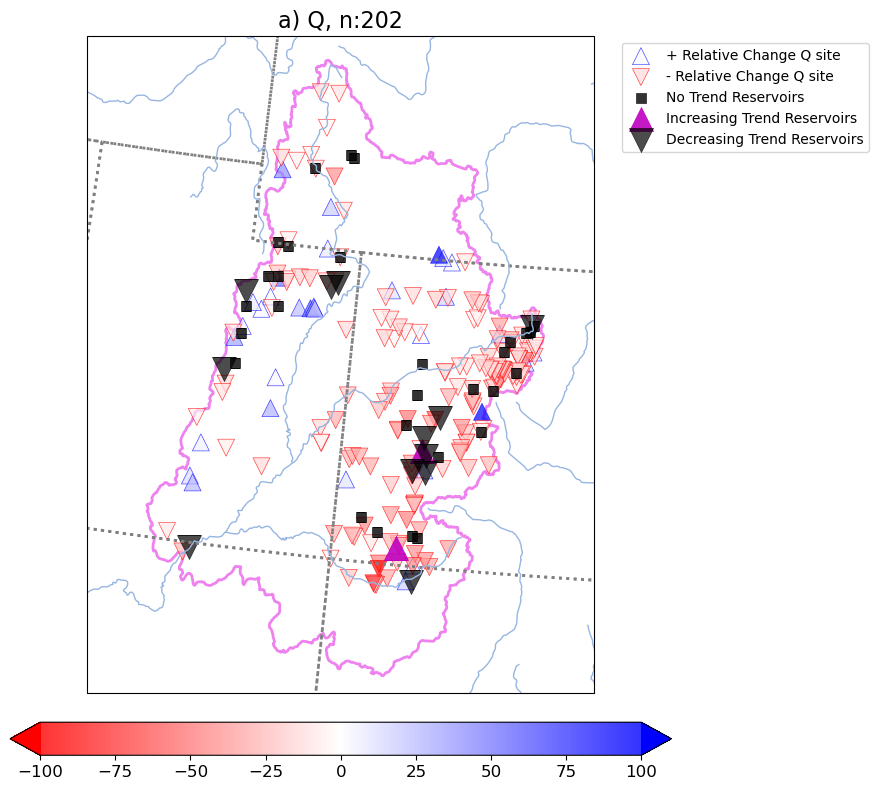

In [170]:
## MAP: Annual Rel.change, separated by VAR
# CHOOSE VARIABLE TO MAP - this one is set up for Q 
var = var_names[0]
figure = plt.figure(figsize=(10,8))
colorscheme ='bwr_r' #'PuOr'for WT and SC # 'bwr_r' for Q

ax = figure.add_subplot(1,1,1, projection=crs.AlbersEqualArea(central_latitude=39.5,central_longitude=-98.35))
ax.add_feature(cfeature.COASTLINE, linestyle=':', edgecolor= 'grey', linewidth= 2)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor= 'grey', linewidth= 2)

# Zoom in on the US by setting longitude/latitude parameters
ax.set_extent([-113, -105, 35.5, 43.5],crs=crs.PlateCarree())
ax.add_feature(cfeature.RIVERS)

fname = upper_colorado_river_boundary_dir / 'Upper_Colorado_River_Basin_Boundary.shp'
shape_feature = ShapelyFeature(shpreader(fname).geometries(),crs.PlateCarree(), edgecolor='violet', facecolor='white',lw=2)
ax.add_feature(shape_feature,zorder=-1)        

data = vars()[var+'_MEDrelchange_map_all3']
vmax = 100
vmin = -100

d = data[(data['Relative Change (%)'] >= 0) ] # & (data['CLASS']=='Non-Ref')]
plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme,s= 150, alpha=0.7, label='+ Relative Change Q site',
                   marker= '^', edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

d = data[(data['Relative Change (%)'] < 0) ] # & (data['CLASS']=='Non-Ref')
plot = plt.scatter(x=d.LON, y=d.LAT, c=d['Relative Change (%)'],cmap = colorscheme, s= 150,alpha=0.7,label='- Relative Change Q site',
                   marker= 'v',edgecolors=(1, 0, 0, 0.1), #(1, 0.5, 0, 0.1), #edgecolors=(1, 0, 0, 0.1), 
                   linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

# dref = data[(data['CLASS']=='Ref')]
# if len(dref) > 0:
#     plot = plt.scatter(x=dref.LON, y=dref.LAT, c='black',s= 100, alpha=0.8,
#                    marker= '.', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
#                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)


cbarplot = plt.scatter(x=data.LON, y=data.LAT, c=data['Relative Change (%)'],cmap = colorscheme,s= 0,alpha=0.8,
                       marker= '^',transform=crs.PlateCarree(),vmin = vmin, vmax = vmax)


cbar= plt.colorbar(cbarplot,fraction=0.046,pad=0.04, extend= 'both', orientation= 'horizontal')
cbar.ax.tick_params(labelsize=12)

var = 'Q'
ax.set_title('a) '+var+', n:'+str(len(data.index)),fontsize=16)   

wholedata = resstor_MEDrelchange_map_all3
for MK_type in ['notrend','increasing','decreasing']:
    #listsites_notrend, listsites_increasing, listsites_decreasing
    data = wholedata.loc[vars()['listsites_'+MK_type]]
    if MK_type == 'notrend': 
        ax.scatter(x=data.LON, y=data.LAT, c='black',s= 50, alpha=0.8, label = 'No Trend Reservoirs',
                    marker= 's', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)
    if MK_type == 'decreasing': 
        ax.scatter(x=data.LON, y=data.LAT, c='black',s= 300, alpha=0.7,label = 'Decreasing Trend Reservoirs',
                    marker= 'v', #edgecolors= (1, 0, 0, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)   
    if MK_type == 'increasing': 
        ax.scatter(x=data.LON, y=data.LAT, c='m',s= 300, alpha=0.9,label = 'Increasing Trend Reservoirs',
                    marker= '^', #edgecolors= (0, 0, 1, 0.1), #(0.5, 0, 0.5, 0.1), # edgecolors=(0.5, 0.5, 0.5, 1) edgecolors=(0, 0, 1, 0.1),
                    linewidth=0.5,transform=crs.PlateCarree(),vmin = vmin, vmax = vmax,zorder=1)

ax.legend(loc='upper left', bbox_to_anchor=(1.04, 1))
plt.tight_layout()
plt.savefig(fig_dir+var+'_locations_WRESERVOIRS.jpeg',format='jpeg',dpi=300)
plt.savefig(fig_dir + var+'_locations_WRESERVOIRS.svg',format="svg", transparent=True,dpi=300)
plt.show()